In [365]:
import numpy as np
from utilities import *

## Setup Hamiltonian

In [366]:
from functools import lru_cache
from scipy.sparse import coo_matrix, csr_matrix

def fixedN_basis(m: int, N: int):
    """List all m-tuples of nonnegative ints summing to N."""
    if m < 1: raise ValueError("m must be >= 1")
    if N < 0: raise ValueError("N must be >= 0")

    basis = []
    occ = [0]*m

    def rec(pos, remaining):
        if pos == m-1:
            occ[pos] = remaining
            basis.append(tuple(occ))
            return
        for n in range(remaining+1):
            occ[pos] = n
            rec(pos+1, remaining-n)

    rec(0, N)
    return basis

class FixedNBosons:
    """
    Fixed total photon number N across m modes.
    Basis: tuples (n1,...,nm) with sum=N.
    Operators: number-conserving hopping a_i^† a_j.
    """
    def __init__(self, m: int, N: int):
        self.m = m
        self.N = N
        self.basis = fixedN_basis(m, N)
        self.dim = len(self.basis)
        self.basis_to_index = {occ: i for i, occ in enumerate(self.basis)}

    def ket(self, occ):
        occ = tuple(occ)
        v = np.zeros(self.dim, dtype=complex)
        v[self.basis_to_index[occ]] = 1.0
        return v

    def pretty_ket(self, psi, tol=1e-12, max_terms=30):
        terms = [(i, amp, self.basis[i]) for i, amp in enumerate(psi) if abs(amp) > tol]
        terms.sort(key=lambda t: abs(t[1]), reverse=True)
        if not terms:
            return "0"
        lines = []
        for i, amp, occ in terms[:max_terms]:
            lines.append(f"{amp:+.6g} |{occ}>")
        if len(terms) > max_terms:
            lines.append(f"... ({len(terms)-max_terms} more terms)")
        return "\n".join(lines)

    def mean_occupations(self, psi):
        # <n_k> from probabilities in occupation basis
        p = np.abs(psi)**2
        nk = np.zeros(self.m, dtype=float)
        for idx, occ in enumerate(self.basis):
            nk += p[idx] * np.array(occ, dtype=float)
        return np.round(nk, 2)

    @lru_cache(maxsize=None)
    def hop(self, i: int, j: int) -> csr_matrix:
        """
        Return sparse matrix for a_i^† a_j (1-indexed modes).
        Acts within fixed-N subspace.
        """
        if not (1 <= i <= self.m and 1 <= j <= self.m):
            raise ValueError("mode indices must be in 1..m")
        if i == j:
            # This is number operator n_i
            rows, cols, data = [], [], []
            for col, occ in enumerate(self.basis):
                data.append(occ[i-1])
                rows.append(col)
                cols.append(col)
            return csr_matrix((data, (rows, cols)), shape=(self.dim, self.dim), dtype=complex)

        rows, cols, data = [], [], []
        for col, occ in enumerate(self.basis):
            nj = occ[j-1]
            if nj == 0:
                continue
            # new occupation: move one photon from j to i
            new_occ = list(occ)
            new_occ[j-1] -= 1
            new_occ[i-1] += 1
            new_occ = tuple(new_occ)
            row = self.basis_to_index[new_occ]

            amp = np.sqrt((occ[i-1] + 1) * occ[j-1])  # bosonic factor
            rows.append(row)
            cols.append(col)
            data.append(amp)

        return csr_matrix((data, (rows, cols)), shape=(self.dim, self.dim), dtype=complex)

In [367]:
hs = FixedNBosons(m=8, N=3)               # 3 photons over 8 modes
psi = hs.ket((3,0,0,0,0,0,0,0))           # all 3 photons in mode 1

print("Initial:")
print(hs.pretty_ket(psi))
print("<n_k> =", hs.mean_occupations(psi))

# Apply a_2^† a_1 : move one photon from mode 1 to mode 2
psi2 = hs.hop(2,1) @ psi
# Normalize if you want to interpret as a state after a non-unitary operator application
psi2 = psi2 / np.linalg.norm(psi2)
print("\nAfter hop (2 <- 1):")
print(hs.pretty_ket(psi2))
print("<n_k> =", hs.mean_occupations(psi2))


Initial:
+1+0j |(3, 0, 0, 0, 0, 0, 0, 0)>
<n_k> = [3. 0. 0. 0. 0. 0. 0. 0.]

After hop (2 <- 1):
+1+0j |(2, 1, 0, 0, 0, 0, 0, 0)>
<n_k> = [2. 1. 0. 0. 0. 0. 0. 0.]


## Second quantization ECM

In [368]:
from scipy.sparse.linalg import expm_multiply

def build_H_edges(hs, edges, eps=None):
    H = 0
    for i, j, Jij in edges:  # 1-indexed modes
        H = H + Jij * hs.hop(i, j) + np.conj(Jij) * hs.hop(j, i)
    if eps is not None:
        for i, ei in enumerate(eps, start=1):
            if ei != 0:
                H = H + ei * hs.hop(i, i)
    return H

def evolve(H, psi0, t):
    return expm_multiply((-1j * t) * H, psi0)

def layer_totals(nk):
    # modes 1-2 = L1, 3-4 = L2, 5-6 = L3
    return np.array([nk[0]+nk[1], nk[2]+nk[3], nk[4]+nk[5]])

def print_layers(label, hs, psi):
    nk = hs.mean_occupations(psi)  # unitary -> normalized
    print(f"{label:>10}  <L1,L2,L3> = {layer_totals(nk)}    <modes> = {nk}")

def K_from_edges(edges, src_modes, dst_modes):
    """
    Build the coupling matrix K (dst x src) from edges (src<->dst only).
    K[dst_index, src_index] = Jij for term a_dst^† a_src (with h.c. added in H builder).
    """
    src_to_col = {m: c for c, m in enumerate(src_modes)}
    dst_to_row = {m: r for r, m in enumerate(dst_modes)}
    K = np.zeros((len(dst_modes), len(src_modes)), dtype=complex)
    for i, j, Jij in edges:
        # interpret edge as undirected; decide orientation by membership
        if (i in src_to_col) and (j in dst_to_row):
            K[dst_to_row[j], src_to_col[i]] += Jij
        elif (j in src_to_col) and (i in dst_to_row):
            K[dst_to_row[i], src_to_col[j]] += Jij
    return K

def transfer_signal_from_svals(t, svals, weights=None):
    """
    Effective layer-transfer signal from the singular values of the
    source-to-target coupling matrix K.

    For simple layer hopping, each singular value behaves like an
    independent collective Rabi frequency.
    """
    svals = np.asarray(svals, dtype=float)
    active = svals > 1e-12
    svals = svals[active]

    if len(svals) == 0:
        return 0.0

    if weights is None:
        weights = np.ones_like(svals)
    else:
        weights = np.asarray(weights, dtype=float)[active]

    return float(np.sum(weights * np.sin(svals * t)**2))


def choose_time_from_K(
    K,
    method="rms",
    weights=None,
    t_max=None,
    n_periods=8,
    n_grid=4000,
    return_info=False,
):
    """
    Choose an interaction time from the singular values of K.

    Existing methods:
        method="max"  : use pi/(2*sigma_max)
        method="min"  : use pi/(2*sigma_min)
        method="rms"  : use pi/(2*sigma_rms)

    New optimization methods:
        method="opt_grid"
            Coarse grid search over t.

        method="opt_bounded"
            Direct scipy.optimize.minimize_scalar over [0, t_max].
            Fast, but can miss the global maximum if the signal has many peaks.

        method="opt_hybrid"
            Recommended. First coarse grid search, then locally refine the
            best grid point using scipy.optimize.minimize_scalar.

    Returns:
        t, svals

    If return_info=True, returns:
        t, svals, info
    """
    s = np.linalg.svd(K, compute_uv=False)
    s = np.sort(np.real_if_close(s))[::-1]
    s = np.asarray(s, dtype=float)

    active = s > 1e-12
    if not np.any(active):
        raise ValueError("All couplings are zero; cannot choose an interaction time.")

    s_active = s[active]
    s_max = s_active[0]
    s_min = s_active[-1]
    s_rms = np.sqrt(np.mean(s_active**2))

    info = {
        "method": method,
        "svals": s,
        "s_active": s_active,
        "s_max": s_max,
        "s_min": s_min,
        "s_rms": s_rms,
    }

    if method == "max":
        sigma = s_max
        t = np.pi / (2 * sigma)

    elif method == "min":
        sigma = s_min
        t = np.pi / (2 * sigma)

    elif method == "rms":
        sigma = s_rms
        t = np.pi / (2 * sigma)

    elif method in ["opt_grid", "opt_bounded", "opt_hybrid"]:
        from scipy.optimize import minimize_scalar

        if t_max is None:
            # Search up to several periods of the slowest active channel.
            # This is important when singular values are incommensurate,
            # e.g. sigma_+/sigma_- = sqrt(3).
            t_max = n_periods * np.pi / s_min

        def signal(t_local):
            return transfer_signal_from_svals(t_local, s_active, weights=weights)

        if method == "opt_grid":
            ts = np.linspace(0.0, t_max, n_grid)
            vals = np.array([signal(tt) for tt in ts])
            idx = int(np.argmax(vals))
            t = float(ts[idx])

            info.update({
                "t_max": t_max,
                "n_grid": n_grid,
                "signal_opt": float(vals[idx]),
                "grid_index": idx,
            })

        elif method == "opt_bounded":
            res = minimize_scalar(
                lambda tt: -signal(tt),
                bounds=(0.0, t_max),
                method="bounded",
            )
            t = float(res.x)

            info.update({
                "t_max": t_max,
                "signal_opt": float(-res.fun),
                "optimizer_success": bool(res.success),
                "optimizer_message": res.message,
            })

        elif method == "opt_hybrid":
            # First locate a good peak by grid search.
            ts = np.linspace(0.0, t_max, n_grid)
            vals = np.array([signal(tt) for tt in ts])
            idx = int(np.argmax(vals))

            # Then refine only around that peak.
            left = float(ts[max(idx - 1, 0)])
            right = float(ts[min(idx + 1, len(ts) - 1)])

            if right <= left:
                t = float(ts[idx])
                signal_opt = float(vals[idx])
                success = False
                message = "Grid maximum was at a boundary; no local refinement performed."
            else:
                res = minimize_scalar(
                    lambda tt: -signal(tt),
                    bounds=(left, right),
                    method="bounded",
                )
                t = float(res.x)
                signal_opt = float(-res.fun)
                success = bool(res.success)
                message = res.message

            info.update({
                "t_max": t_max,
                "n_grid": n_grid,
                "grid_best_t": float(ts[idx]),
                "grid_best_signal": float(vals[idx]),
                "refine_left": left,
                "refine_right": right,
                "signal_opt": signal_opt,
                "optimizer_success": success,
                "optimizer_message": message,
            })

    else:
        raise ValueError(
            "method must be one of: "
            "'max', 'min', 'rms', 'opt_grid', 'opt_bounded', 'opt_hybrid'"
        )

    info["t"] = float(t)
    info["signal_at_t"] = transfer_signal_from_svals(t, s_active, weights=weights)

    if return_info:
        return float(t), s, info

    return float(t), s

In [369]:
# ----------------------------
# Setup: 3 layers x 2 modes
# L1: (1,2), L2: (3,4), L3: (5,6)
# ----------------------------
m = 6
N = 2
hs = FixedNBosons(m=m, N=N)

# Initial: one photon per mode in layer 1 => |1,1,0,0,0,0>
psi0 = hs.ket((1,1,0,0,0,0))

# Different couplings between modes (interconnected, non-uniform)
edges12 = [(1,3, 1.0), (1,4, 0.3),
           (2,3, 0.2), (2,4, 0.9)]

edges23 = [(3,5, 0.7), (3,6, 0.2),
           (4,5, 0.4), (4,6, 1.1)]

H12 = build_H_edges(hs, edges12)
H23 = build_H_edges(hs, edges23)

# Choose non-greedy interaction times from coupling spectra
K12 = K_from_edges(edges12, src_modes=[1,2], dst_modes=[3,4])
K23 = K_from_edges(edges23, src_modes=[3,4], dst_modes=[5,6])

t1, s12 = choose_time_from_K(K12, method="opt_hybrid")  # try "max"/"min"/"rms"
t2, s23 = choose_time_from_K(K23, method="opt_hybrid")

print("Singular values K12:", s12, "=> t1 =", t1)
print("Singular values K23:", s23, "=> t2 =", t2)

# Evolve step-by-step
psi1 = evolve(H12, psi0, t1)
psi2 = evolve(H23, psi1, t2)

print_layers("initial", hs, psi0)
print_layers("after H12", hs, psi1)
print_layers("after H23", hs, psi2)

# Optional: see how populations change through "steps" by sampling around the chosen times
print("\nStep-1 sweep around t1 (just to observe, not to optimize):")
for frac in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]:
    psi_tmp = evolve(H12, psi0, frac*t1)
    print(f"t={frac*t1:7.3f}", layer_totals(hs.mean_occupations(psi_tmp)))

print("\nStep-2 sweep around t2 starting from psi1:")
for frac in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]:
    psi_tmp = evolve(H23, psi1, frac*t2)
    print(f"t={frac*t2:7.3f}", layer_totals(hs.mean_occupations(psi_tmp)))


Singular values K12: [1.20626586 0.6963639 ] => t1 = 24.759510382049847
Singular values K23: [1.26609364 0.54498339] => t2 = 8.678737872288542
   initial  <L1,L2,L3> = [2. 0. 0.]    <modes> = [1. 1. 0. 0. 0. 0.]
 after H12  <L1,L2,L3> = [0. 2. 0.]    <modes> = [0. 0. 1. 1. 0. 0.]
 after H23  <L1,L2,L3> = [0. 0. 2.]    <modes> = [0. 0. 0. 0. 1. 1.]

Step-1 sweep around t1 (just to observe, not to optimize):
t=  0.000 [2. 0. 0.]
t=  6.190 [0.3 1.7 0. ]
t= 12.380 [0.99 1.01 0.  ]
t= 18.570 [1.71 0.28 0.  ]
t= 24.760 [0. 2. 0.]
t= 30.949 [1.69 0.31 0.  ]

Step-2 sweep around t2 starting from psi1:
t=  0.000 [0. 2. 0.]
t=  2.170 [0. 1. 1.]
t=  4.339 [0.   1.01 0.99]
t=  6.509 [0.   0.99 1.02]
t=  8.679 [0. 0. 2.]
t= 10.848 [0.   1.02 0.97]


## Add ancilla atom detectors

In [370]:
from scipy.sparse import kron, identity, csr_matrix
from scipy.sparse.linalg import expm_multiply

In [371]:
def separate_subsystems(psi_full, dim_boson, dim_ancilla):
    """
    Given a joint state vector psi_full of dimension dim_boson*dim_ancilla,
    return the reduced density matrices for the bosonic and ancilla subsystems.
    If the state is a product state, also return the corresponding pure state
    vectors up to a global phase.

    Parameters
    ----------
    psi_full : 1D numpy array, shape (dim_boson*dim_ancilla,)
        The full state vector of the composite system.
    dim_boson : int
        Dimension of the bosonic subsystem.
    dim_ancilla : int
        Dimension of the ancilla subsystem (2 in your case).

    Returns
    -------
    rho_b : 2D numpy array, shape (dim_boson, dim_boson)
        Reduced density matrix of the bosonic subsystem.
    rho_a : 2D numpy array, shape (dim_ancilla, dim_ancilla)
        Reduced density matrix of the ancilla subsystem.
    psi_b : 1D numpy array or None
        Pure state vector of the bosonic subsystem if separable, else None.
    psi_a : 1D numpy array or None
        Pure state vector of the ancilla subsystem if separable, else None.
    """
    # reshape into matrix form (rows index boson states, columns index ancilla)
    psi_mat = psi_full.reshape(dim_boson, dim_ancilla)

    # reduced density matrices by partial trace
    rho_b = np.einsum('ik,jk->ij', psi_mat, psi_mat.conj())
    rho_a = np.einsum('ki,kj->ij', psi_mat, psi_mat.conj())

    # attempt to extract pure states if rank-1
    psi_b = None
    psi_a = None
    # eigen-decomposition of rho_b
    vals_b, vecs_b = np.linalg.eigh(rho_b)
    # find the eigenvector with the largest eigenvalue
    if np.isclose(vals_b[-1], 1.0, atol=1e-10):
        psi_b = vecs_b[:, -1]
        # similar for ancilla
        vals_a, vecs_a = np.linalg.eigh(rho_a)
        psi_a = vecs_a[:, -1]
        # fix global phase: make the inner product with psi_mat positive real
        phase = (psi_mat @ psi_a).conj().dot(psi_b)
        psi_b *= np.exp(-1j * np.angle(phase))
    return rho_b, rho_a, psi_b, psi_a

In [372]:
# ancilla Pauli matrices (dense, 2×2)
sigma_z = csr_matrix(np.array([[1, 0], [0, -1]], dtype=complex))
sigma_x = csr_matrix(np.array([[0, 1], [1, 0]], dtype=complex))
sigma_y = csr_matrix(np.array([[0, -1j], [1j, 0]], dtype=complex))
identity_qubit = csr_matrix(np.eye(2, dtype=complex))

In [373]:
hs = FixedNBosons(m=2, N=2)
H_boson = hs.hop(2, 1) + hs.hop(1, 2)  # simple hopping between two modes
psi_boson = hs.ket((2, 0))  # one photon in mode 1

In [374]:
# identities on bosonic space
identity_boson = identity(hs.dim, format='csr', dtype=complex)

In [375]:
# choose which mode to monitor (e.g., k=1) and its number operator
k = 1
n_k = hs.hop(k, k)  # this is a sparse operator acting on the bosonic Hilbert space

In [376]:
# dispersive parameters
chi = 0.05  # dispersive shift per photon (arbitrary units)
omega_q = 0.0  # qubit frequency; set to zero if you only care about the phase

In [377]:
# Build the full Hamiltonian on the tensor product space
H_boson_full = kron(H_boson, identity_qubit)
H_qubit_full = 0.5 * omega_q * kron(identity_boson, sigma_z)
H_disp = chi * kron(n_k, sigma_z)

In [378]:
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

In [379]:
t_hop = np.pi / (2 * 1.0)  # time to swap between modes 1 and 2
psi_full = np.kron(psi_boson, psi_anc_plus)  # initial state of boson + ancilla
psi_full_after_hop = expm_multiply((-1j * t_hop) * H_boson_full, psi_full)

In [380]:
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop, hs.dim, 2)

In [381]:
hs.mean_occupations(psi_b)

array([0., 2.])

In [382]:
def expectation_full_state(psi, O):
    """
    Expectation value <psi| O |psi>
    """
    return np.vdot(psi, O @ psi)

In [383]:
I_b = identity(hs.dim, format='csr', dtype=complex)

X_full = kron(I_b, sigma_x)
Y_full = kron(I_b, sigma_y)
Z_full = kron(I_b, sigma_z)

In [384]:
# apply int
N = 1  # max photon number 
t_int = 0.1 / (chi * N) 
psi_after_int = expm_multiply((-1j * t_int) * H_disp, psi_full_after_hop)

In [385]:
expectation_full_state(psi_after_int, Y_full)

np.complex128(1.8746159464641204e-31-1.1377097173659526e-48j)

In [386]:
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_after_int, hs.dim, 2)
hs.mean_occupations(psi_b)

array([0., 2.])

### compressed code for testing

In [387]:
# one layer bosonic ECM
m = 2
N = 3
hs = FixedNBosons(m=m, N=N)
H_boson = hs.hop(2, 1) + hs.hop(1, 2) 
identity_boson = identity(hs.dim, format='csr', dtype=complex) 
psi_boson = hs.ket((2, 1))  

# ancilla
k = 2 # monitor mode 2
n_k = hs.hop(k, k)
chi = 0.05
omega_q = 0.0
H_ancilla = 0.5 * omega_q * sigma_z 
identity_qubit = identity(2, format='csr', dtype=complex)
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

# total hamiltonians
H_int = chi * kron(n_k, sigma_z)
H_ecm = kron(H_boson, identity_qubit) + kron(identity_boson, H_ancilla)
psi_full = np.kron(psi_boson, psi_anc_plus)  # initial state of boson + ancilla

In [388]:
t_hop = np.pi / (2 * 1.0)  # time to swap between modes 1 and 2
psi_full = np.kron(psi_boson, psi_anc_plus)  # initial state of boson + ancilla
psi_full_after_hop = expm_multiply((-1j * t_hop) * H_ecm, psi_full)

# state before
print("Initial state, occupations numbers:", hs.mean_occupations(psi_boson))
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop, hs.dim, 2)
print("After hop, occupations numbers:", hs.mean_occupations(psi_b))

Initial state, occupations numbers: [2. 1.]
After hop, occupations numbers: [1. 2.]


In [389]:
t_int = 0.1 / (chi * 2)
psi_after_int = expm_multiply((-1j * t_int) * H_int, psi_full_after_hop)

In [390]:
Y_full = kron(identity_boson, sigma_y)

In [391]:
print("ancilla expectation <Y> after int:", np.real(np.round(expectation_full_state(psi_after_int, Y_full), 2) ))

ancilla expectation <Y> after int: 0.2


In [392]:
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_after_int, hs.dim, 2)
print("After int, occupations numbers:", hs.mean_occupations(psi_b))

After int, occupations numbers: [1. 2.]


## Multilayer with a few ancillas

In [393]:
# ----------------------------
# Setup: 3 layers x 2 modes
# L1: (1,2), L2: (3,4), L3: (5,6)
# ----------------------------
m = 6
N = 2
hs = FixedNBosons(m=m, N=N)

# Initial: one photon per mode in layer 1 => |1,1,0,0,0,0>
psi0 = hs.ket((1,1,0,0,0,0))

# Different couplings between modes (interconnected, non-uniform)
edges12 = [(1,3, 1.0), (1,4, 0.3),
           (2,3, 0.2), (2,4, 0.9)]

edges23 = [(3,5, 0.7), (3,6, 0.2),
           (4,5, 0.4), (4,6, 1.1)]

H12 = build_H_edges(hs, edges12)
H23 = build_H_edges(hs, edges23)

# Choose non-greedy interaction times from coupling spectra
K12 = K_from_edges(edges12, src_modes=[1,2], dst_modes=[3,4])
K23 = K_from_edges(edges23, src_modes=[3,4], dst_modes=[5,6])

t1, s12 = choose_time_from_K(K12, method="opt_hybrid")  # try "max"/"min"/"rms"
t2, s23 = choose_time_from_K(K23, method="opt_hybrid")

In [394]:
# dispersive parameters
chi = 0.05  # dispersive shift per photon (arbitrary units)
omega_q = 0.0  # qubit frequency; set to zero if you only care about the phase

In [395]:
# build ancillas
layers = [2]
modes_per_layer = {2: (3,4)}
H_ancilla = 0.5 * omega_q * sigma_z 
H_hop = {1:H12, 2:H23}
H_L_disp = {}
H_L_hop = {}
for l in layers:
    H_disp = csr_matrix(np.zeros((hs.dim*2**len(modes_per_layer[l]), (hs.dim*2**len(modes_per_layer[l]))), dtype=complex))  # placeholder for full Hamiltonian
    for i, k in enumerate(modes_per_layer[l]):
        # place sigma_z on the correct ancilla qubit
        if i == 0:
                sigma_z_full = sigma_z
        else:
            for j in range(i):
                if j == 0:
                    sigma_z_full = identity_qubit
                else:
                    sigma_z_full = kron(identity_qubit, sigma_z_full)
            sigma_z_full = kron(sigma_z, sigma_z_full)  # pad with identities for remaining ancillas
        for j in range(i+1, len(modes_per_layer[l])):
            sigma_z_full = kron(identity_qubit, sigma_z_full)
        n_k = hs.hop(k, k)
        H_disp += chi * kron(n_k, sigma_z_full) 
    H_L_disp[l] = H_disp
    H_ancillas = np.eye(2**len(modes_per_layer[l]), dtype=complex)
    H_L_hop[1] = kron(H_hop[1], H_ancillas)

In [396]:
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

In [397]:
psi_full = np.kron(psi0, np.kron(psi_anc_plus, psi_anc_plus))  # initial state of boson + ancillas
psi_full_after_hop1 = expm_multiply((-1j * t1) * H_L_hop[1], psi_full)

# state before
print("Initial state, occupations numbers:", hs.mean_occupations(psi0))
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop1, hs.dim, 2**len(modes_per_layer[2]))
print("After hop1, occupations numbers:", hs.mean_occupations(psi_b))

Initial state, occupations numbers: [1. 1. 0. 0. 0. 0.]
After hop1, occupations numbers: [0. 0. 1. 1. 0. 0.]


In [398]:
t_int = 0.1 / (chi * 2)
psi_after_int = expm_multiply((-1j * t_int) * H_L_disp[2], psi_full_after_hop1)

In [399]:
identity_boson = identity(hs.dim, format='csr', dtype=complex) 
Y_ancilla_1 = kron(identity_boson, kron(sigma_y, identity_qubit))  # Y on ancilla of layer 1
Y_ancilla_2 = kron(identity_boson, kron(identity_qubit, sigma_y))  # Y on ancilla of layer 2
print("ancilla 1 expectation <Y> after int:", np.real(np.round(expectation_full_state(psi_after_int, Y_ancilla_1), 2) ))
print("ancilla 2 expectation <Y> after int:", np.real(np.round(expectation_full_state(psi_after_int, Y_ancilla_2), 2) ))

ancilla 1 expectation <Y> after int: 0.1
ancilla 2 expectation <Y> after int: 0.1


In [400]:
hs.basis

[(0, 0, 0, 0, 0, 2),
 (0, 0, 0, 0, 1, 1),
 (0, 0, 0, 0, 2, 0),
 (0, 0, 0, 1, 0, 1),
 (0, 0, 0, 1, 1, 0),
 (0, 0, 0, 2, 0, 0),
 (0, 0, 1, 0, 0, 1),
 (0, 0, 1, 0, 1, 0),
 (0, 0, 1, 1, 0, 0),
 (0, 0, 2, 0, 0, 0),
 (0, 1, 0, 0, 0, 1),
 (0, 1, 0, 0, 1, 0),
 (0, 1, 0, 1, 0, 0),
 (0, 1, 1, 0, 0, 0),
 (0, 2, 0, 0, 0, 0),
 (1, 0, 0, 0, 0, 1),
 (1, 0, 0, 0, 1, 0),
 (1, 0, 0, 1, 0, 0),
 (1, 0, 1, 0, 0, 0),
 (1, 1, 0, 0, 0, 0),
 (2, 0, 0, 0, 0, 0)]

## try inequalities

In [401]:
# ----------------------------
# Setup: 3 layers x 2 modes
# L1: (1,2), L2: (3,4), L3: (5,6)
# ----------------------------
m = 6
N = 2
hs = FixedNBosons(m=m, N=N)

# Initial: one photon per mode in layer 1 => |1,1,0,0,0,0>
psi0 = hs.ket((1,1,0,0,0,0))

# Different couplings between modes (interconnected, non-uniform)
edges12 = [(1,3, 1.0), (1,4, 0.3),
           (2,3, 0.2), (2,4, 0.9)]

edges23 = [(3,5, 0.7), (3,6, 0.2),
           (4,5, 0.4), (4,6, 1.1)]

H12 = build_H_edges(hs, edges12)
H23 = build_H_edges(hs, edges23)

# Choose non-greedy interaction times from coupling spectra
K12 = K_from_edges(edges12, src_modes=[1,2], dst_modes=[3,4])
K23 = K_from_edges(edges23, src_modes=[3,4], dst_modes=[5,6])

t1, s12 = choose_time_from_K(K12, method="rms")  # try "max"/"min"/"rms"
t2, s23 = choose_time_from_K(K23, method="rms")

In [402]:
# dispersive parameters
chi = 0.05  # dispersive shift per photon (arbitrary units)
omega_q = 0.0  # qubit frequency; set to zero if you only care about the phase

In [403]:
# build ancillas
layers = [2]
modes_per_layer = {2: (3,4)}
H_ancilla = 0.5 * omega_q * sigma_z 
H_hop = {1:H12, 2:H23}
H_L_disp = {}
H_L_hop = {}
for l in layers:
    H_disp = csr_matrix(np.zeros((hs.dim*2**len(modes_per_layer[l]), (hs.dim*2**len(modes_per_layer[l]))), dtype=complex))  # placeholder for full Hamiltonian
    for i, k in enumerate(modes_per_layer[l]):
        # place sigma_z on the correct ancilla qubit
        if i == 0:
                sigma_z_full = sigma_z
        else:
            for j in range(i):
                if j == 0:
                    sigma_z_full = identity_qubit
                else:
                    sigma_z_full = kron(identity_qubit, sigma_z_full)
            sigma_z_full = kron(sigma_z, sigma_z_full)  # pad with identities for remaining ancillas
        for j in range(i+1, len(modes_per_layer[l])):
            sigma_z_full = kron(identity_qubit, sigma_z_full)
        n_k = hs.hop(k, k)
        H_disp += chi * kron(n_k, sigma_z_full) 
    H_L_disp[l] = H_disp
    H_ancillas = np.eye(2**len(modes_per_layer[l]), dtype=complex)
    H_L_hop[1] = kron(H_hop[1], H_ancillas)

In [404]:
psi_anc_plus  = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)

In [405]:
psi_full = np.kron(psi0, np.kron(psi_anc_plus, psi_anc_plus))  # initial state of boson + ancillas
psi_full_after_hop1 = expm_multiply((-1j * t1) * H_L_hop[1], psi_full)

# state before
print("Initial state, occupations numbers:", hs.mean_occupations(psi0))
rho_b, rho_a, psi_b, psi_a = separate_subsystems(psi_full_after_hop1, hs.dim, 2**len(modes_per_layer[2]))
print("After hop1, occupations numbers:", hs.mean_occupations(psi_b))

Initial state, occupations numbers: [1. 1. 0. 0. 0. 0.]
After hop1, occupations numbers: [0.15 0.17 0.85 0.84 0.   0.  ]


In [406]:
t_int = 0.1 / (chi * 2)
psi_after_int = expm_multiply((-1j * t_int) * H_L_disp[2], psi_full_after_hop1)

In [407]:
# ============================================================
# Stable fidelity utilities
# ============================================================

def psd_sqrt(rho, tol=1e-12):
    """
    Positive-semidefinite square root, stable for singular density matrices.
    """
    rho = np.asarray(rho, dtype=complex)
    rho = 0.5 * (rho + rho.conj().T)

    vals, vecs = np.linalg.eigh(rho)
    vals = np.clip(vals.real, 0.0, None)

    return vecs @ np.diag(np.sqrt(vals)) @ vecs.conj().T


def fidelity_dm(rho, sigma, tol=1e-12):
    """
    Uhlmann fidelity F(rho, sigma), not squared.
    """
    rho = np.asarray(rho, dtype=complex)
    sigma = np.asarray(sigma, dtype=complex)

    rho = 0.5 * (rho + rho.conj().T)
    sigma = 0.5 * (sigma + sigma.conj().T)

    sqrt_rho = psd_sqrt(rho, tol=tol)
    inner = sqrt_rho @ sigma @ sqrt_rho
    sqrt_inner = psd_sqrt(inner, tol=tol)

    F = np.real(np.trace(sqrt_inner))
    return float(np.clip(F, 0.0, 1.0))


# ============================================================
# Configuration helpers
# ============================================================

def local_config(occ, layer_modes):
    """
    Extract occupations on selected 1-indexed layer modes.

    Example:
        occ = (1,0,0,1,0,0), layer_modes=(3,4) -> (0,1)
    """
    return tuple(occ[m - 1] for m in layer_modes)


def env_config(occ, layer_modes):
    """
    Extract occupations on all modes except selected 1-indexed layer modes.
    """
    layer_set = {m - 1 for m in layer_modes}
    return tuple(n for i, n in enumerate(occ) if i not in layer_set)


def joint_matrix_from_state(psi_full, hs, dim_ancilla):
    """
    Convert |Psi> in H_photons ⊗ H_ancillas into a matrix

        Psi[photonic_basis_index, ancilla_basis_index].

    This matches your notebook construction:
        psi_full = np.kron(psi_photonic, psi_ancilla)
    """
    psi_full = np.asarray(psi_full, dtype=complex).reshape(-1)
    return psi_full.reshape(hs.dim, dim_ancilla)


# ============================================================
# Reduced photonic state on selected layer modes
# ============================================================

def reduced_layer_state_from_joint_pure(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes=(3, 4),
):
    """
    Given psi_full in H_photons ⊗ H_ancillas, compute rho_L for the selected
    layer modes by tracing out all other photonic modes and all ancillas.

    If layer_modes=(1,2,3,4,5,6), this returns the full photonic state
    rho_phot = Tr_A |Psi><Psi|.
    """
    Psi = joint_matrix_from_state(psi_full, hs, dim_ancilla)

    configs = sorted({local_config(occ, layer_modes) for occ in hs.basis})
    cfg_to_idx = {cfg: i for i, cfg in enumerate(configs)}

    # Trace out ancillas to get full photonic density matrix.
    rho_phot = Psi @ Psi.conj().T

    labels = [
        (local_config(occ, layer_modes), env_config(occ, layer_modes))
        for occ in hs.basis
    ]

    rho_layer = np.zeros((len(configs), len(configs)), dtype=complex)

    # Trace out all photonic modes outside layer_modes.
    for a, (mu_a, env_a) in enumerate(labels):
        i = cfg_to_idx[mu_a]
        for b, (mu_b, env_b) in enumerate(labels):
            if env_a == env_b:
                j = cfg_to_idx[mu_b]
                rho_layer[i, j] += rho_phot[a, b]

    # Numerical cleanup and normalization.
    rho_layer = 0.5 * (rho_layer + rho_layer.conj().T)
    tr = np.trace(rho_layer)
    if abs(tr) <= 1e-14:
        raise ValueError("Reduced layer state has near-zero trace.")
    rho_layer = rho_layer / tr

    probs = {
        cfg: float(np.real(rho_layer[cfg_to_idx[cfg], cfg_to_idx[cfg]]))
        for cfg in configs
    }

    return rho_layer, configs, probs


# ============================================================
# Active-support coherence
# ============================================================

def normalized_l1_coherence_active(
    rho_layer,
    configs,
    probs,
    p_tol=1e-14,
):
    """
    Active-support normalized l1 coherence:

        C = 1/(R_active - 1) sum_{mu != nu in active} |rho_mu,nu|.

    This must be used together with D_A, because D_A also restricts to
    active configurations.
    """
    active = [
        mu for mu in configs
        if probs.get(mu, 0.0) > p_tol
    ]

    R = len(active)
    if R <= 1:
        return 0.0, active

    idx = {cfg: i for i, cfg in enumerate(configs)}

    total = 0.0
    for mu in active:
        i = idx[mu]
        for nu in active:
            if mu == nu:
                continue
            j = idx[nu]
            total += abs(rho_layer[i, j])

    C = total / (R - 1)
    return float(C), active


# ============================================================
# Ancilla states conditioned on selected photonic configurations
# ============================================================

def conditioned_ancilla_states_from_layer_configs(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes=(3, 4),
    p_tol=1e-14,
):
    """
    For each selected local configuration mu, compute

        rho_A^mu =
            Tr_phot[(Pi_mu ⊗ I_A)|Psi><Psi|(Pi_mu ⊗ I_A)] / p_mu.

    Assumes psi_full is ordered as H_photons ⊗ H_ancillas.
    """
    Psi = joint_matrix_from_state(psi_full, hs, dim_ancilla)

    configs = sorted({local_config(occ, layer_modes) for occ in hs.basis})
    ancilla_states = {}
    probs = {}

    for mu in configs:
        rows = [
            idx for idx, occ in enumerate(hs.basis)
            if local_config(occ, layer_modes) == mu
        ]

        # Project onto local configuration mu, then trace out photons.
        block = Psi[rows, :]
        rho_A_unnorm = block.conj().T @ block

        p_mu = float(np.real(np.trace(rho_A_unnorm)))
        probs[mu] = p_mu

        if p_mu > p_tol:
            ancilla_states[mu] = rho_A_unnorm / p_mu

    return ancilla_states, probs, configs


# ============================================================
# Ancilla information term
# ============================================================

def ancilla_information_term_from_fidelities(
    ancilla_states,
    probs,
    configs,
    p_tol=1e-14,
):
    """
    Detector/ancilla information term:

        D_A =
            1 - 1/(R_active - 1)
                sum_{mu != nu in active}
                sqrt(p_mu p_nu) F(rho_A^mu, rho_A^nu).

    The corresponding bound is:

        C + D_A <= 1,

    provided C is computed over the same active configuration set.
    """
    active = [
        mu for mu in configs
        if probs.get(mu, 0.0) > p_tol and mu in ancilla_states
    ]

    R = len(active)
    if R <= 1:
        return {
            "D_A": 0.0,
            "overlap_term": 0.0,
            "active_configs": active,
            "pairwise_fidelities": {},
            "message": "Only one active configuration."
        }

    weighted_overlap_sum = 0.0
    pairwise_fidelities = {}

    for mu in active:
        for nu in active:
            if mu == nu:
                continue

            F = fidelity_dm(ancilla_states[mu], ancilla_states[nu])
            pairwise_fidelities[(mu, nu)] = F
            weighted_overlap_sum += np.sqrt(probs[mu] * probs[nu]) * F

    overlap_term = weighted_overlap_sum / (R - 1)
    D_A = 1.0 - overlap_term

    return {
        "D_A": float(np.clip(D_A, 0.0, 1.0)),
        "overlap_term": float(overlap_term),
        "active_configs": active,
        "pairwise_fidelities": pairwise_fidelities,
    }


# ============================================================
# Main diagnostic
# ============================================================

def wp_layer_diagnostic(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes=(3, 4),
    p_tol=1e-14,
):
    """
    Compute the layer/full-space coherence-path-information diagnostic:

        C + D_A <= 1.

    layer_modes:
        (3,4)               -> local middle-layer diagnostic.
        (1,2,3,4,5,6)       -> full photonic-space diagnostic.
    """
    rho_layer, configs, probs = reduced_layer_state_from_joint_pure(
        psi_full=psi_full,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=layer_modes,
    )

    ancilla_states, probs_A, configs_A = conditioned_ancilla_states_from_layer_configs(
        psi_full=psi_full,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=layer_modes,
        p_tol=p_tol,
    )

    # Sanity check: probabilities from rho_layer and from conditioning should match.
    max_prob_diff = max(
        abs(probs.get(cfg, 0.0) - probs_A.get(cfg, 0.0))
        for cfg in configs
    )

    C, active_configs = normalized_l1_coherence_active(
        rho_layer=rho_layer,
        configs=configs,
        probs=probs,
        p_tol=p_tol,
    )

    D_info = ancilla_information_term_from_fidelities(
        ancilla_states=ancilla_states,
        probs=probs_A,
        configs=configs_A,
        p_tol=p_tol,
    )

    D_A = D_info["D_A"]
    C_plus_D = C + D_A

    return {
        "layer_modes": layer_modes,
        "rho_layer": rho_layer,
        "configs": configs,
        "probabilities": probs,
        "conditioned_ancilla_states": ancilla_states,
        "active_configs": active_configs,
        "number_configs_total": len(configs),
        "number_configs_active": len(active_configs),
        "C": C,
        "D_A": D_A,
        "C_plus_D": C_plus_D,
        "slack": 1.0 - C_plus_D,
        "overlap_term": D_info["overlap_term"],
        "pairwise_fidelities": D_info["pairwise_fidelities"],
        "max_probability_difference_check": max_prob_diff,
    }


# ============================================================
# Decomposition details
# ============================================================

def decompose_duality_details(
    rho,
    ancilla_states,
    probs,
    configs,
    p_tol=1e-14,
    top_k=10,
):
    """
    Detailed decomposition of

        C + D_A <= 1.

    Returns:
      - prior/topology imbalance contribution,
      - detector distinguishability contribution,
      - pairwise contributions.
    """
    active = [
        mu for mu in configs
        if probs.get(mu, 0.0) > p_tol and mu in ancilla_states
    ]

    R = len(active)
    if R <= 1:
        return {
            "summary": {
                "R_active": R,
                "message": "Only one active configuration."
            },
            "all_pairs": [],
        }

    idx = {cfg: i for i, cfg in enumerate(configs)}

    pair_rows = []

    C_sum = 0.0
    Cmax_sum = 0.0
    prior_overlap_sum = 0.0
    detector_loss_sum = 0.0

    for mu in active:
        i = idx[mu]
        for nu in active:
            if mu == nu:
                continue

            j = idx[nu]

            p_mu = probs[mu]
            p_nu = probs[nu]
            sqrt_pp = np.sqrt(p_mu * p_nu)

            F = fidelity_dm(ancilla_states[mu], ancilla_states[nu])

            actual = abs(rho[i, j])
            allowed = sqrt_pp * F
            prior_allowed = sqrt_pp
            detector_loss = sqrt_pp * (1.0 - F)
            pair_slack = allowed - actual

            C_sum += actual
            Cmax_sum += allowed
            prior_overlap_sum += prior_allowed
            detector_loss_sum += detector_loss

            # Store unordered pairs once for display.
            if str(mu) < str(nu):
                pair_rows.append({
                    "mu": mu,
                    "nu": nu,
                    "p_mu": p_mu,
                    "p_nu": p_nu,
                    "sqrt_pp": sqrt_pp,
                    "F": F,
                    "actual_abs_rho": actual,
                    "allowed_sqrtppF": allowed,
                    "pair_slack": pair_slack,
                    "detector_loss": detector_loss,
                })

    norm = R - 1

    C = C_sum / norm
    Cmax = Cmax_sum / norm
    D_A = 1.0 - Cmax

    prior_overlap = prior_overlap_sum / norm
    D_prior = 1.0 - prior_overlap

    detector_loss = detector_loss_sum / norm

    summary = {
        "R_active": R,
        "C": float(C),
        "Cmax_allowed_by_ancillas": float(Cmax),
        "D_A": float(D_A),
        "C_plus_D": float(C + D_A),
        "slack": float(Cmax - C),
        "prior_overlap": float(prior_overlap),
        "D_prior_population_imbalance": float(D_prior),
        "D_detector_from_fidelity_loss": float(detector_loss),
        "check_DA_equals_prior_plus_detector": float(D_prior + detector_loss),
    }

    return {
        "summary": summary,
        "top_by_probability_weight": sorted(pair_rows, key=lambda r: r["sqrt_pp"], reverse=True)[:top_k],
        "top_by_detector_loss": sorted(pair_rows, key=lambda r: r["detector_loss"], reverse=True)[:top_k],
        "top_by_actual_coherence": sorted(pair_rows, key=lambda r: r["actual_abs_rho"], reverse=True)[:top_k],
        "top_by_slack": sorted(pair_rows, key=lambda r: r["pair_slack"], reverse=True)[:top_k],
        "all_pairs": pair_rows,
    }


def print_wp_diagnostic(diag, label="WP diagnostic"):
    """
    Compact printout for wp_layer_diagnostic output.
    """
    print(f"\n{label}")
    print("-" * len(label))
    print("layer modes:", diag["layer_modes"])
    print("number configs total:", diag["number_configs_total"])
    print("number configs active:", diag["number_configs_active"])
    print("C:", diag["C"])
    print("D_A:", diag["D_A"])
    print("C + D_A:", diag["C_plus_D"])
    print("slack:", diag["slack"])
    print("overlap term:", diag["overlap_term"])
    print("max probability difference check:", diag["max_probability_difference_check"])
    print("active configs:")
    for cfg in diag["active_configs"]:
        print(f"  {cfg}: p={diag['probabilities'][cfg]:.8f}")

In [408]:
diag_L2 = wp_layer_diagnostic(
    psi_full=psi_after_int,
    hs=hs,
    dim_ancilla=4,
    layer_modes=(3, 4),
)

print_wp_diagnostic(diag_L2, label="Local middle-layer diagnostic L2=(3,4)")


Local middle-layer diagnostic L2=(3,4)
--------------------------------------
layer modes: (3, 4)
number configs total: 6
number configs active: 6
C: 0.05267016220772043
D_A: 0.5165153134782078
C + D_A: 0.5691854756859283
slack: 0.43081452431407175
overlap term: 0.4834846865217922
max probability difference check: 8.881784197001252e-16
active configs:
  (0, 0): p=0.02641196
  (0, 1): p=0.11975024
  (0, 2): p=0.00790582
  (1, 0): p=0.14421639
  (1, 1): p=0.70044009
  (2, 0): p=0.00127550


In [409]:
diag_full = wp_layer_diagnostic(
    psi_full=psi_after_int,
    hs=hs,
    dim_ancilla=4,
    layer_modes=(1, 2, 3, 4, 5, 6),
)

print_wp_diagnostic(diag_full, label="Full six-mode photonic diagnostic")


Full six-mode photonic diagnostic
---------------------------------
layer modes: (1, 2, 3, 4, 5, 6)
number configs total: 21
number configs active: 10
C: 0.38398048218983516
D_A: 0.6160195137046587
C + D_A: 0.9999999958944938
slack: 4.105506157259242e-09
overlap term: 0.3839804862953413
max probability difference check: 8.881784197001252e-16
active configs:
  (0, 0, 0, 2, 0, 0): p=0.00790582
  (0, 0, 1, 1, 0, 0): p=0.70044009
  (0, 0, 2, 0, 0, 0): p=0.00127550
  (0, 1, 0, 1, 0, 0): p=0.11475855
  (0, 1, 1, 0, 0, 0): p=0.02120366
  (0, 2, 0, 0, 0, 0): p=0.00631610
  (1, 0, 0, 1, 0, 0): p=0.00499169
  (1, 0, 1, 0, 0, 0): p=0.12301272
  (1, 1, 0, 0, 0, 0): p=0.01940557
  (2, 0, 0, 0, 0, 0): p=0.00069029


In [410]:
details_full = decompose_duality_details(
    rho=diag_full["rho_layer"],
    ancilla_states=diag_full["conditioned_ancilla_states"],
    probs=diag_full["probabilities"],
    configs=diag_full["configs"],
    top_k=10,
)

print("\nFULL-SPACE DECOMPOSITION")
for k, v in details_full["summary"].items():
    print(f"{k}: {v}")

print("\nTop pairs by detector contribution:")
for row in details_full["top_by_detector_loss"]:
    print(
        row["mu"], row["nu"],
        "sqrt_pp=", f"{row['sqrt_pp']:.5f}",
        "F=", f"{row['F']:.6f}",
        "detector_loss=", f"{row['detector_loss']:.8f}",
    )


FULL-SPACE DECOMPOSITION
R_active: 10
C: 0.38398048218983516
Cmax_allowed_by_ancillas: 0.3839804862953418
D_A: 0.6160195137046582
C_plus_D: 0.9999999958944934
slack: 4.105506656859603e-09
prior_overlap: 0.3846746279698745
D_prior_population_imbalance: 0.6153253720301255
D_detector_from_fidelity_loss: 0.0006941416745325845
check_DA_equals_prior_plus_detector: 0.6160195137046581

Top pairs by detector contribution:
(0, 0, 1, 1, 0, 0) (1, 0, 1, 0, 0, 0) sqrt_pp= 0.29354 F= 0.998750 detector_loss= 0.00036684
(0, 0, 1, 1, 0, 0) (0, 1, 0, 1, 0, 0) sqrt_pp= 0.28352 F= 0.998750 detector_loss= 0.00035432
(0, 1, 0, 1, 0, 0) (1, 0, 1, 0, 0, 0) sqrt_pp= 0.11881 F= 0.997502 detector_loss= 0.00029679
(0, 0, 1, 1, 0, 0) (1, 1, 0, 0, 0, 0) sqrt_pp= 0.11659 F= 0.997502 detector_loss= 0.00029122
(0, 0, 0, 2, 0, 0) (1, 0, 1, 0, 0, 0) sqrt_pp= 0.03119 F= 0.993761 detector_loss= 0.00019457
(0, 0, 0, 2, 0, 0) (0, 0, 1, 1, 0, 0) sqrt_pp= 0.07441 F= 0.997502 detector_loss= 0.00018588
(0, 0, 1, 1, 0, 0) (0, 2

## Turn off interactions and test topology

In [411]:
psi_after_int = psi_full_after_hop1

In [412]:
# ============================================================
# Experiment 1: topology/connectivity sweep with ancillas off
# ============================================================

def build_hop_with_passive_ancillas(hs, edges12, dim_ancilla=4):
    """
    Build H12 on the photonic space and lift it to photons ⊗ ancillas.
    Ancillas are passive here.
    """
    H12 = build_H_edges(hs, edges12)
    I_A = identity(dim_ancilla, format="csr", dtype=complex)
    return H12, kron(H12, I_A)


def initial_full_state_with_two_plus_ancillas(psi0):
    """
    Assumes two qubit ancillas initialized in |+>|+>.
    """
    psi_plus = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)
    psi_A = np.kron(psi_plus, psi_plus)
    return np.kron(psi0, psi_A)


def run_topology_case(
    name,
    edges12_case,
    hs,
    psi0,
    time_method="rms",
    dim_ancilla=4,
    p_tol=1e-14,
):
    """
    One topology case:
      - build K12
      - choose its own t1
      - evolve with passive ancillas
      - compute local and full WP diagnostics
    """
    K12 = K_from_edges(edges12_case, src_modes=[1, 2], dst_modes=[3, 4])
    t1_case, singular_values = choose_time_from_K(K12, method=time_method)

    H12_case, H12_full_case = build_hop_with_passive_ancillas(
        hs=hs,
        edges12=edges12_case,
        dim_ancilla=dim_ancilla,
    )

    psi_full0 = initial_full_state_with_two_plus_ancillas(psi0)

    # Ancillas off: only hopping evolution.
    psi_full_after_hop1 = expm_multiply(
        (-1j * t1_case) * H12_full_case,
        psi_full0,
    )

    # No dispersive interaction.
    psi_after_int_case = psi_full_after_hop1

    # Local middle-layer diagnostic.
    diag_L2 = wp_layer_diagnostic(
        psi_full=psi_after_int_case,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(3, 4),
        p_tol=p_tol,
    )

    # Full six-mode photonic diagnostic.
    diag_full = wp_layer_diagnostic(
        psi_full=psi_after_int_case,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(1, 2, 3, 4, 5, 6),
        p_tol=p_tol,
    )

    # Decompose full diagnostic into prior/topology vs detector.
    details_full = decompose_duality_details(
        rho=diag_full["rho_layer"],
        ancilla_states=diag_full["conditioned_ancilla_states"],
        probs=diag_full["probabilities"],
        configs=diag_full["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    # Decompose local diagnostic too.
    details_L2 = decompose_duality_details(
        rho=diag_L2["rho_layer"],
        ancilla_states=diag_L2["conditioned_ancilla_states"],
        probs=diag_L2["probabilities"],
        configs=diag_L2["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    # Photonic occupations, tracing out ancillas.
    Psi = joint_matrix_from_state(psi_after_int_case, hs, dim_ancilla)
    rho_phot = Psi @ Psi.conj().T
    # hs.mean_occupations expects a pure vector, so use diagonal probabilities manually.
    probs_phot = np.real(np.diag(rho_phot))
    nk = np.zeros(hs.m, dtype=float)
    for idx, occ in enumerate(hs.basis):
        nk += probs_phot[idx] * np.array(occ, dtype=float)

    return {
        "name": name,
        "edges12": edges12_case,
        "K12": K12,
        "singular_values": singular_values,
        "t1": t1_case,
        "mode_occupations": nk,
        "layer_occupations": np.array([nk[0] + nk[1], nk[2] + nk[3], nk[4] + nk[5]]),
        "diag_L2": diag_L2,
        "diag_full": diag_full,
        "details_L2": details_L2,
        "details_full": details_full,
    }


def _safe_summary_value(summary, key, default=np.nan):
    return summary[key] if key in summary else default


def summarize_topology_results(results):
    """
    Print compact comparison table, robust to cases with only one active configuration.
    """
    print(
        f"{'case':<16} {'t1':>8} "
        f"{'<L1>':>8} {'<L2>':>8} {'<L3>':>8} "
        f"{'R_L2':>6} {'C_L2':>10} {'Dprior_L2':>12} {'Ddet_L2':>10} {'slack_L2':>10} "
        f"{'R_full':>7} {'C_full':>10} {'Dprior_full':>13} {'Ddet_full':>11} {'slack_full':>11}"
    )

    for res in results:
        sL = res["details_L2"]["summary"]
        sF = res["details_full"]["summary"]
        L = res["layer_occupations"]

        print(
            f"{res['name']:<16} {res['t1']:8.4f} "
            f"{L[0]:8.4f} {L[1]:8.4f} {L[2]:8.4f} "
            f"{_safe_summary_value(sL, 'R_active', 0):6.0f} "
            f"{_safe_summary_value(sL, 'C'):10.4f} "
            f"{_safe_summary_value(sL, 'D_prior_population_imbalance'):12.4f} "
            f"{_safe_summary_value(sL, 'D_detector_from_fidelity_loss'):10.4e} "
            f"{_safe_summary_value(sL, 'slack'):10.4f} "
            f"{_safe_summary_value(sF, 'R_active', 0):7.0f} "
            f"{_safe_summary_value(sF, 'C'):10.4f} "
            f"{_safe_summary_value(sF, 'D_prior_population_imbalance'):13.4f} "
            f"{_safe_summary_value(sF, 'D_detector_from_fidelity_loss'):11.4e} "
            f"{_safe_summary_value(sF, 'slack'):11.4e}"
        )

        if "message" in sL:
            print(f"    local L2 note: {sL['message']}")
        if "message" in sF:
            print(f"    full-space note: {sF['message']}")

In [413]:
# ============================================================
# Define topology cases
# ============================================================

J = 1.0

topology_cases = {
    "baseline": [
        (1, 3, 1.0), (1, 4, 0.3),
        (2, 3, 0.2), (2, 4, 0.9),
    ],

    # Only matching channels.
    "diagonal": [
        (1, 3, J),
        (2, 4, J),
    ],

    # Only crossed channels.
    "crossed": [
        (1, 4, J),
        (2, 3, J),
    ],

    # Uniform all-to-all.
    "all_to_all": [
        (1, 3, J), (1, 4, J),
        (2, 3, J), (2, 4, J),
    ],

    # Sparse single bottleneck-like topology.
    # This one is intentionally constrained.
    "chain_like": [
        (1, 3, J),
        (2, 4, 0.25 * J),
    ],
}

In [414]:
# ============================================================
# Run topology sweep
# ============================================================

topology_results = []

for name, edges in topology_cases.items():
    res = run_topology_case(
        name=name,
        edges12_case=edges,
        hs=hs,
        psi0=psi0,
        time_method="rms",   # use the best/characteristic time convention
        dim_ancilla=4,
    )
    topology_results.append(res)

summarize_topology_results(topology_results)

case                   t1     <L1>     <L2>     <L3>   R_L2       C_L2    Dprior_L2    Ddet_L2   slack_L2  R_full     C_full   Dprior_full   Ddet_full  slack_full
baseline           1.5949   0.3168   1.6832   0.0000      6     0.0528       0.5156 2.3110e-17     0.4316      10     0.3847        0.6153  1.2846e-17  0.0000e+00
diagonal           1.5708   0.0000   2.0000   0.0000      1        nan          nan        nan        nan       1        nan           nan         nan         nan
    local L2 note: Only one active configuration.
    full-space note: Only one active configuration.
crossed            1.5708   0.0000   2.0000   0.0000      1        nan          nan        nan        nan       1        nan           nan         nan         nan
    local L2 note: Only one active configuration.
    full-space note: Only one active configuration.
all_to_all         0.7854   1.0000   1.0000   0.0000      4     0.3190       0.1119 0.0000e+00     0.5690       6     0.9657        0.0343  0.00

## 2-3-2 architecture

In [415]:
# ============================================================
# 2 -> 3 -> 2 topology testbed
# ============================================================

# Layer structure:
# L1 = modes 1,2
# L2 = modes 3,4,5
# L3 = modes 6,7

m_232 = 7
N_232 = 2

hs_232 = FixedNBosons(m=m_232, N=N_232)

# Initial photonic state |1,1,0,0,0,0,0>
psi0_232 = hs_232.ket((1, 1, 0, 0, 0, 0, 0))

# Three ancillas, one for each middle-layer mode 3,4,5
num_anc_232 = 3
dim_anc_232 = 2 ** num_anc_232

plus = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)

psi_anc_232 = plus
for _ in range(num_anc_232 - 1):
    psi_anc_232 = np.kron(psi_anc_232, plus)

psi_full0_232 = np.kron(psi0_232, psi_anc_232)

print("hs_232 dim:", hs_232.dim)
print("ancilla dim:", dim_anc_232)
print("full dim:", psi_full0_232.shape[0])
print("expected full dim:", hs_232.dim * dim_anc_232)

hs_232 dim: 28
ancilla dim: 8
full dim: 224
expected full dim: 224


In [416]:
def edges12_232_eps(eps, J=1.0):
    """
    Controlled 2 -> 3 topology:

        mode 1 -> mode 3 with weight J
        mode 1 -> mode 4 with weight eps*J
        mode 2 -> mode 4 with weight eps*J 
        mode 2 -> mode 5 with weight J

    Layer structure:
        L1 = (1,2)
        L2 = (3,4,5)
    """
    return [
        (1, 3, J),
        (1, 4, eps * J),
        (2, 4, eps * J),
        (2, 5, J),
    ]


def K12_232_eps(eps, J=1.0):
    """
    Explicit 2x3 hopping matrix for the same topology.
    Rows: source modes 1,2.
    Cols: target modes 3,4,5.
    """
    return np.array([
        [J, eps * J, 0.0],
        [0.0, eps * J, J],
    ], dtype=float)

In [417]:
from scipy.sparse import identity, kron
from scipy.sparse.linalg import expm_multiply

def run_232_topology_eps(
    eps,
    hs,
    psi0,
    psi_full0,
    dim_ancilla,
    time_method="opt_hybrid",
    J=1.0,
    p_tol=1e-14,
):
    """
    Run one 2 -> 3 topology case with passive ancillas.

    Ancillas are attached but not coupled, so D_detector should be ~0.
    """
    edges = edges12_232_eps(eps, J=J)
    K = K12_232_eps(eps, J=J)

    t1, svals = choose_time_from_K(K, method=time_method)

    H12 = build_H_edges(hs, edges)
    H12_full = kron(
        H12,
        identity(dim_ancilla, format="csr", dtype=complex),
        format="csr",
    )

    psi_after_hop = expm_multiply(
        (-1j * t1) * H12_full,
        psi_full0,
    )

    diag_L2 = wp_layer_diagnostic(
        psi_full=psi_after_hop,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(3, 4, 5),
        p_tol=p_tol,
    )

    diag_full = wp_layer_diagnostic(
        psi_full=psi_after_hop,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(1, 2, 3, 4, 5, 6, 7),
        p_tol=p_tol,
    )

    details_L2 = decompose_duality_details(
        rho=diag_L2["rho_layer"],
        ancilla_states=diag_L2["conditioned_ancilla_states"],
        probs=diag_L2["probabilities"],
        configs=diag_L2["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    details_full = decompose_duality_details(
        rho=diag_full["rho_layer"],
        ancilla_states=diag_full["conditioned_ancilla_states"],
        probs=diag_full["probabilities"],
        configs=diag_full["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    # Mode occupations from the full photonic reduced state.
    Psi = joint_matrix_from_state(psi_after_hop, hs, dim_ancilla)
    rho_phot = Psi @ Psi.conj().T
    probs_phot = np.real(np.diag(rho_phot))

    nk = np.zeros(hs.m, dtype=float)
    for idx, occ in enumerate(hs.basis):
        nk += probs_phot[idx] * np.asarray(occ, dtype=float)

    layer_occupations = np.array([
        nk[0] + nk[1],
        nk[2] + nk[3] + nk[4],
        nk[5] + nk[6],
    ])

    return {
        "eps": eps,
        "edges": edges,
        "K": K,
        "singular_values": svals,
        "t1": t1,
        "psi_after_hop": psi_after_hop,
        "mode_occupations": nk,
        "layer_occupations": layer_occupations,
        "diag_L2": diag_L2,
        "diag_full": diag_full,
        "details_L2": details_L2,
        "details_full": details_full,
    }

In [418]:
res_232 = run_232_topology_eps(
    eps=0.5,
    hs=hs_232,
    psi0=psi0_232,
    psi_full0=psi_full0_232,
    dim_ancilla=dim_anc_232,
)

print("eps:", res_232["eps"])
print("t1:", res_232["t1"])
print("singular values:", res_232["singular_values"])
print("mode occupations:", res_232["mode_occupations"])
print("layer occupations:", res_232["layer_occupations"])

print_wp_diagnostic(res_232["diag_L2"], label="2->3 local L2 diagnostic")
print_wp_diagnostic(res_232["diag_full"], label="2->3 full-space diagnostic")

print("\nL2 decomposition:")
for k, v in res_232["details_L2"]["summary"].items():
    print(f"{k}: {v}")

print("\nFull decomposition:")
for k, v in res_232["details_full"]["summary"].items():
    print(f"{k}: {v}")

eps: 0.5
t1: 14.119695188459087
singular values: [1.22474487 1.        ]
mode occupations: [2.54349087e-04 2.54349087e-04 8.33112895e-01 3.33265511e-01
 8.33112895e-01 0.00000000e+00 0.00000000e+00]
layer occupations: [5.08698175e-04 1.99949130e+00 0.00000000e+00]

2->3 local L2 diagnostic
------------------------
layer modes: (3, 4, 5)
number configs total: 10
number configs active: 10
C: 0.3205910652015478
D_A: 0.6626287434645397
C + D_A: 0.9832198086660875
slack: 0.01678019133391251
overlap term: 0.3373712565354603
max probability difference check: 3.6637359812630166e-14
active configs:
  (0, 0, 0): p=0.00000007
  (0, 0, 1): p=0.00022038
  (0, 0, 2): p=0.01387476
  (0, 1, 0): p=0.00006781
  (0, 1, 1): p=0.11106590
  (0, 2, 0): p=0.05553295
  (1, 0, 0): p=0.00022038
  (1, 0, 1): p=0.69407710
  (1, 1, 0): p=0.11106590
  (2, 0, 0): p=0.01387476

2->3 full-space diagnostic
--------------------------
layer modes: (1, 2, 3, 4, 5, 6, 7)
number configs total: 28
number configs active: 15
C:

In [419]:
# ============================================================
# Sweep epsilon for the 2 -> 3 topology family
# ============================================================

eps_values = np.linspace(0.0, 5.0, 50)

sweep_232 = []

for eps in eps_values:
    res = run_232_topology_eps(
        eps=eps,
        hs=hs_232,
        psi0=psi0_232,
        psi_full0=psi_full0_232,
        dim_ancilla=dim_anc_232,
        time_method="opt_hybrid",
    )
    sweep_232.append(res)


def safe_get(summary, key, default=np.nan):
    return summary[key] if key in summary else default


def summarize_232_sweep(results):
    print(
        f"{'eps':>6} {'t1':>8} "
        f"{'<L1>':>8} {'<L2>':>8} {'<L3>':>8} "
        f"{'R_L2':>6} {'C_L2':>10} {'Dprior_L2':>12} {'slack_L2':>10} "
        f"{'R_full':>7} {'C_full':>10} {'Dprior_full':>13} {'slack_full':>11}"
    )

    for res in results:
        sL = res["details_L2"]["summary"]
        sF = res["details_full"]["summary"]
        L = res["layer_occupations"]

        print(
            f"{res['eps']:6.2f} {res['t1']:8.4f} "
            f"{L[0]:8.4f} {L[1]:8.4f} {L[2]:8.4f} "
            f"{safe_get(sL, 'R_active', 0):6.0f} "
            f"{safe_get(sL, 'C'):10.4f} "
            f"{safe_get(sL, 'D_prior_population_imbalance'):12.4f} "
            f"{safe_get(sL, 'slack'):10.4f} "
            f"{safe_get(sF, 'R_active', 0):7.0f} "
            f"{safe_get(sF, 'C'):10.4f} "
            f"{safe_get(sF, 'D_prior_population_imbalance'):13.4f} "
            f"{safe_get(sF, 'slack'):11.4e}"
        )

        if "message" in sL:
            print(f"    local note: {sL['message']}")
        if "message" in sF:
            print(f"    full note: {sF['message']}")


summarize_232_sweep(sweep_232)

   eps       t1     <L1>     <L2>     <L3>   R_L2       C_L2    Dprior_L2   slack_L2  R_full     C_full   Dprior_full  slack_full
  0.00   1.5708   0.0000   2.0000   0.0000      1        nan          nan        nan       1        nan           nan         nan
    local note: Only one active configuration.
    full note: Only one active configuration.
  0.10   1.5627   0.0001   1.9999   0.0000     10     0.0539       0.9414     0.0047      15     0.0378        0.9622 -6.9389e-18
  0.20   1.5388   0.0020   1.9980   0.0000     10     0.1214       0.8555     0.0231      15     0.0942        0.9058 -4.1633e-17
  0.31   1.5006   0.0091   1.9909   0.0000     10     0.1938       0.7465     0.0597      15     0.1686        0.8314  0.0000e+00
  0.41  20.4123   0.0001   1.9999   0.0000     10     0.2654       0.7274     0.0073      15     0.1761        0.8239 -8.3267e-17
  0.51  14.0617   0.0094   1.9906   0.0000     10     0.3239       0.6013     0.0748      15     0.2684        0.7316  0.0000e+

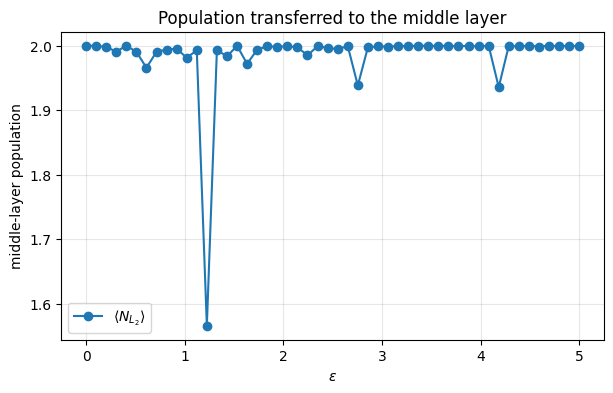

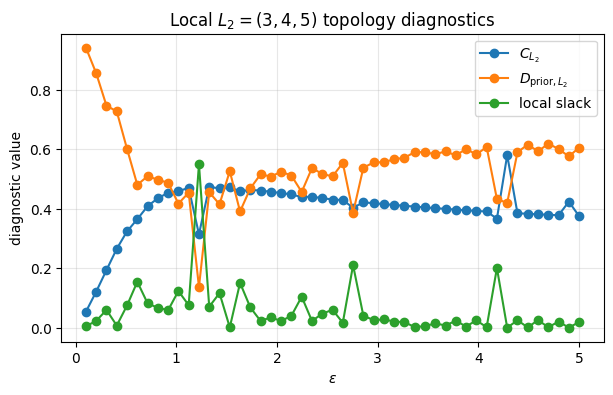

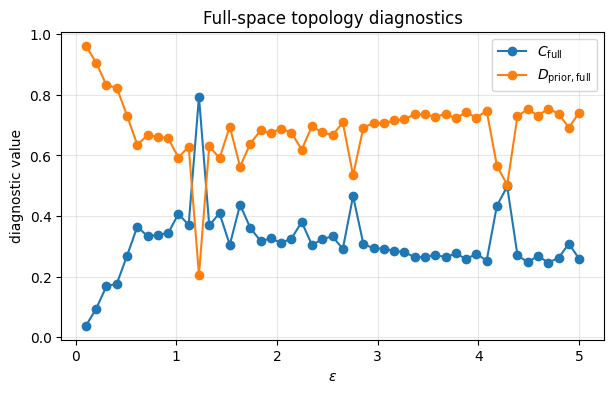

In [420]:
import matplotlib.pyplot as plt

eps_arr = np.array([res["eps"] for res in sweep_232], dtype=float)

L2_occ = np.array([res["layer_occupations"][1] for res in sweep_232], dtype=float)

C_L2 = np.array([
    safe_get(res["details_L2"]["summary"], "C")
    for res in sweep_232
], dtype=float)

Dprior_L2 = np.array([
    safe_get(res["details_L2"]["summary"], "D_prior_population_imbalance")
    for res in sweep_232
], dtype=float)

slack_L2 = np.array([
    safe_get(res["details_L2"]["summary"], "slack")
    for res in sweep_232
], dtype=float)

C_full = np.array([
    safe_get(res["details_full"]["summary"], "C")
    for res in sweep_232
], dtype=float)

Dprior_full = np.array([
    safe_get(res["details_full"]["summary"], "D_prior_population_imbalance")
    for res in sweep_232
], dtype=float)

plt.figure(figsize=(7, 4))
plt.plot(eps_arr, L2_occ, marker="o", label=r"$\langle N_{L_2}\rangle$")
plt.xlabel(r"$\epsilon$")
plt.ylabel("middle-layer population")
plt.title("Population transferred to the middle layer")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(eps_arr, C_L2, marker="o", label=r"$C_{L_2}$")
plt.plot(eps_arr, Dprior_L2, marker="o", label=r"$D_{\mathrm{prior},L_2}$")
plt.plot(eps_arr, slack_L2, marker="o", label=r"local slack")
plt.xlabel(r"$\epsilon$")
plt.ylabel("diagnostic value")
plt.title(r"Local $L_2=(3,4,5)$ topology diagnostics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(eps_arr, C_full, marker="o", label=r"$C_{\mathrm{full}}$")
plt.plot(eps_arr, Dprior_full, marker="o", label=r"$D_{\mathrm{prior,full}}$")
plt.xlabel(r"$\epsilon$")
plt.ylabel("diagnostic value")
plt.title("Full-space topology diagnostics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [421]:
# ============================================================
# Experiment 2: fixed topology, sweep ancilla coupling chi
# ============================================================

from scipy.sparse import identity, kron, csr_matrix
from scipy.sparse.linalg import expm_multiply
import matplotlib.pyplot as plt

def pauli_z_on_qubit(num_qubits, q):
    """
    Sparse operator Z_q on num_qubits qubits.
    q is 0-indexed and follows the same tensor order as:
        |a0> ⊗ |a1> ⊗ ... ⊗ |a_{num_qubits-1}>
    """
    ops = []
    for i in range(num_qubits):
        if i == q:
            ops.append(sigma_z)
        else:
            ops.append(identity_qubit)

    out = ops[0]
    for op in ops[1:]:
        out = kron(out, op, format="csr")
    return out


def build_dispersion_hamiltonian_232(
    hs,
    monitored_modes=(3, 4, 5),
    num_ancillas=3,
):
    """
    Build the chi-free dispersive Hamiltonian:

        H_disp_base = sum_i n_{mode_i} ⊗ Z_i

    The actual Hamiltonian is chi * H_disp_base.
    """
    dim_ancilla = 2 ** num_ancillas
    H_disp = csr_matrix(
        (hs.dim * dim_ancilla, hs.dim * dim_ancilla),
        dtype=complex,
    )

    for q, mode in enumerate(monitored_modes):
        n_mode = hs.hop(mode, mode)
        Z_q = pauli_z_on_qubit(num_ancillas, q)
        H_disp += kron(n_mode, Z_q, format="csr")

    return H_disp


def prepare_232_after_hop(
    eps=0.5,
    hs=hs_232,
    psi_full0=psi_full0_232,
    dim_ancilla=dim_anc_232,
    J=1.0,
    time_method="opt_hybrid",
):
    """
    Prepare the fixed incoming state after the topology-defined hop.
    This is held fixed during the chi sweep.
    """
    edges = edges12_232_eps(eps, J=J)
    K = K12_232_eps(eps, J=J)
    t1, svals = choose_time_from_K(K, method=time_method)

    H12 = build_H_edges(hs, edges)
    H12_full = kron(
        H12,
        identity(dim_ancilla, format="csr", dtype=complex),
        format="csr",
    )

    psi_after_hop = expm_multiply(
        (-1j * t1) * H12_full,
        psi_full0,
    )

    return {
        "eps": eps,
        "K": K,
        "t1": t1,
        "singular_values": svals,
        "psi_after_hop": psi_after_hop,
    }


def run_232_chi_point(
    chi,
    psi_after_hop,
    H_disp_base,
    hs=hs_232,
    dim_ancilla=dim_anc_232,
    t_int=1.0,
    p_tol=1e-14,
):
    """
    Apply dispersive ancilla interaction at fixed t_int and coupling chi,
    then compute local and full WP diagnostics.
    """
    psi_after_int = expm_multiply(
        (-1j * chi * t_int) * H_disp_base,
        psi_after_hop,
    )

    diag_L2 = wp_layer_diagnostic(
        psi_full=psi_after_int,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(3, 4, 5),
        p_tol=p_tol,
    )

    diag_full = wp_layer_diagnostic(
        psi_full=psi_after_int,
        hs=hs,
        dim_ancilla=dim_ancilla,
        layer_modes=(1, 2, 3, 4, 5, 6, 7),
        p_tol=p_tol,
    )

    details_L2 = decompose_duality_details(
        rho=diag_L2["rho_layer"],
        ancilla_states=diag_L2["conditioned_ancilla_states"],
        probs=diag_L2["probabilities"],
        configs=diag_L2["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    details_full = decompose_duality_details(
        rho=diag_full["rho_layer"],
        ancilla_states=diag_full["conditioned_ancilla_states"],
        probs=diag_full["probabilities"],
        configs=diag_full["configs"],
        p_tol=p_tol,
        top_k=5,
    )

    return {
        "chi": chi,
        "theta": chi * t_int,
        "psi_after_int": psi_after_int,
        "diag_L2": diag_L2,
        "diag_full": diag_full,
        "details_L2": details_L2,
        "details_full": details_full,
    }


def summarize_chi_sweep(results):
    print(
        f"{'chi':>8} {'theta':>8} "
        f"{'C_L2':>10} {'Dprior_L2':>12} {'Ddet_L2':>10} {'slack_L2':>10} "
        f"{'C_full':>10} {'Dprior_full':>13} {'Ddet_full':>11} {'slack_full':>11}"
    )

    for res in results:
        sL = res["details_L2"]["summary"]
        sF = res["details_full"]["summary"]

        print(
            f"{res['chi']:8.4f} {res['theta']:8.4f} "
            f"{sL['C']:10.4f} "
            f"{sL['D_prior_population_imbalance']:12.4f} "
            f"{sL['D_detector_from_fidelity_loss']:10.4f} "
            f"{sL['slack']:10.4f} "
            f"{sF['C']:10.4f} "
            f"{sF['D_prior_population_imbalance']:13.4f} "
            f"{sF['D_detector_from_fidelity_loss']:11.4f} "
            f"{sF['slack']:11.4e}"
        )

In [422]:
# Fixed topology and hopping time
eps_fixed = 0.5
t_int_fixed = 1.0

prep_232 = prepare_232_after_hop(
    eps=eps_fixed,
    hs=hs_232,
    psi_full0=psi_full0_232,
    dim_ancilla=dim_anc_232,
)

psi_after_hop_fixed = prep_232["psi_after_hop"]

H_disp_base_232 = build_dispersion_hamiltonian_232(
    hs=hs_232,
    monitored_modes=(3, 4, 5),
    num_ancillas=3,
)

print("eps fixed:", prep_232["eps"])
print("t1 fixed:", prep_232["t1"])
print("singular values:", prep_232["singular_values"])
print("t_int fixed:", t_int_fixed)

eps fixed: 0.5
t1 fixed: 14.119695188459087
singular values: [1.22474487 1.        ]
t_int fixed: 1.0


In [423]:
chi_values = np.linspace(0.0, 2.0, 21)

chi_sweep_232 = []

for chi in chi_values:
    res = run_232_chi_point(
        chi=chi,
        psi_after_hop=psi_after_hop_fixed,
        H_disp_base=H_disp_base_232,
        hs=hs_232,
        dim_ancilla=dim_anc_232,
        t_int=t_int_fixed,
    )
    chi_sweep_232.append(res)

summarize_chi_sweep(chi_sweep_232)

     chi    theta       C_L2    Dprior_L2    Ddet_L2   slack_L2     C_full   Dprior_full   Ddet_full  slack_full
  0.0000   0.0000     0.3206       0.6626     0.0000     0.0168     0.2194        0.7806      0.0000 -2.7756e-17
  0.1000   0.1000     0.3157       0.6626     0.0050     0.0166     0.2161        0.7806      0.0033  4.8472e-09
  0.2000   0.2000     0.3016       0.6626     0.0197     0.0161     0.2066        0.7806      0.0128  4.7175e-09
  0.3000   0.3000     0.2793       0.6626     0.0428     0.0152     0.1916        0.7806      0.0278  4.0971e-09
  0.4000   0.4000     0.2507       0.6626     0.0726     0.0141     0.1723        0.7806      0.0470  4.3359e-09
  0.5000   0.5000     0.2179       0.6626     0.1066     0.0128     0.1502        0.7806      0.0691  3.4979e-09
  0.6000   0.6000     0.1834       0.6626     0.1426     0.0114     0.1269        0.7806      0.0925  2.8076e-09
  0.7000   0.7000     0.1493       0.6626     0.1782     0.0099     0.1038        0.7806      0.

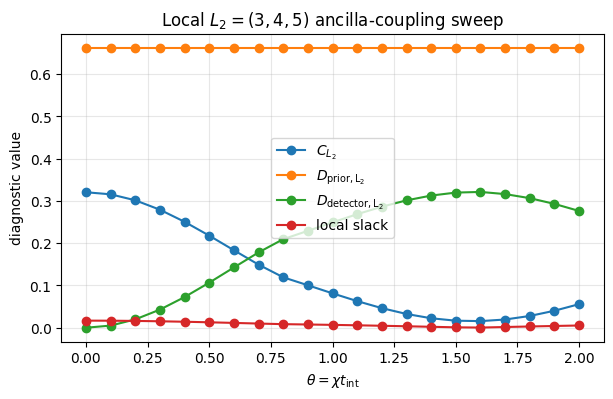

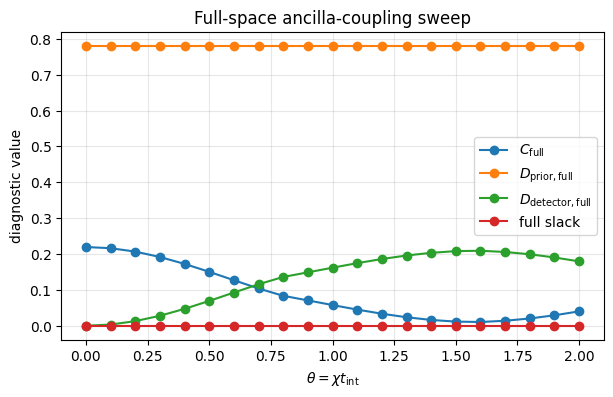

In [424]:
chi_arr = np.array([res["chi"] for res in chi_sweep_232])
theta_arr = np.array([res["theta"] for res in chi_sweep_232])

C_L2 = np.array([res["details_L2"]["summary"]["C"] for res in chi_sweep_232])
Dprior_L2 = np.array([res["details_L2"]["summary"]["D_prior_population_imbalance"] for res in chi_sweep_232])
Ddet_L2 = np.array([res["details_L2"]["summary"]["D_detector_from_fidelity_loss"] for res in chi_sweep_232])
slack_L2 = np.array([res["details_L2"]["summary"]["slack"] for res in chi_sweep_232])

C_full = np.array([res["details_full"]["summary"]["C"] for res in chi_sweep_232])
Dprior_full = np.array([res["details_full"]["summary"]["D_prior_population_imbalance"] for res in chi_sweep_232])
Ddet_full = np.array([res["details_full"]["summary"]["D_detector_from_fidelity_loss"] for res in chi_sweep_232])
slack_full = np.array([res["details_full"]["summary"]["slack"] for res in chi_sweep_232])

plt.figure(figsize=(7, 4))
plt.plot(theta_arr, C_L2, marker="o", label=r"$C_{L_2}$")
plt.plot(theta_arr, Dprior_L2, marker="o", label=r"$D_{\rm prior,L_2}$")
plt.plot(theta_arr, Ddet_L2, marker="o", label=r"$D_{\rm detector,L_2}$")
plt.plot(theta_arr, slack_L2, marker="o", label=r"local slack")
plt.xlabel(r"$\theta=\chi t_{\rm int}$")
plt.ylabel("diagnostic value")
plt.title(r"Local $L_2=(3,4,5)$ ancilla-coupling sweep")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(theta_arr, C_full, marker="o", label=r"$C_{\rm full}$")
plt.plot(theta_arr, Dprior_full, marker="o", label=r"$D_{\rm prior,full}$")
plt.plot(theta_arr, Ddet_full, marker="o", label=r"$D_{\rm detector,full}$")
plt.plot(theta_arr, slack_full, marker="o", label=r"full slack")
plt.xlabel(r"$\theta=\chi t_{\rm int}$")
plt.ylabel("diagnostic value")
plt.title("Full-space ancilla-coupling sweep")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [425]:
# ============================================================
# Small-theta ancilla Y-readout diagnostic
# ============================================================

pauli_X = np.array([[0, 1], [1, 0]], dtype=complex)
pauli_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
pauli_Z = np.array([[1, 0], [0, -1]], dtype=complex)
id2 = np.eye(2, dtype=complex)


def dense_op_on_qubit(num_qubits, q, op):
    """
    Dense operator acting with op on qubit q and identity elsewhere.
    q is 0-indexed.
    """
    ops = [op if i == q else id2 for i in range(num_qubits)]
    out = ops[0]
    for next_op in ops[1:]:
        out = np.kron(out, next_op)
    return out


def conditioned_ancilla_xyz_table(diag, num_qubits=3, p_tol=1e-14):
    """
    For each active local configuration, compute conditioned ancilla
    expectation values <X_q>, <Y_q>, <Z_q>.
    """
    probs = diag["probabilities"]
    anc_states = diag["conditioned_ancilla_states"]

    rows = []

    X_ops = [dense_op_on_qubit(num_qubits, q, pauli_X) for q in range(num_qubits)]
    Y_ops = [dense_op_on_qubit(num_qubits, q, pauli_Y) for q in range(num_qubits)]
    Z_ops = [dense_op_on_qubit(num_qubits, q, pauli_Z) for q in range(num_qubits)]

    for cfg in diag["active_configs"]:
        if probs[cfg] <= p_tol:
            continue

        rho_A = anc_states[cfg]

        row = {
            "config": cfg,
            "probability": probs[cfg],
        }

        for q in range(num_qubits):
            row[f"X{q+1}"] = float(np.real(np.trace(rho_A @ X_ops[q])))
            row[f"Y{q+1}"] = float(np.real(np.trace(rho_A @ Y_ops[q])))
            row[f"Z{q+1}"] = float(np.real(np.trace(rho_A @ Z_ops[q])))

        rows.append(row)

    return rows


def add_y_readout_estimates(rows, theta, sign=-1.0, num_qubits=3):
    """
    Add estimated occupations from <Y_q>:

        n_hat_q = sign * <Y_q> / (2 theta)

    Use sign=-1 if your convention gives <Y> ≈ -2 theta n.
    Use sign=+1 if your convention gives <Y> ≈ +2 theta n.
    """
    out = []

    for row in rows:
        new_row = dict(row)
        cfg = row["config"]

        sq_error = 0.0
        abs_error = 0.0

        for q in range(num_qubits):
            n_true = cfg[q]
            n_hat = sign * row[f"Y{q+1}"] / (2.0 * theta)

            new_row[f"n{q+1}_true"] = n_true
            new_row[f"n{q+1}_hat"] = n_hat
            new_row[f"n{q+1}_err"] = n_hat - n_true

            sq_error += (n_hat - n_true) ** 2
            abs_error += abs(n_hat - n_true)

        new_row["sq_error"] = sq_error
        new_row["abs_error"] = abs_error
        out.append(new_row)

    return out


def print_y_readout_table(rows, num_qubits=3):
    """
    Compact table comparing true occupations with Y-based estimates.
    """
    header = f"{'config':>12} {'p':>10}"
    for q in range(num_qubits):
        header += f" {'Y'+str(q+1):>9} {'n'+str(q+1)+'_hat':>9}"
    header += f" {'sq_err':>10}"
    print(header)

    for row in rows:
        line = f"{str(row['config']):>12} {row['probability']:10.6f}"
        for q in range(num_qubits):
            line += f" {row[f'Y{q+1}']:9.4f} {row[f'n{q+1}_hat']:9.4f}"
        line += f" {row['sq_error']:10.4e}"
        print(line)

In [426]:
target_theta = 0.1

idx = int(np.argmin(np.abs(theta_arr - target_theta)))
res_small = chi_sweep_232[idx]
theta_small = res_small["theta"]

diag_L2_small = res_small["diag_L2"]

rows_xyz = conditioned_ancilla_xyz_table(
    diag=diag_L2_small,
    num_qubits=3,
)

rows_readout = add_y_readout_estimates(
    rows=rows_xyz,
    theta=theta_small,
    sign=-1.0,
    num_qubits=3,
)

print("theta used:", theta_small)
print_y_readout_table(rows_readout, num_qubits=3)

theta used: 0.1
      config          p        Y1    n1_hat        Y2    n2_hat        Y3    n3_hat     sq_err
   (0, 0, 0)   0.000000    0.0000   -0.0000    0.0000   -0.0000    0.0000   -0.0000 0.0000e+00
   (0, 0, 1)   0.000220    0.0000   -0.0000    0.0000   -0.0000   -0.1987    0.9933 4.4267e-05
   (0, 0, 2)   0.013875    0.0000   -0.0000    0.0000   -0.0000   -0.3894    1.9471 2.7993e-03
   (0, 1, 0)   0.000068    0.0000   -0.0000   -0.1987    0.9933    0.0000   -0.0000 4.4267e-05
   (0, 1, 1)   0.111066    0.0000   -0.0000   -0.1987    0.9933   -0.1987    0.9933 8.8534e-05
   (0, 2, 0)   0.055533    0.0000   -0.0000   -0.3894    1.9471    0.0000   -0.0000 2.7993e-03
   (1, 0, 0)   0.000220   -0.1987    0.9933    0.0000   -0.0000    0.0000   -0.0000 4.4267e-05
   (1, 0, 1)   0.694077   -0.1987    0.9933    0.0000   -0.0000   -0.1987    0.9933 8.8534e-05
   (1, 1, 0)   0.111066   -0.1987    0.9933   -0.1987    0.9933    0.0000   -0.0000 8.8534e-05
   (2, 0, 0)   0.013875   -0.3894 

# Benchmark: reproducing Englert's two-path duality experiment in the graph framework

Before applying the wave-particle diagnostic to larger modular photonic circuits, we first check that it reproduces the canonical two-path which-way experiment. The goal is not only to generate ordinary two-path fringes, but to verify that the mid-circuit quantity used in our framework is as informative as the standard Englert visibility-distinguishability relation once the paths are recombined.

We model a single photon in two optical modes. The photon starts in mode $1$. A 50:50 beamsplitter is implemented as hopping evolution on the graph edge $(1,2)$,

$$
H_{\mathrm{BS}} = J(a_1^\dagger a_2 + a_2^\dagger a_1),
$$

for time

$$
t_{\mathrm{BS}} = \frac{\pi}{4J}.
$$

This creates a coherent superposition of the two paths. The which-way detector is implemented using the same detector model as in the rest of the notebook: one ancilla qubit is assigned to each monitored mode, and each ancilla is dispersively coupled to the corresponding photon number operator. For the two-path benchmark this gives

$$
H_{\mathrm{WWD}}
=
\chi
\left(
n_1 \otimes Z_1
+
n_2 \otimes Z_2
\right),
$$

with both ancillas initialized in $|+\rangle$. The interaction is applied for time $t_{\mathrm{int}}$, and we define

$$
\theta = \chi t_{\mathrm{int}}.
$$

Because there is exactly one photon, $n_1$ and $n_2$ act as path projectors. Thus, if the photon is in path $1$, ancilla $1$ is rotated; if the photon is in path $2$, ancilla $2$ is rotated. The corresponding conditional detector states are

$$
|D_1\rangle =
e^{-i\theta Z_1}|+\rangle_1 \otimes |+\rangle_2,
$$

$$
|D_2\rangle =
|+\rangle_1 \otimes e^{-i\theta Z_2}|+\rangle_2.
$$

Their overlap is

$$
\gamma = \langle D_2|D_1\rangle = \cos^2\theta.
$$

After the which-way interaction, a relative phase shifter is applied,

$$
U_{\mathrm{PS}}(\phi)
=
\exp\left[
i\frac{\phi}{2}(n_1-n_2)
\right],
$$

and the two paths are recombined by a second 50:50 hopping evolution. The final output population $P_1(\phi)=\langle n_1\rangle$ is measured as a function of $\phi$, and the numerical fringe visibility is extracted as

$$
V_{\mathrm{num}}
=
\frac{P_{\max}-P_{\min}}{P_{\max}+P_{\min}}.
$$

For the balanced pure-state two-path experiment, Englert's relation reads

$$
D_{\mathrm{E}}^2 + V^2 \le 1,
$$

with

$$
V = |\gamma|,
\qquad
D_{\mathrm{E}} = \sqrt{1-|\gamma|^2}.
$$

Our notebook diagnostic instead uses a coherence-information tradeoff of the form

$$
C + D_A \le 1.
$$

In this two-path pure-state limit, the active-support coherence reduces to

$$
C = |\gamma| = V,
$$

while the ancilla information term reduces to

$$
D_A = 1-|\gamma| = 1-V.
$$

Therefore our relation saturates as

$$
C+D_A = 1,
$$

and it contains the same information as Englert's relation through the monotonic conversion

$$
D_{\mathrm{E}}
=
\sqrt{1-(1-D_A)^2}.
$$

This benchmark shows that the mid-circuit diagnostic used in our framework predicts the same loss of final interference visibility as the standard two-path relation. The advantage of the present formulation is that $C$ and $D_A$ are defined directly from coherences and conditional detector states over active configurations. This makes them more natural for many-body, multi-photon, and multi-mode settings where a two-path distinguishability $D_{\mathrm{E}}$ is no longer the most convenient object.

In [427]:
# ============================================================
# Englert two-path benchmark using the notebook detector model:
# one dispersive ancilla per monitored mode
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import identity, kron, csr_matrix
from scipy.sparse.linalg import expm_multiply


def make_fixedN_hs_two_modes_one_photon():
    """
    Construct the one-photon/two-mode Hilbert space using the notebook class.
    """
    try:
        return FixedNBosons(m=2, N=1)
    except TypeError:
        try:
            return FixedNBosons(n_modes=2, N=1)
        except TypeError:
            return FixedNBosons(2, 1)


def ket_dense(i, d):
    v = np.zeros(d, dtype=complex)
    v[i] = 1.0
    return v


def hs_ket_from_occupation(hs, occ):
    """
    Return |occ> from the notebook Hilbert-space object.
    Uses hs.ket if available; otherwise constructs the basis vector manually.
    """
    if hasattr(hs, "ket"):
        return np.asarray(hs.ket(occ), dtype=complex)

    idx = hs.basis.index(tuple(occ))
    v = np.zeros(len(hs.basis), dtype=complex)
    v[idx] = 1.0
    return v


def photon_number_expectation_from_full_state(psi_full, hs, dim_ancilla, mode):
    """
    Compute <n_mode> for a state in H_photon ⊗ H_ancilla.

    mode is 1-indexed, consistently with hs.hop(mode, mode).
    """
    n_mode = hs.hop(mode, mode)
    N_full = kron(
        n_mode,
        identity(dim_ancilla, format="csr", dtype=complex),
        format="csr",
    )
    return float(np.real(np.vdot(psi_full, N_full @ psi_full)))


def sparse_op_on_qubit(num_qubits, q, op):
    """
    Sparse operator acting with op on qubit q and identity elsewhere.

    q is 0-indexed.
    """
    ops = []
    for i in range(num_qubits):
        if i == q:
            ops.append(op)
        else:
            ops.append(identity_qubit)

    out = ops[0]
    for next_op in ops[1:]:
        out = kron(out, next_op, format="csr")

    return out


def build_englert_dispersion_hamiltonian(hs):
    """
    Build the chi-free dispersive which-way Hamiltonian for the two-path test:

        H_disp_base = n_1 ⊗ Z_1 + n_2 ⊗ Z_2.

    The actual interaction is generated by

        exp[-i theta H_disp_base],

    where theta = chi * t_int.

    This matches the notebook model: one ancilla qubit per monitored mode.
    """
    num_ancillas = 2
    dim_ancilla = 2 ** num_ancillas

    n1 = hs.hop(1, 1)
    n2 = hs.hop(2, 2)

    Z1 = sparse_op_on_qubit(num_ancillas, 0, sigma_z)
    Z2 = sparse_op_on_qubit(num_ancillas, 1, sigma_z)

    H_disp_base = kron(n1, Z1, format="csr") + kron(n2, Z2, format="csr")

    return H_disp_base


def build_relative_phase_unitary(hs, phi):
    """
    Build

        U_PS(phi) = exp[i phi/2 (n_1 - n_2)]

    in the one-photon/two-mode Hilbert space.
    """
    diag = []

    for occ in hs.basis:
        n1 = occ[0]
        n2 = occ[1]
        diag.append(np.exp(1j * phi * (n1 - n2) / 2))

    return csr_matrix(np.diag(diag))


def detector_overlap_two_dispersive_ancillas(theta):
    """
    For the notebook detector model:

        path 1: exp[-i theta Z_1]|+>_1 ⊗ |+>_2
        path 2: |+>_1 ⊗ exp[-i theta Z_2]|+>_2

    The detector-state overlap is

        gamma = cos(theta)^2.

    We compute it explicitly here to avoid relying only on the formula.
    """
    plus = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)

    U = np.diag([np.exp(-1j * theta), np.exp(1j * theta)])

    D1 = np.kron(U @ plus, plus)
    D2 = np.kron(plus, U @ plus)

    gamma = np.vdot(D2, D1)
    return gamma


def englert_midstate_and_visibility(theta, phis, J=1.0):
    """
    Build the graph-based two-path Englert experiment using the notebook
    one-ancilla-per-mode dispersive detector model.

    Circuit:
        input |1,0> ⊗ |+,+>
          -> graph beamsplitter on edge (1,2)
          -> dispersive WWD: exp[-i theta (n_1 Z_1 + n_2 Z_2)]
          -> relative phase shifter
          -> graph beam merger on edge (1,2)
          -> output population <n_1>(phi)

    Expected:
        gamma = cos(theta)^2
        V_num ≈ |gamma|
        C_mid ≈ |gamma|
        D_A ≈ 1 - |gamma|
        D_E = sqrt(1 - |gamma|^2)
    """
    hs2 = make_fixedN_hs_two_modes_one_photon()

    num_ancillas = 2
    dim_ancilla = 2 ** num_ancillas

    plus = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)
    psi_anc0 = np.kron(plus, plus)

    # Initial photonic state |1,0>, i.e. one photon in mode 1.
    psi_ph0 = hs_ket_from_occupation(hs2, (1, 0))
    psi_full0 = np.kron(psi_ph0, psi_anc0)

    # Graph Hamiltonian implementing both beamsplitter and beam merger.
    edges_bs = [(1, 2, J)]
    H_bs = build_H_edges(hs2, edges_bs)
    H_bs_full = kron(
        H_bs,
        identity(dim_ancilla, format="csr", dtype=complex),
        format="csr",
    )

    t_bs = np.pi / (4 * J)

    # First 50:50 beamsplitter.
    psi_after_bs = expm_multiply((-1j * t_bs) * H_bs_full, psi_full0)

    # Which-way detector interaction in the notebook dispersive model.
    H_disp_base = build_englert_dispersion_hamiltonian(hs2)
    psi_after_wwd = expm_multiply((-1j * theta) * H_disp_base, psi_after_bs)

    # Detector-overlap theory for this detector model.
    gamma = detector_overlap_two_dispersive_ancillas(theta)
    V_theory = abs(gamma)
    D_englert_theory = np.sqrt(max(0.0, 1.0 - V_theory**2))

    # Final fringe after phase scan and recombination.
    probs_n1 = []

    for phi in phis:
        U_PS = build_relative_phase_unitary(hs2, phi)
        U_PS_full = kron(
            U_PS,
            identity(dim_ancilla, format="csr", dtype=complex),
            format="csr",
        )

        psi_after_ps = U_PS_full @ psi_after_wwd

        # Second 50:50 hopping evolution = beam merger.
        psi_final = expm_multiply((-1j * t_bs) * H_bs_full, psi_after_ps)

        p1 = photon_number_expectation_from_full_state(
            psi_final,
            hs=hs2,
            dim_ancilla=dim_ancilla,
            mode=1,
        )

        probs_n1.append(p1)

    probs_n1 = np.array(probs_n1)

    Pmax = float(np.max(probs_n1))
    Pmin = float(np.min(probs_n1))
    V_num = (Pmax - Pmin) / (Pmax + Pmin)

    return {
        "hs": hs2,
        "dim_D": dim_ancilla,
        "num_ancillas": num_ancillas,
        "psi_after_wwd": psi_after_wwd,
        "probs_n1": probs_n1,
        "theta": theta,
        "gamma": gamma,
        "gamma_abs": abs(gamma),
        "V_theory": V_theory,
        "D_englert_theory": D_englert_theory,
        "V_num": V_num,
        "Pmax": Pmax,
        "Pmin": Pmin,
        "t_bs": t_bs,
    }

In [428]:
# ============================================================
# Compare Englert's relation with the notebook relation
# using the notebook detector model
# ============================================================

def benchmark_notebook_inequality_against_englert(theta_values, phis, J=1.0, plot_fringes=False):
    """
    For each detector strength theta:

        1. Build the two-path graph interferometer.
        2. Stop immediately after the dispersive which-way detector.
        3. Compute the notebook diagnostic C + D_A <= 1.
        4. Continue through phase scan and recombination.
        5. Extract final fringe visibility V_num.
        6. Compare with Englert's relation.

    Expected for this two-ancilla notebook detector model:

        gamma = cos(theta)^2
        C_mid ≈ V_num ≈ |gamma|
        D_A ≈ 1 - |gamma|
        C_mid + D_A ≈ 1

    and

        D_E_from_DA = sqrt(1 - (1 - D_A)^2)
        D_E_from_DA^2 + V_num^2 ≈ 1.
    """
    rows = []

    for theta in theta_values:
        data = englert_midstate_and_visibility(
            theta=theta,
            phis=phis,
            J=J,
        )

        hs2 = data["hs"]
        dim_D = data["dim_D"]
        psi_after_wwd = data["psi_after_wwd"]

        # Key call to the notebook diagnostic.
        # We diagnose the two path modes after the WWD, before recombination.
        diag_mid = wp_layer_diagnostic(
            psi_full=psi_after_wwd,
            hs=hs2,
            dim_ancilla=dim_D,
            layer_modes=(1, 2),
        )

        C_mid = float(diag_mid["C"])
        D_A = float(diag_mid["D_A"])
        C_plus_DA = C_mid + D_A

        V_num = float(data["V_num"])

        # Englert distinguishability recovered from the notebook quantities
        # in the balanced two-path pure-state case.
        D_englert_from_C = np.sqrt(max(0.0, 1.0 - C_mid**2))
        D_englert_from_DA = np.sqrt(max(0.0, 1.0 - (1.0 - D_A)**2))

        rows.append({
            "theta": float(theta),
            "gamma_abs": float(data["gamma_abs"]),
            "C_mid": C_mid,
            "D_A": D_A,
            "C_plus_DA": C_plus_DA,
            "V_num": V_num,
            "V_theory": float(data["V_theory"]),
            "D_englert_theory": float(data["D_englert_theory"]),
            "D_englert_from_C": float(D_englert_from_C),
            "D_englert_from_DA": float(D_englert_from_DA),
            "Englert_theory_sum": float(data["D_englert_theory"]**2 + V_num**2),
            "Englert_from_C_sum": float(D_englert_from_C**2 + V_num**2),
            "Englert_from_DA_sum": float(D_englert_from_DA**2 + V_num**2),
            "abs_C_minus_V": float(abs(C_mid - V_num)),
            "abs_CplusDA_minus_1": float(abs(C_plus_DA - 1.0)),
            "probs_n1": data["probs_n1"],
        })

        if plot_fringes:
            plt.figure(figsize=(6, 4))
            plt.plot(phis, data["probs_n1"])
            plt.xlabel(r"$\phi$")
            plt.ylabel(r"$P_1(\phi)=\langle n_1\rangle$")
            plt.title(
                rf"$\theta={theta:.3f}$, "
                rf"$C={C_mid:.3f}$, $D_A={D_A:.3f}$, "
                rf"$V={V_num:.3f}$"
            )
            plt.grid(True, alpha=0.3)
            plt.show()

    return rows


phis = np.linspace(0, 2 * np.pi, 801)

# With the two-ancilla dispersive model, gamma = cos(theta)^2.
# At theta = pi/2, the detector states become orthogonal and visibility vanishes.
theta_values = np.linspace(0, np.pi / 2, 9)

englert_rows = benchmark_notebook_inequality_against_englert(
    theta_values=theta_values,
    phis=phis,
    J=1.0,
    plot_fringes=False,
)

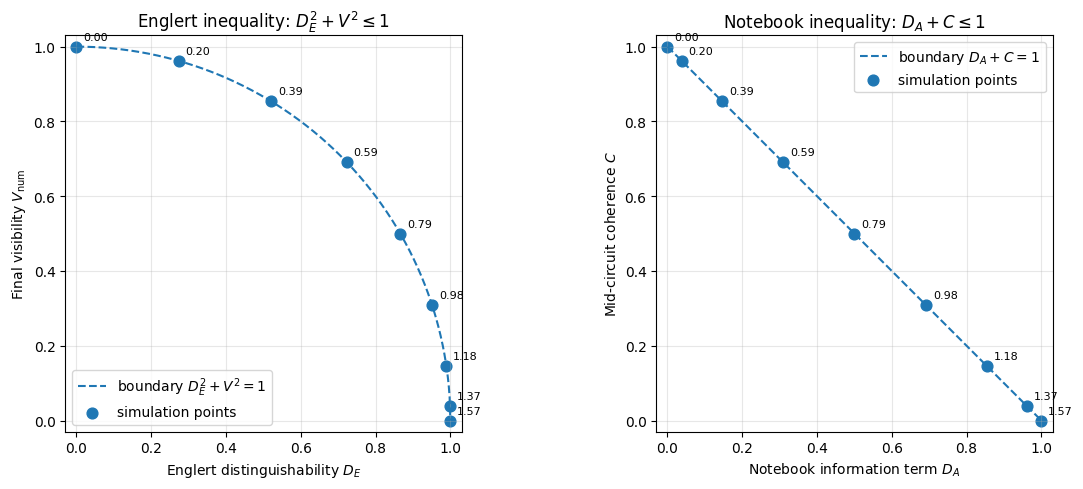

In [429]:
# ============================================================
# Plot the inequality geometry directly
# ============================================================

theta_arr = np.array([r["theta"] for r in englert_rows])

V_arr = np.array([r["V_num"] for r in englert_rows])
C_arr = np.array([r["C_mid"] for r in englert_rows])
DA_arr = np.array([r["D_A"] for r in englert_rows])

# Englert distinguishability reconstructed from our D_A.
D_E_arr = np.sqrt(np.maximum(0.0, 1.0 - (1.0 - DA_arr)**2))

# Boundaries
x = np.linspace(0, 1, 500)

# Englert boundary: D_E^2 + V^2 = 1
D_boundary = x
V_boundary_englert = np.sqrt(np.maximum(0.0, 1.0 - D_boundary**2))

# Our boundary: D_A + C = 1
DA_boundary = x
C_boundary = 1.0 - DA_boundary

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ------------------------------------------------------------
# Englert inequality plane
# ------------------------------------------------------------
axes[0].plot(
    D_boundary,
    V_boundary_englert,
    linestyle="--",
    label=r"boundary $D_E^2+V^2=1$",
)

axes[0].scatter(
    D_E_arr,
    V_arr,
    s=60,
    label="simulation points",
)

for theta, D_E, V in zip(theta_arr, D_E_arr, V_arr):
    axes[0].annotate(
        rf"{theta:.2f}",
        (D_E, V),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

axes[0].set_xlabel(r"Englert distinguishability $D_E$")
axes[0].set_ylabel(r"Final visibility $V_{\rm num}$")
axes[0].set_title(r"Englert inequality: $D_E^2+V^2\leq 1$")
axes[0].set_xlim(-0.03, 1.03)
axes[0].set_ylim(-0.03, 1.03)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ------------------------------------------------------------
# Notebook inequality plane
# ------------------------------------------------------------
axes[1].plot(
    DA_boundary,
    C_boundary,
    linestyle="--",
    label=r"boundary $D_A+C=1$",
)

axes[1].scatter(
    DA_arr,
    C_arr,
    s=60,
    label="simulation points",
)

for theta, DA, C in zip(theta_arr, DA_arr, C_arr):
    axes[1].annotate(
        rf"{theta:.2f}",
        (DA, C),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

axes[1].set_xlabel(r"Notebook information term $D_A$")
axes[1].set_ylabel(r"Mid-circuit coherence $C$")
axes[1].set_title(r"Notebook inequality: $D_A+C\leq 1$")
axes[1].set_xlim(-0.03, 1.03)
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## explicit derivation of the inequalities for this specific case
In the notebook detector model, the two-path which-way interaction is implemented with one ancilla per monitored mode,

$$
H_{\mathrm{WWD}}
=
\chi(n_1\otimes Z_1+n_2\otimes Z_2).
$$

We initialize both ancillas in $|+\rangle$, and define

$$
\theta=\chi t_{\mathrm{int}}.
$$

After the first 50:50 beamsplitter, the photonic state is a balanced superposition of the two paths. Up to irrelevant phases, after the which-way interaction the joint photon-detector state has the form

$$
|\Psi\rangle
=
\frac{1}{\sqrt{2}}
\left(
|1,0\rangle |D_1\rangle
+
e^{i\varphi}|0,1\rangle |D_2\rangle
\right),
$$

where

$$
|D_1\rangle
=
e^{-i\theta Z_1}|+\rangle_1\otimes |+\rangle_2,
$$

and

$$
|D_2\rangle
=
|+\rangle_1\otimes e^{-i\theta Z_2}|+\rangle_2.
$$

The detector-state overlap is

$$
\gamma
=
\langle D_2|D_1\rangle.
$$

Using

$$
\langle +|e^{-i\theta Z}|+\rangle=\cos\theta,
$$

we obtain

$$
\gamma
=
\cos\theta\cos\theta
=
\cos^2\theta.
$$

Tracing out the detector gives the reduced photonic state

$$
\rho_{\mathrm{ph}}
=
\frac{1}{2}
|1,0\rangle\langle 1,0|
+
\frac{1}{2}
|0,1\rangle\langle 0,1|
+
\frac{\gamma}{2}e^{-i\varphi}
|1,0\rangle\langle 0,1|
+
\frac{\gamma^*}{2}e^{i\varphi}
|0,1\rangle\langle 1,0|.
$$

The active support contains two configurations,

$$
R=2,
$$

namely $|1,0\rangle$ and $|0,1\rangle$. Therefore the notebook active-support coherence becomes

$$
C
=
\sum_{\mu\neq\nu}|\rho_{\mu\nu}|
=
2\frac{|\gamma|}{2}
=
|\gamma|.
$$

Hence, in this benchmark,

$$
C=|\gamma|=\cos^2\theta.
$$

The notebook ancilla information term is based on the fidelity between the detector states conditioned on the active configurations. Since the conditional detector states are pure,

$$
F(\rho_A^1,\rho_A^2)
=
|\langle D_2|D_1\rangle|
=
|\gamma|.
$$

For two balanced paths, the notebook information term reduces to

$$
D_A
=
1-F(\rho_A^1,\rho_A^2)
=
1-|\gamma|.
$$

Thus,

$$
C+D_A
=
|\gamma|+(1-|\gamma|)
=
1.
$$

Englert's distinguishability for two pure detector states with equal path priors is

$$
D_E
=
\sqrt{1-|\langle D_2|D_1\rangle|^2}
=
\sqrt{1-|\gamma|^2}.
$$

The final fringe visibility after recombination is

$$
V=|\gamma|.
$$

Therefore Englert's relation also saturates,

$$
D_E^2+V^2
=
(1-|\gamma|^2)+|\gamma|^2
=
1.
$$

The two relations therefore encode the same information in this benchmark:

$$
C=V,
$$

$$
D_A=1-V,
$$

and

$$
D_E
=
\sqrt{1-(1-D_A)^2}.
$$

The important distinction is structural. Englert's $D_E$ is naturally a two-alternative path-discrimination quantity, whereas $C$ and $D_A$ are defined directly from coherences and conditional detector states on the active configuration support. This is why the notebook relation is more convenient to extend to many-body, multi-mode, and coarse-grained modular settings.

## Postselected 4-4-2 semantic classifier: blue square task

We now build a small semantic classification example inspired by the single-photon quantum PS setting. The architecture has three layers:

- input layer: 4 modes;
- middle feature layer: 4 modes;
- output action layer: 2 modes.

The ten modes are interpreted as

$$
(1,2,3,4) = (RS,RC,BS,BC),
$$

$$
(5,6,7,8) = (R,B,S,C),
$$

and

$$
(9,10) = (\mathrm{no},\mathrm{yes}).
$$

The task is

$$
\text{“Is the object a blue square?”}
$$

so the correct answer is yes only for $BS$, and no for $RS$, $RC$, and $BC$.

Following the postselected action-readout logic of the quantum PS implementation, we do not require all population to end in the two output modes. Instead, we interpret only modes $9$ and $10$ as action modes and define

$$
P_{\mathrm{yes}}^{\mathrm{post}}
=
\frac{P_{\mathrm{yes}}}{P_{\mathrm{yes}}+P_{\mathrm{no}}},
$$

$$
P_{\mathrm{no}}^{\mathrm{post}}
=
\frac{P_{\mathrm{no}}}{P_{\mathrm{yes}}+P_{\mathrm{no}}}.
$$

We also keep track of

$$
P_{\mathrm{act}}
=
P_{\mathrm{yes}}+P_{\mathrm{no}},
$$

because postselection can hide how much amplitude remains in non-action modes.

In [430]:
# ============================================================
# 4-4-2 semantic classifier: setup and helper functions
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Several analysis sections intentionally create many figures.
plt.rcParams["figure.max_open_warning"] = 0

from scipy.sparse import identity, kron, csr_matrix
from scipy.sparse.linalg import expm_multiply


# ------------------------------------------------------------
# Mode labels
# ------------------------------------------------------------

INPUT_MODES = {
    "RS": 1,  # red square
    "RC": 2,  # red circle
    "BS": 3,  # blue square
    "BC": 4,  # blue circle
}

FEATURE_MODES = {
    "R": 5,
    "B": 6,
    "S": 7,
    "C": 8,
}

OUTPUT_MODES = {
    "no": 9,
    "yes": 10,
}

FEATURE_ORDER = ["R", "B", "S", "C"]
OBJECT_ORDER = ["RS", "RC", "BS", "BC"]


def single_photon_ket(hs, mode):
    """
    Single-photon Fock state with one excitation in a 1-indexed mode.
    """
    occ = [0] * hs.m
    occ[mode - 1] = 1
    return hs.ket(tuple(occ))


def edges_from_K(K, src_modes, dst_modes):
    """
    Convert a coupling matrix K into graph edges.

    K has shape:
        rows = destination modes
        columns = source modes

    Edge convention:
        (src_mode, dst_mode, coupling)
    """
    edges = []
    for r, dst in enumerate(dst_modes):
        for c, src in enumerate(src_modes):
            Jij = K[r, c]
            if abs(Jij) > 1e-14:
                edges.append((src, dst, Jij))
    return edges


def photon_number_expectation(psi, hs, mode):
    """
    Compute <n_mode> for a photonic state without ancillas.
    """
    n_mode = hs.hop(mode, mode)
    return float(np.real(np.vdot(psi, n_mode @ psi)))


def photon_number_expectation_full(psi_full, hs, dim_ancilla, mode):
    """
    Compute <n_mode> for a joint state in H_photon ⊗ H_ancilla.
    """
    n_mode = hs.hop(mode, mode)
    O = kron(
        n_mode,
        identity(dim_ancilla, format="csr", dtype=complex),
        format="csr",
    )
    return float(np.real(np.vdot(psi_full, O @ psi_full)))


def postselected_action_probabilities(P_no, P_yes, eps=1e-14):
    """
    Return postselected no/yes probabilities and action probability.
    """
    P_act = P_no + P_yes

    if P_act < eps:
        return {
            "P_no": P_no,
            "P_yes": P_yes,
            "P_act": P_act,
            "P_no_post": np.nan,
            "P_yes_post": np.nan,
        }

    return {
        "P_no": P_no,
        "P_yes": P_yes,
        "P_act": P_act,
        "P_no_post": P_no / P_act,
        "P_yes_post": P_yes / P_act,
    }


def action_probabilities_photon_state(psi, hs):
    """
    Output probabilities for a photonic state.
    """
    P_no = photon_number_expectation(psi, hs, OUTPUT_MODES["no"])
    P_yes = photon_number_expectation(psi, hs, OUTPUT_MODES["yes"])
    return postselected_action_probabilities(P_no, P_yes)


def action_probabilities_full_state(psi_full, hs, dim_ancilla):
    """
    Output probabilities for a joint photon-ancilla state.
    """
    P_no = photon_number_expectation_full(
        psi_full, hs, dim_ancilla, OUTPUT_MODES["no"]
    )
    P_yes = photon_number_expectation_full(
        psi_full, hs, dim_ancilla, OUTPUT_MODES["yes"]
    )
    return postselected_action_probabilities(P_no, P_yes)


def correct_postselected_probability(object_label, probs):
    """
    Correct postselected probability for the blue-square task.
    """
    if object_label == "BS":
        return probs["P_yes_post"]
    return probs["P_no_post"]

### Readout design

The middle feature layer uses the feature order

$$
(R,B,S,C).
$$

We use phase-coded feature states. The important point is that the target object $BS$ receives a distinctive interference signature:

$$
|RS\rangle_F = \frac{|R\rangle+|S\rangle}{\sqrt{2}},
$$

$$
|RC\rangle_F = \frac{|R\rangle+|C\rangle}{\sqrt{2}},
$$

$$
|BS\rangle_F = \frac{|B\rangle-|S\rangle}{\sqrt{2}},
$$

$$
|BC\rangle_F = \frac{|B\rangle+|C\rangle}{\sqrt{2}}.
$$

The yes readout mode is coupled to the middle-layer vector

$$
|w_{\mathrm{yes}}\rangle
=
\frac{1}{2}
\left(
|R\rangle+|B\rangle-|S\rangle-|C\rangle
\right).
$$

This vector is orthogonal to the three negative examples,

$$
\langle w_{\mathrm{yes}}|RS\rangle_F=0,
$$

$$
\langle w_{\mathrm{yes}}|RC\rangle_F=0,
$$

$$
\langle w_{\mathrm{yes}}|BC\rangle_F=0,
$$

but not to the target state $|BS\rangle_F$. Therefore the yes action only fires for blue square after postselection.

The no readout vector is chosen as

$$
|w_{\mathrm{no}}\rangle
=
\frac{1}{2}
\left(
|R\rangle+|B\rangle+|S\rangle+|C\rangle
\right).
$$

It is orthogonal to the target $BS$ state and has nonzero overlap with the negative examples. The output layer therefore implements a postselected yes/no classifier: the yes/no subspace does not need to receive all amplitude, but when the photon reaches that subspace it should encode the correct action.

In [431]:
# ============================================================
# Ideal middle feature states and engineered output readout
# ============================================================

hs_442 = FixedNBosons(m=10, N=1)

# Feature vectors in order (R, B, S, C)
feature_vectors = {
    "RS": np.array([1, 0, 1, 0], dtype=complex) / np.sqrt(2),
    "RC": np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2),
    "BS": np.array([0, 1, -1, 0], dtype=complex) / np.sqrt(2),
    "BC": np.array([0, 1, 0, 1], dtype=complex) / np.sqrt(2),
}

# Output readout vectors in feature space, order (R, B, S, C)
w_no = np.array([1, 1, 1, 1], dtype=complex) / 2
w_yes = np.array([1, 1, -1, -1], dtype=complex) / 2

# Coupling matrix from features to outputs.
# Rows: (no, yes)
# Columns: (R, B, S, C)
g2 = 1.0
K2 = g2 * np.vstack([w_no.conj(), w_yes.conj()])

print("K2 K2^dagger =")
print(np.round(K2 @ K2.conj().T, 6))

feature_modes_ordered = [FEATURE_MODES[x] for x in FEATURE_ORDER]
output_modes_ordered = [OUTPUT_MODES["no"], OUTPUT_MODES["yes"]]

edges2 = edges_from_K(
    K=K2,
    src_modes=feature_modes_ordered,
    dst_modes=output_modes_ordered,
)

H2 = build_H_edges(hs_442, edges2)

# Because the readout rows are orthonormal and have strength g2,
# this time transfers the row-projection amplitudes to the output modes.
t2 = np.pi / (2 * g2)


def ideal_middle_photon_state(object_label, hs=hs_442):
    """
    Embed an ideal feature vector into the 10-mode photonic Hilbert space.
    """
    vec = feature_vectors[object_label]

    psi = np.zeros(hs.dim, dtype=complex)

    for amp, feature_name in zip(vec, FEATURE_ORDER):
        mode = FEATURE_MODES[feature_name]
        psi += amp * single_photon_ket(hs, mode)

    return psi


def run_ideal_readout_point(object_label):
    """
    Start from the ideal middle feature state and apply the output readout.
    """
    psi_mid = ideal_middle_photon_state(object_label)
    psi_out = evolve(H2, psi_mid, t2)

    probs = action_probabilities_photon_state(psi_out, hs_442)
    probs["object"] = object_label
    probs["correct_post"] = correct_postselected_probability(object_label, probs)

    return probs


ideal_rows = [run_ideal_readout_point(obj) for obj in OBJECT_ORDER]
ideal_df = pd.DataFrame(ideal_rows)

display(
    ideal_df[
        [
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
        ]
    ]
)

K2 K2^dagger =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post
0,RS,0.5,0.0,0.5,1.0,0.0,1.0
1,RC,0.5,0.0,0.5,1.0,0.0,1.0
2,BS,0.0,0.5,0.5,0.0,1.0,1.0
3,BC,0.5,0.0,0.5,1.0,0.0,1.0


### Adding middle-layer ancillas

Now we add the explainability probe. Each middle feature mode is monitored by one ancilla qubit, exactly as in the notebook detector model. The four middle modes are

$$
(R,B,S,C) = (5,6,7,8),
$$

and the dispersive interaction is

$$
H_{\mathrm{int}}
=
\sum_{m\in\{5,6,7,8\}}
n_m\otimes Z_m.
$$

The actual interaction is applied as

$$
U_{\mathrm{int}}(\theta)
=
\exp(-i\theta H_{\mathrm{int}}),
$$

where

$$
\theta = \chi t_{\mathrm{int}}.
$$

As $\theta$ increases, the ancillas store more information about which feature mode the photon occupied. This reduces coherence between feature components. Since the task readout relies on destructive interference that suppresses the wrong action, stronger middle-layer probing should degrade postselected task accuracy and/or reduce action efficiency.

In [432]:
# ============================================================
# Ancilla helpers for middle-layer monitoring
# ============================================================

def op_on_qubit(num_qubits, q, op):
    """
    Sparse operator acting with op on qubit q and identity elsewhere.

    q is 0-indexed and tensor order is:
        |q0> ⊗ |q1> ⊗ ... ⊗ |q_{num_qubits-1}>
    """
    ops = []

    for i in range(num_qubits):
        if i == q:
            ops.append(op)
        else:
            ops.append(identity_qubit)

    out = ops[0]
    for next_op in ops[1:]:
        out = kron(out, next_op, format="csr")

    return out


def plus_state_qubits(num_qubits):
    """
    |+>^{⊗ num_qubits}.
    """
    plus = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)
    psi = plus

    for _ in range(num_qubits - 1):
        psi = np.kron(psi, plus)

    return psi


def build_middle_dispersion_hamiltonian(hs, monitored_modes):
    """
    Build the theta-free middle-layer dispersive Hamiltonian:

        H_int_base = sum_q n_{mode_q} ⊗ Z_q.

    The interaction is exp[-i theta H_int_base].
    """
    num_ancillas = len(monitored_modes)
    dim_ancilla = 2 ** num_ancillas

    H_int = csr_matrix(
        (hs.dim * dim_ancilla, hs.dim * dim_ancilla),
        dtype=complex,
    )

    for q, mode in enumerate(monitored_modes):
        n_mode = hs.hop(mode, mode)
        Z_q = op_on_qubit(num_ancillas, q, sigma_z)
        H_int += kron(n_mode, Z_q, format="csr")

    return H_int


monitored_feature_modes = feature_modes_ordered
num_feature_ancillas = len(monitored_feature_modes)
dim_feature_ancillas = 2 ** num_feature_ancillas

psi_anc_plus_4 = plus_state_qubits(num_feature_ancillas)

H_mid_int_base = build_middle_dispersion_hamiltonian(
    hs=hs_442,
    monitored_modes=monitored_feature_modes,
)

H2_full = kron(
    H2,
    identity(dim_feature_ancillas, format="csr", dtype=complex),
    format="csr",
)

In [433]:
# ============================================================
# Ideal middle states + ancilla monitoring + output readout
# ============================================================

def run_ideal_ancilla_point(object_label, theta, compute_wp=True):
    """
    Start from the ideal middle feature state, add four middle-layer ancillas,
    apply dispersive which-feature monitoring, then apply the output readout.

    Returns task probabilities and, when available, the notebook WP diagnostic
    on the monitored middle layer.
    """
    psi_mid = ideal_middle_photon_state(object_label, hs_442)
    psi_full0 = np.kron(psi_mid, psi_anc_plus_4)

    # Middle-layer which-feature information extraction
    psi_after_int = expm_multiply(
        (-1j * theta) * H_mid_int_base,
        psi_full0,
    )

    # Optional: notebook diagnostic before recombination/readout
    diag = None
    if compute_wp:
        diag = wp_layer_diagnostic(
            psi_full=psi_after_int,
            hs=hs_442,
            dim_ancilla=dim_feature_ancillas,
            layer_modes=tuple(monitored_feature_modes),
        )

    # Output readout
    psi_out = expm_multiply(
        (-1j * t2) * H2_full,
        psi_after_int,
    )

    probs = action_probabilities_full_state(
        psi_out,
        hs=hs_442,
        dim_ancilla=dim_feature_ancillas,
    )

    probs["object"] = object_label
    probs["theta"] = theta
    probs["correct_post"] = correct_postselected_probability(object_label, probs)

    if diag is not None:
        probs["C_mid"] = float(diag["C"])
        probs["D_A_mid"] = float(diag["D_A"])
        probs["C_plus_D_A"] = float(diag["C"] + diag["D_A"])
        probs["slack"] = float(1.0 - (diag["C"] + diag["D_A"]))

    return probs


theta_values = np.linspace(0, np.pi / 2, 21)

ideal_ancilla_rows = []

for theta in theta_values:
    for obj in OBJECT_ORDER:
        ideal_ancilla_rows.append(
            run_ideal_ancilla_point(
                object_label=obj,
                theta=theta,
                compute_wp=True,
            )
        )

ideal_ancilla_df = pd.DataFrame(ideal_ancilla_rows)

display(
    ideal_ancilla_df[
        [
            "theta",
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
            "C_mid",
            "D_A_mid",
            "C_plus_D_A",
        ]
    ].head(12)
)

,theta,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post,C_mid,D_A_mid,C_plus_D_A
0,0.00000,RS,0.500000,0.000000,0.5,1.000000,0.000000,1.000000,1.000000,7.771561e-16,1.0
1,0.00000,RC,0.500000,0.000000,0.5,1.000000,0.000000,1.000000,1.000000,7.771561e-16,1.0
2,0.00000,BS,0.000000,0.500000,0.5,0.000000,1.000000,1.000000,1.000000,7.771561e-16,1.0
3,0.00000,BC,0.500000,0.000000,0.5,1.000000,0.000000,1.000000,1.000000,7.771561e-16,1.0
4,0.07854,RS,0.498461,0.001539,0.5,0.996922,0.003078,0.996922,0.993844,6.155802e-03,1.0
5,0.07854,RC,0.498461,0.001539,0.5,0.996922,0.003078,0.996922,0.993844,6.155787e-03,1.0
6,0.07854,BS,0.001539,0.498461,0.5,0.003078,0.996922,0.996922,0.993844,6.155794e-03,1.0
7,0.07854,BC,0.498461,0.001539,0.5,0.996922,0.003078,0.996922,0.993844,6.155794e-03,1.0
8,0.15708,RS,0.493882,0.006118,0.5,0.987764,0.012236,0.987764,0.975528,2.447171e-02,1.0
9,0.15708,RC,0.493882,0.006118,0.5,0.987764,0.012236,0.987764,0.975528,2.447171e-02,1.0


### Full 4-4-2 graph version

The previous test started directly from ideal middle-layer feature states. This isolates the readout and the effect of middle-layer monitoring.

We now add an explicit input-to-feature graph. The first layer is an engineered proxy for a trained semantic decomposition layer. Its coupling matrix has columns proportional to the desired feature vectors:

$$
K_1
=
\begin{pmatrix}
|RS\rangle_F & |RC\rangle_F & |BS\rangle_F & |BC\rangle_F
\end{pmatrix}.
$$

This first layer is not claimed to be a unique trained solution. It is a transparent hand-engineered semantic layer: each input object couples to its color and shape feature modes, including the phase sign needed for the blue-square interference signature.

Because these semantic feature states are not mutually orthogonal, an exact deterministic unitary transfer from four orthogonal input modes entirely into these four feature states is impossible. Therefore we use the same postselected logic as before: the first layer generates the desired feature component, while the remaining amplitude can stay in non-action modes. The output classifier is then evaluated only on the yes/no action modes.

Rather than choosing $t_1$ by optimizing population transfer, we sweep $t_1$ and inspect:

1. how much population reaches the feature layer;
2. how close the prepared feature component is to the intended semantic state;
3. how much of the prepared state overlaps with the no, yes, and dark subspaces;
4. how the final postselected classifier behaves.

This tells us when the fixed $H_1$ is approximately preparing the intended semantic states and when it is instead distorting the interference pattern.

In [434]:
# ============================================================
# Full 4-4-2 graph: input -> features -> actions
# ============================================================

# K1 rows: features (R, B, S, C)
# K1 cols: objects  (RS, RC, BS, BC)
K1 = np.column_stack([feature_vectors[obj] for obj in OBJECT_ORDER])

input_modes_ordered = [INPUT_MODES[obj] for obj in OBJECT_ORDER]

edges1 = edges_from_K(
    K=K1,
    src_modes=input_modes_ordered,
    dst_modes=feature_modes_ordered,
)

H1 = build_H_edges(hs_442, edges1)

print("Singular values of K1:")
print(np.round(np.linalg.svd(K1, compute_uv=False), 6))

print("\nSingular values of K2:")
print(np.round(np.linalg.svd(K2, compute_uv=False), 6))


def run_full_graph_no_ancillas(object_label, t1):
    """
    Full graph without ancillas:
        input mode -> feature layer -> output action layer.
    """
    psi0 = single_photon_ket(hs_442, INPUT_MODES[object_label])

    psi_after_layer1 = evolve(H1, psi0, t1)
    psi_after_layer2 = evolve(H2, psi_after_layer1, t2)

    probs = action_probabilities_photon_state(psi_after_layer2, hs_442)
    probs["object"] = object_label
    probs["t1"] = t1
    probs["correct_post"] = correct_postselected_probability(object_label, probs)

    return probs


Singular values of K1:
[1.306563 1.306563 0.541196 0.541196]

Singular values of K2:
[1. 1.]


In [435]:
# ============================================================
# Fixed 4→4→2 diagnostic: prepared feature state after H1
# ============================================================

def semantic_442_preparation_diagnostic(object_label, t1):
    psi0 = single_photon_ket(hs_442, INPUT_MODES[object_label])
    psi1 = evolve(H1, psi0, t1)

    feature_amps = np.array([
        np.vdot(
            single_photon_ket(hs_442, FEATURE_MODES[f]),
            psi1,
        )
        for f in FEATURE_ORDER
    ])

    P_feature = float(np.sum(np.abs(feature_amps) ** 2))
    P_outside = float(1.0 - P_feature)

    target_feature = feature_vectors[object_label]
    target_overlap_raw = float(abs(np.vdot(target_feature, feature_amps)) ** 2)

    if P_feature > 1e-14:
        target_fidelity_cond = target_overlap_raw / P_feature
    else:
        target_fidelity_cond = np.nan

    amp_no_bright = np.vdot(w_no, feature_amps)
    amp_yes_bright = np.vdot(w_yes, feature_amps)

    P_no_bright = float(abs(amp_no_bright) ** 2)
    P_yes_bright = float(abs(amp_yes_bright) ** 2)
    P_dark_feature = float(P_feature - P_no_bright - P_yes_bright)

    return {
        "object": object_label,
        "t1": float(t1),
        "P_feature_after_H1": P_feature,
        "P_outside_after_H1": P_outside,
        "target_overlap_raw": target_overlap_raw,
        "target_fidelity_cond": target_fidelity_cond,
        "P_no_bright_after_H1": P_no_bright,
        "P_yes_bright_after_H1": P_yes_bright,
        "P_dark_feature_after_H1": P_dark_feature,
    }

In [436]:
# ============================================================
# Fixed 4→4→2 model: sweep t1 and diagnose preparation + task
# ============================================================

semantic_442_t1_values = np.linspace(0.02, 10, 120)

semantic_442_sweep_rows = []

for t1 in semantic_442_t1_values:
    for obj in OBJECT_ORDER:
        prep_row = semantic_442_preparation_diagnostic(obj, t1)

        task_row = run_full_graph_no_ancillas(
            object_label=obj,
            t1=float(t1),
        )

        if obj == "BS":
            raw_correct = task_row["P_yes"]
            raw_wrong = task_row["P_no"]
        else:
            raw_correct = task_row["P_no"]
            raw_wrong = task_row["P_yes"]

        combined_row = {
            **prep_row,
            "P_no": task_row["P_no"],
            "P_yes": task_row["P_yes"],
            "P_act": task_row["P_act"],
            "P_no_post": task_row["P_no_post"],
            "P_yes_post": task_row["P_yes_post"],
            "correct_post": task_row["correct_post"],
            "raw_correct": raw_correct,
            "raw_wrong": raw_wrong,
        }

        semantic_442_sweep_rows.append(combined_row)

semantic_442_sweep_df = pd.DataFrame(semantic_442_sweep_rows)

semantic_442_sweep_summary = (
    semantic_442_sweep_df
    .groupby("t1")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
        avg_raw_wrong=("raw_wrong", "mean"),
        avg_P_feature_after_H1=("P_feature_after_H1", "mean"),
        avg_target_fidelity_cond=("target_fidelity_cond", "mean"),
        avg_P_dark_feature_after_H1=("P_dark_feature_after_H1", "mean"),
    )
    .reset_index()
)

display(semantic_442_sweep_summary.head())

,t1,avg_correct_post,avg_P_act,avg_raw_correct,avg_raw_wrong,avg_P_feature_after_H1,avg_target_fidelity_cond,avg_P_dark_feature_after_H1
0,0.020000,1.000000,0.000200,0.000200,1.111022e-13,0.000400,1.000000,0.000200
1,0.103866,1.000000,0.005365,0.005365,2.175051e-09,0.010730,0.999999,0.005365
2,0.187731,0.999996,0.017313,0.017313,7.546276e-08,0.034627,0.999991,0.017313
3,0.271597,0.999981,0.035544,0.035543,6.866142e-07,0.071088,0.999961,0.035544
4,0.355462,0.999942,0.059296,0.059292,3.414691e-06,0.118592,0.999885,0.059296


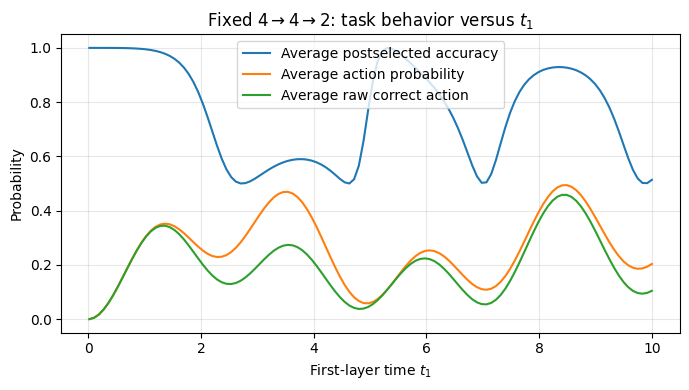

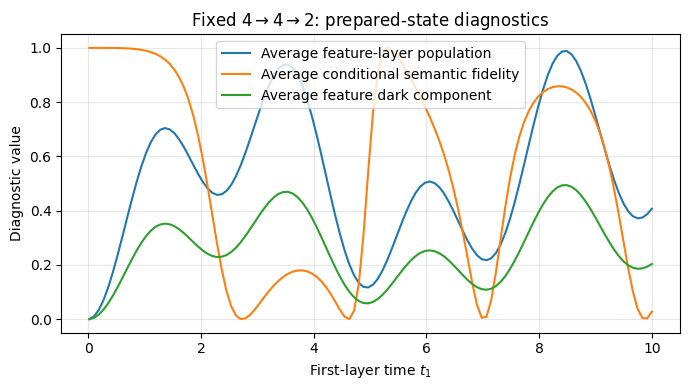

In [437]:
# ============================================================
# Fixed 4→4→2 sweep plots
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_442_sweep_summary["t1"],
    semantic_442_sweep_summary["avg_correct_post"],
    label="Average postselected accuracy",
)
plt.plot(
    semantic_442_sweep_summary["t1"],
    semantic_442_sweep_summary["avg_P_act"],
    label="Average action probability",
)
plt.plot(
    semantic_442_sweep_summary["t1"],
    semantic_442_sweep_summary["avg_raw_correct"],
    label="Average raw correct action",
)
plt.xlabel(r"First-layer time $t_1$")
plt.ylabel("Probability")
plt.title(r"Fixed $4\to4\to2$: task behavior versus $t_1$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_442_sweep_summary["t1"],
    semantic_442_sweep_summary["avg_P_feature_after_H1"],
    label="Average feature-layer population",
)
plt.plot(
    semantic_442_sweep_summary["t1"],
    semantic_442_sweep_summary["avg_target_fidelity_cond"],
    label="Average conditional semantic fidelity",
)
plt.plot(
    semantic_442_sweep_summary["t1"],
    semantic_442_sweep_summary["avg_P_dark_feature_after_H1"],
    label="Average feature dark component",
)
plt.xlabel(r"First-layer time $t_1$")
plt.ylabel("Diagnostic value")
plt.title(r"Fixed $4\to4\to2$: prepared-state diagnostics")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [438]:
# Choose by visual inspection of the sweep.
# This keeps the fixed 4→4→2 section diagnostic rather than task-trained.
t1_default = 1

semantic_442_selected_rows = []

for obj in OBJECT_ORDER:
    prep_row = semantic_442_preparation_diagnostic(obj, t1_default)

    task_row = run_full_graph_no_ancillas(
        object_label=obj,
        t1=t1_default,
    )

    semantic_442_selected_rows.append({
        **prep_row,
        "P_no": task_row["P_no"],
        "P_yes": task_row["P_yes"],
        "P_act": task_row["P_act"],
        "P_no_post": task_row["P_no_post"],
        "P_yes_post": task_row["P_yes_post"],
        "correct_post": task_row["correct_post"],
    })

semantic_442_selected_df = pd.DataFrame(semantic_442_selected_rows)

display(
    semantic_442_selected_df[
        [
            "object",
            "P_feature_after_H1",
            "target_fidelity_cond",
            "P_no_bright_after_H1",
            "P_yes_bright_after_H1",
            "P_dark_feature_after_H1",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
        ]
    ]
)

,object,P_feature_after_H1,target_fidelity_cond,P_no_bright_after_H1,P_yes_bright_after_H1,P_dark_feature_after_H1,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post
0,RS,0.598591,0.990518,0.296458,0.002838,0.299295,2.964575e-01,0.002838,0.299295,9.905178e-01,0.009482,0.990518
1,RC,0.598591,0.990518,0.241284,0.000000,0.357307,2.412837e-01,0.000000,0.241284,1.000000e+00,0.000000,1.000000
2,BS,0.598591,0.990518,0.000000,0.357307,0.241284,4.814825e-35,0.357307,0.357307,1.347530e-34,1.000000,1.000000
3,BC,0.598591,0.990518,0.296458,0.002838,0.299295,2.964575e-01,0.002838,0.299295,9.905178e-01,0.009482,0.990518


In [439]:

full_test_rows = [
    run_full_graph_no_ancillas(obj, t1=t1_default)
    for obj in OBJECT_ORDER
]

full_test_df = pd.DataFrame(full_test_rows)

display(
    full_test_df[
        [
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
        ]
    ]
)

,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post
0,RS,2.964575e-01,0.002838,0.299295,9.905178e-01,0.009482,0.990518
1,RC,2.412837e-01,0.000000,0.241284,1.000000e+00,0.000000,1.000000
2,BS,4.814825e-35,0.357307,0.357307,1.347530e-34,1.000000,1.000000
3,BC,2.964575e-01,0.002838,0.299295,9.905178e-01,0.009482,0.990518


### Full graph with middle-layer ancillas

Finally, we insert the middle-layer ancillas after the first semantic layer and before the output readout. The sequence is

$$
\text{input}
\rightarrow
\text{semantic feature layer}
\rightarrow
\text{middle-layer ancilla interaction}
\rightarrow
\text{postselected action readout}.
$$

This is the setting we want for the explainability-performance tradeoff. The ancillas gather information about which feature modes are occupied. If the task relies on coherent interference between middle-layer features, then increasing the detector strength should reduce the coherence available to the final readout and degrade the postselected task behavior.

In [440]:
# ============================================================
# Full 4-4-2 graph with middle-layer ancillas
# ============================================================

H1_full = kron(
    H1,
    identity(dim_feature_ancillas, format="csr", dtype=complex),
    format="csr",
)

# H2_full already defined above.


def run_full_graph_ancilla_point(object_label, theta, t1=t1_default, compute_wp=True):
    """
    Full graph with middle-layer ancillas:

        input -> H1 -> WWD on middle layer -> H2 -> action readout.
    """
    psi_ph0 = single_photon_ket(hs_442, INPUT_MODES[object_label])
    psi_full0 = np.kron(psi_ph0, psi_anc_plus_4)

    # Semantic layer
    psi_after_layer1 = expm_multiply(
        (-1j * t1) * H1_full,
        psi_full0,
    )

    # Middle-layer monitoring
    psi_after_int = expm_multiply(
        (-1j * theta) * H_mid_int_base,
        psi_after_layer1,
    )

    diag = None
    if compute_wp:
        diag = wp_layer_diagnostic(
            psi_full=psi_after_int,
            hs=hs_442,
            dim_ancilla=dim_feature_ancillas,
            layer_modes=tuple(monitored_feature_modes),
        )

    # Action readout
    psi_after_layer2 = expm_multiply(
        (-1j * t2) * H2_full,
        psi_after_int,
    )

    probs = action_probabilities_full_state(
        psi_after_layer2,
        hs=hs_442,
        dim_ancilla=dim_feature_ancillas,
    )

    probs["object"] = object_label
    probs["theta"] = theta
    probs["t1"] = t1
    probs["correct_post"] = correct_postselected_probability(object_label, probs)

    if diag is not None:
        probs["C_mid"] = float(diag["C"])
        probs["D_A_mid"] = float(diag["D_A"])
        probs["C_plus_D_A"] = float(diag["C"] + diag["D_A"])
        probs["slack"] = float(1.0 - (diag["C"] + diag["D_A"]))

    return probs


theta_values = np.linspace(0, np.pi / 2, 21)

full_ancilla_rows = []

for theta in theta_values:
    for obj in OBJECT_ORDER:
        full_ancilla_rows.append(
            run_full_graph_ancilla_point(
                object_label=obj,
                theta=theta,
                t1=t1_default,
                compute_wp=True,
            )
        )

full_ancilla_df = pd.DataFrame(full_ancilla_rows)

display(
    full_ancilla_df[
        [
            "theta",
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
            "C_mid",
            "D_A_mid",
            "C_plus_D_A",
        ]
    ].head(12)
)

,theta,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post,C_mid,D_A_mid,C_plus_D_A
0,0.00000,RS,2.964575e-01,0.002838,0.299295,9.905178e-01,0.009482,0.990518,0.207660,0.413624,0.621283
1,0.00000,RC,2.412837e-01,0.000000,0.241284,1.000000e+00,0.000000,1.000000,0.207660,0.413624,0.621283
2,0.00000,BS,4.333342e-34,0.357307,0.357307,1.212777e-33,1.000000,1.000000,0.207660,0.413624,0.621283
3,0.00000,BC,2.964575e-01,0.002838,0.299295,9.905178e-01,0.009482,0.990518,0.207660,0.413624,0.621283
4,0.07854,RS,2.955538e-01,0.003742,0.299295,9.874982e-01,0.012502,0.987498,0.206381,0.416069,0.622451
5,0.07854,RC,2.407196e-01,0.000921,0.241641,9.961877e-01,0.003812,0.996188,0.206381,0.416069,0.622451
6,0.07854,BS,9.212061e-04,0.356029,0.356950,2.580769e-03,0.997419,0.997419,0.206381,0.416069,0.622451
7,0.07854,BC,2.955538e-01,0.003742,0.299295,9.874982e-01,0.012502,0.987498,0.206381,0.416069,0.622451
8,0.15708,RS,2.928648e-01,0.006431,0.299295,9.785139e-01,0.021486,0.978514,0.202578,0.423368,0.625946
9,0.15708,RC,2.390412e-01,0.003662,0.242703,9.849110e-01,0.015089,0.984911,0.202578,0.423368,0.625946


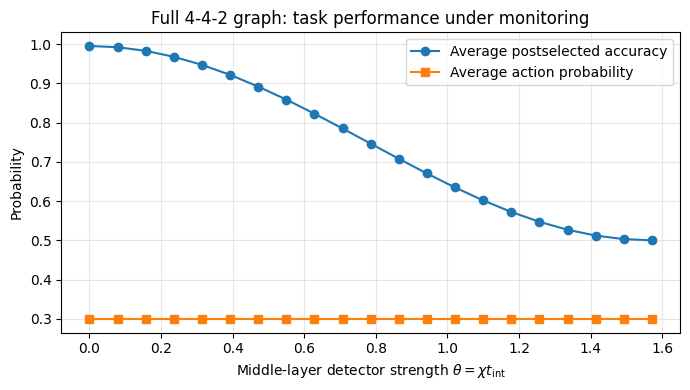

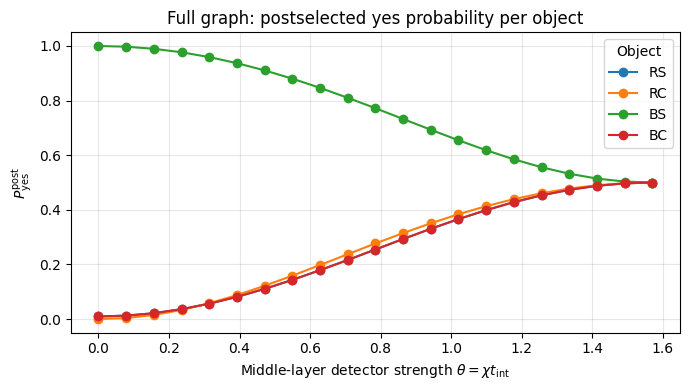

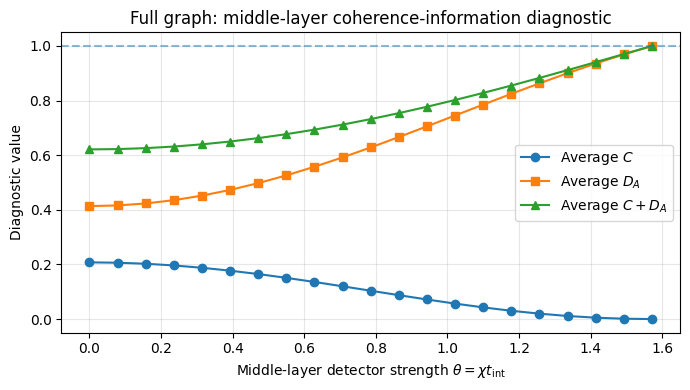

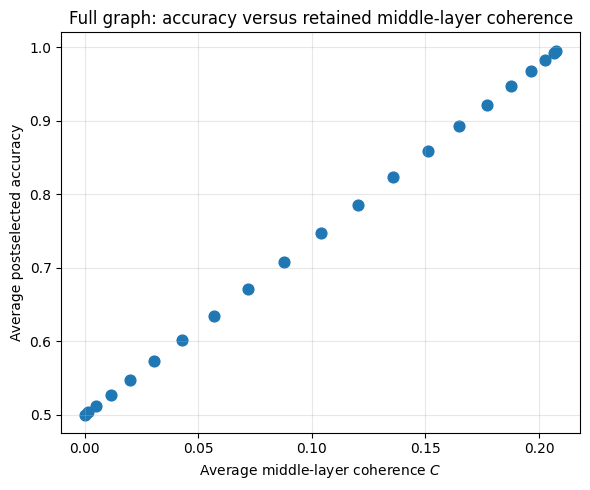

In [441]:
# ============================================================
# Full graph plots
# ============================================================

summary_full = (
    full_ancilla_df
    .groupby("theta")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_C_mid=("C_mid", "mean"),
        avg_D_A_mid=("D_A_mid", "mean"),
        avg_C_plus_D_A=("C_plus_D_A", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.plot(summary_full["theta"], summary_full["avg_correct_post"], marker="o", label="Average postselected accuracy")
plt.plot(summary_full["theta"], summary_full["avg_P_act"], marker="s", label="Average action probability")
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Probability")
plt.title("Full 4-4-2 graph: task performance under monitoring")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))

for obj in OBJECT_ORDER:
    sub = full_ancilla_df[full_ancilla_df["object"] == obj]
    plt.plot(sub["theta"], sub["P_yes_post"], marker="o", label=obj)

plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel(r"$P_{\rm yes}^{\rm post}$")
plt.title("Full graph: postselected yes probability per object")
plt.grid(True, alpha=0.3)
plt.legend(title="Object")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(summary_full["theta"], summary_full["avg_C_mid"], marker="o", label=r"Average $C$")
plt.plot(summary_full["theta"], summary_full["avg_D_A_mid"], marker="s", label=r"Average $D_A$")
plt.plot(summary_full["theta"], summary_full["avg_C_plus_D_A"], marker="^", label=r"Average $C+D_A$")
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Diagnostic value")
plt.title("Full graph: middle-layer coherence-information diagnostic")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
plt.scatter(summary_full["avg_C_mid"], summary_full["avg_correct_post"], s=60)
plt.xlabel(r"Average middle-layer coherence $C$")
plt.ylabel("Average postselected accuracy")
plt.title("Full graph: accuracy versus retained middle-layer coherence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PRA-style 1→4→2 construction

The fixed $4\to4\to2$ model is useful as a diagnostic, but it is not the faithful analogue of the PRA-style construction.

In the PRA-style setting, the percept is not represented by placing the photon in one of four input modes and applying one common first-stage unitary. Instead, we use one fixed input mode and allow the percept label to select the first-stage Hamiltonian.

The active optical architecture is therefore

$$
1\to4\to2.
$$

The modes are

$$
1 = \mathrm{input},
$$

$$
(2,3,4,5) = (R,B,S,C),
$$

$$
(6,7) = (\mathrm{no},\mathrm{yes}).
$$

For each percept $x\in\{RS,RC,BS,BC\}$, we choose a different first-stage Hamiltonian $H_1^{(x)}$ that prepares the desired middle-layer feature state:

$$
|\mathrm{input}\rangle
\rightarrow
|\phi_x\rangle_F.
$$

The second-stage Hamiltonian $H_2$ is common to all percepts. This means that the decision layer is fixed, while only the semantic preparation stage is percept-dependent.

In [442]:
# ============================================================
# PRA-style 1→4→2 setup
# ============================================================

hs_142 = FixedNBosons(m=7, N=1)

semantic_142_INPUT_MODE = 1

semantic_142_FEATURE_MODES = {
    "R": 2,
    "B": 3,
    "S": 4,
    "C": 5,
}

semantic_142_OUTPUT_MODES = {
    "no": 6,
    "yes": 7,
}

semantic_142_FEATURE_ORDER = ["R", "B", "S", "C"]
semantic_142_OBJECT_ORDER = OBJECT_ORDER

semantic_142_feature_modes_ordered = [
    semantic_142_FEATURE_MODES[f]
    for f in semantic_142_FEATURE_ORDER
]

semantic_142_output_modes_ordered = [
    semantic_142_OUTPUT_MODES["no"],
    semantic_142_OUTPUT_MODES["yes"],
]

In [443]:
# ============================================================
# PRA-style 1→4→2: common decision Hamiltonian H2
# ============================================================

semantic_142_g2 = 1.0

semantic_142_K2 = semantic_142_g2 * np.vstack([
    w_no.conj(),
    w_yes.conj(),
])

print("1→4→2 K2 K2†:")
print(np.round(semantic_142_K2 @ semantic_142_K2.conj().T, 6))

print("\n1→4→2 K2 singular values:")
print(np.round(np.linalg.svd(semantic_142_K2, compute_uv=False), 6))

semantic_142_edges2 = edges_from_K(
    K=semantic_142_K2,
    src_modes=semantic_142_feature_modes_ordered,
    dst_modes=semantic_142_output_modes_ordered,
)

semantic_142_H2 = build_H_edges(
    hs_142,
    semantic_142_edges2,
)

semantic_142_t2 = np.pi / (2 * semantic_142_g2)

1→4→2 K2 K2†:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

1→4→2 K2 singular values:
[1. 1.]


In [444]:
# ============================================================
# PRA-style 1→4→2: percept-specific semantic preparation
# ============================================================

semantic_142_g1 = 1.0

semantic_142_H1_by_object = {}
semantic_142_K1_by_object = {}
semantic_142_t1_by_object = {}

for obj in semantic_142_OBJECT_ORDER:
    semantic_142_K1_obj = (
        semantic_142_g1
        * feature_vectors[obj].reshape(-1, 1)
    )

    semantic_142_edges1_obj = edges_from_K(
        K=semantic_142_K1_obj,
        src_modes=[semantic_142_INPUT_MODE],
        dst_modes=semantic_142_feature_modes_ordered,
    )

    semantic_142_H1_by_object[obj] = build_H_edges(
        hs_142,
        semantic_142_edges1_obj,
    )

    semantic_142_K1_by_object[obj] = semantic_142_K1_obj

    # One normalized bright channel, so the transfer time is exact.
    semantic_142_t1_by_object[obj] = np.pi / (2 * semantic_142_g1)

print("1→4 semantic-preparation times:")
for obj in semantic_142_OBJECT_ORDER:
    print(obj, semantic_142_t1_by_object[obj])

1→4 semantic-preparation times:
RS 1.5707963267948966
RC 1.5707963267948966
BS 1.5707963267948966
BC 1.5707963267948966


In [445]:
# ============================================================
# PRA-style 1→4→2: check prepared middle states
# ============================================================

semantic_142_prep_rows = []

for obj in semantic_142_OBJECT_ORDER:
    semantic_142_psi_in = single_photon_ket(
        hs_142,
        semantic_142_INPUT_MODE,
    )

    semantic_142_psi_mid = evolve(
        semantic_142_H1_by_object[obj],
        semantic_142_psi_in,
        semantic_142_t1_by_object[obj],
    )

    semantic_142_feature_amps = np.array([
        np.vdot(
            single_photon_ket(hs_142, semantic_142_FEATURE_MODES[f]),
            semantic_142_psi_mid,
        )
        for f in semantic_142_FEATURE_ORDER
    ])

    semantic_142_P_feature = float(
        np.sum(np.abs(semantic_142_feature_amps) ** 2)
    )

    # The hopping gives a global -i phase on the transferred component.
    semantic_142_target = -1j * feature_vectors[obj]

    semantic_142_fidelity = float(
        abs(np.vdot(semantic_142_target, semantic_142_feature_amps)) ** 2
        / semantic_142_P_feature
    )

    semantic_142_prep_rows.append({
        "object": obj,
        "P_feature": semantic_142_P_feature,
        "conditional_fidelity_to_target": semantic_142_fidelity,
    })

semantic_142_prep_df = pd.DataFrame(semantic_142_prep_rows)

display(semantic_142_prep_df)

,object,P_feature,conditional_fidelity_to_target
0,RS,1.0,1.0
1,RC,1.0,1.0
2,BS,1.0,1.0
3,BC,1.0,1.0


In [446]:
# ============================================================
# PRA-style 1→4→2: classifier without ancillas
# ============================================================

semantic_142_rows = []

for obj in semantic_142_OBJECT_ORDER:
    semantic_142_psi_in = single_photon_ket(
        hs_142,
        semantic_142_INPUT_MODE,
    )

    semantic_142_psi_mid = evolve(
        semantic_142_H1_by_object[obj],
        semantic_142_psi_in,
        semantic_142_t1_by_object[obj],
    )

    semantic_142_psi_out = evolve(
        semantic_142_H2,
        semantic_142_psi_mid,
        semantic_142_t2,
    )

    semantic_142_P_no = photon_number_expectation(
        semantic_142_psi_out,
        hs_142,
        semantic_142_OUTPUT_MODES["no"],
    )

    semantic_142_P_yes = photon_number_expectation(
        semantic_142_psi_out,
        hs_142,
        semantic_142_OUTPUT_MODES["yes"],
    )

    semantic_142_probs = postselected_action_probabilities(
        semantic_142_P_no,
        semantic_142_P_yes,
    )

    semantic_142_probs["object"] = obj
    semantic_142_probs["correct_post"] = correct_postselected_probability(
        obj,
        semantic_142_probs,
    )

    semantic_142_rows.append(semantic_142_probs)

semantic_142_df = pd.DataFrame(semantic_142_rows)

display(
    semantic_142_df[
        [
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
        ]
    ]
)

,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post
0,RS,0.5,0.0,0.5,1.0,0.0,1.0
1,RC,0.5,0.0,0.5,1.0,0.0,1.0
2,BS,0.0,0.5,0.5,0.0,1.0,1.0
3,BC,0.5,0.0,0.5,1.0,0.0,1.0


### Ancilla-monitored 1→4→2 PRA-style construction

We now add one ancilla qubit for each middle feature mode:

$$
(R,B,S,C).
$$

The circuit sequence is

$$
\mathrm{input}
\rightarrow
H_1^{(x)}
\rightarrow
\mathrm{middle\ feature\ state}
\rightarrow
U_{\mathrm{int}}(\theta)
\rightarrow
H_2
\rightarrow
\mathrm{no/yes}.
$$

For each percept $x\in\{RS,RC,BS,BC\}$, the first-stage Hamiltonian $H_1^{(x)}$ prepares the corresponding semantic feature state. The second-stage Hamiltonian $H_2$ is common to all percepts.

The ancilla interaction is

$$
U_{\mathrm{int}}(\theta)
=
\exp\left[
-i\theta
\sum_{m\in\{R,B,S,C\}}
n_m\otimes Z_m
\right],
$$

where

$$
\theta = \chi t_{\mathrm{int}}.
$$

This interaction does not move population between modes. It only correlates feature-mode occupation with ancilla states. Therefore it should reduce middle-layer coherence and increase which-feature information.

For this ideal $1\to4\to2$ case, we expect the middle-layer relation

$$
C+D_A\leq 1
$$

to be close to saturated for all $\theta$, because the middle state is prepared cleanly and the only source of coherence loss is the monitored ancilla system.

In [447]:
# ============================================================
# 1→4→2: middle-layer ancillas
# ============================================================

semantic_142_monitored_feature_modes = semantic_142_feature_modes_ordered
semantic_142_num_feature_ancillas = len(semantic_142_monitored_feature_modes)
semantic_142_dim_feature_ancillas = 2 ** semantic_142_num_feature_ancillas

# |+>^{⊗4} ancilla state, written inline to avoid defining another helper.
semantic_142_plus_one = np.array(
    [1 / np.sqrt(2), 1 / np.sqrt(2)],
    dtype=complex,
)

semantic_142_psi_anc_plus = semantic_142_plus_one.copy()

for _ in range(semantic_142_num_feature_ancillas - 1):
    semantic_142_psi_anc_plus = np.kron(
        semantic_142_psi_anc_plus,
        semantic_142_plus_one,
    )

# Build theta-free dispersive Hamiltonian:
#
#     H_int_base = sum_q n_{feature_q} ⊗ Z_q
#
# The actual interaction is exp[-i theta H_int_base].

semantic_142_H_mid_int_base = csr_matrix(
    (
        hs_142.dim * semantic_142_dim_feature_ancillas,
        hs_142.dim * semantic_142_dim_feature_ancillas,
    ),
    dtype=complex,
)

for q, mode in enumerate(semantic_142_monitored_feature_modes):
    semantic_142_n_mode = hs_142.hop(mode, mode)
    semantic_142_Z_q = op_on_qubit(
        semantic_142_num_feature_ancillas,
        q,
        sigma_z,
    )

    semantic_142_H_mid_int_base += kron(
        semantic_142_n_mode,
        semantic_142_Z_q,
        format="csr",
    )

semantic_142_I_anc = identity(
    semantic_142_dim_feature_ancillas,
    format="csr",
    dtype=complex,
)

semantic_142_H2_full = kron(
    semantic_142_H2,
    semantic_142_I_anc,
    format="csr",
)

semantic_142_H1_full_by_object = {}

for obj in semantic_142_OBJECT_ORDER:
    semantic_142_H1_full_by_object[obj] = kron(
        semantic_142_H1_by_object[obj],
        semantic_142_I_anc,
        format="csr",
    )

# Full-space no/yes number operators.
semantic_142_N_no_full = kron(
    hs_142.hop(semantic_142_OUTPUT_MODES["no"], semantic_142_OUTPUT_MODES["no"]),
    semantic_142_I_anc,
    format="csr",
)

semantic_142_N_yes_full = kron(
    hs_142.hop(semantic_142_OUTPUT_MODES["yes"], semantic_142_OUTPUT_MODES["yes"]),
    semantic_142_I_anc,
    format="csr",
)

In [448]:
# ============================================================
# 1→4→2: one ancilla-monitored run
# ============================================================

def semantic_142_run_ancilla_point(object_label, theta, compute_wp=True):
    # Fixed input mode.
    semantic_142_psi_ph_in = single_photon_ket(
        hs_142,
        semantic_142_INPUT_MODE,
    )

    semantic_142_psi_full = np.kron(
        semantic_142_psi_ph_in,
        semantic_142_psi_anc_plus,
    )

    # Percept-specific semantic preparation.
    semantic_142_psi_after_H1 = expm_multiply(
        (-1j * semantic_142_t1_by_object[object_label])
        * semantic_142_H1_full_by_object[object_label],
        semantic_142_psi_full,
    )

    # Middle-layer which-feature monitoring.
    semantic_142_psi_after_int = expm_multiply(
        (-1j * theta) * semantic_142_H_mid_int_base,
        semantic_142_psi_after_H1,
    )

    semantic_142_diag = None
    semantic_142_decomp = None

    if compute_wp:
        semantic_142_diag = wp_layer_diagnostic(
            psi_full=semantic_142_psi_after_int,
            hs=hs_142,
            dim_ancilla=semantic_142_dim_feature_ancillas,
            layer_modes=tuple(semantic_142_monitored_feature_modes),
        )

        semantic_142_decomp = decompose_duality_details(
            rho=semantic_142_diag["rho_layer"],
            ancilla_states=semantic_142_diag["conditioned_ancilla_states"],
            probs=semantic_142_diag["probabilities"],
            configs=semantic_142_diag["configs"],
        )

    # Common decision layer.
    semantic_142_psi_after_H2 = expm_multiply(
        (-1j * semantic_142_t2) * semantic_142_H2_full,
        semantic_142_psi_after_int,
    )

    semantic_142_P_no = float(
        np.real(
            expectation_full_state(
                semantic_142_psi_after_H2,
                semantic_142_N_no_full,
            )
        )
    )

    semantic_142_P_yes = float(
        np.real(
            expectation_full_state(
                semantic_142_psi_after_H2,
                semantic_142_N_yes_full,
            )
        )
    )

    semantic_142_probs = postselected_action_probabilities(
        semantic_142_P_no,
        semantic_142_P_yes,
    )

    semantic_142_probs["object"] = object_label
    semantic_142_probs["theta"] = float(theta)
    semantic_142_probs["correct_post"] = correct_postselected_probability(
        object_label,
        semantic_142_probs,
    )

    if object_label == "BS":
        semantic_142_probs["raw_correct"] = semantic_142_probs["P_yes"]
        semantic_142_probs["raw_wrong"] = semantic_142_probs["P_no"]
    else:
        semantic_142_probs["raw_correct"] = semantic_142_probs["P_no"]
        semantic_142_probs["raw_wrong"] = semantic_142_probs["P_yes"]

    if semantic_142_diag is not None:
        semantic_142_probs["C_mid"] = float(semantic_142_diag["C"])
        semantic_142_probs["D_A_mid"] = float(semantic_142_diag["D_A"])
        semantic_142_probs["C_plus_D_A"] = float(
            semantic_142_diag["C_plus_D"]
        )
        semantic_142_probs["slack_mid"] = float(
            semantic_142_diag["slack"]
        )
        semantic_142_probs["R_active_mid"] = int(
            semantic_142_diag["number_configs_active"]
        )

    if semantic_142_decomp is not None:
        semantic_142_summary = semantic_142_decomp["summary"]

        semantic_142_probs["D_prior_mid"] = float(
            semantic_142_summary.get(
                "D_prior_population_imbalance",
                np.nan,
            )
        )

        semantic_142_probs["D_detector_mid"] = float(
            semantic_142_summary.get(
                "D_detector_from_fidelity_loss",
                np.nan,
            )
        )

        semantic_142_probs["Cmax_allowed_mid"] = float(
            semantic_142_summary.get(
                "Cmax_allowed_by_ancillas",
                np.nan,
            )
        )

    return semantic_142_probs

In [449]:
# ============================================================
# 1→4→2: theta sweep
# ============================================================

semantic_142_theta_values = np.linspace(0, np.pi / 2, 31)

semantic_142_ancilla_rows = []

for theta in semantic_142_theta_values:
    for obj in semantic_142_OBJECT_ORDER:
        semantic_142_ancilla_rows.append(
            semantic_142_run_ancilla_point(
                object_label=obj,
                theta=theta,
                compute_wp=True,
            )
        )

semantic_142_ancilla_df = pd.DataFrame(semantic_142_ancilla_rows)

display(
    semantic_142_ancilla_df[
        [
            "theta",
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
            "raw_correct",
            "raw_wrong",
            "C_mid",
            "D_A_mid",
            "C_plus_D_A",
            "D_prior_mid",
            "D_detector_mid",
            "slack_mid",
        ]
    ].head(12)
)

,theta,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post,raw_correct,raw_wrong,C_mid,D_A_mid,C_plus_D_A,D_prior_mid,D_detector_mid,slack_mid
0,0.00000,RS,0.500000,0.000000,0.5,1.000000,0.000000,1.000000,0.500000,0.000000,1.000000,4.440892e-16,1.0,0.0,0.000000,-4.440892e-16
1,0.00000,RC,0.500000,0.000000,0.5,1.000000,0.000000,1.000000,0.500000,0.000000,1.000000,4.440892e-16,1.0,0.0,0.000000,-4.440892e-16
2,0.00000,BS,0.000000,0.500000,0.5,0.000000,1.000000,1.000000,0.500000,0.000000,1.000000,4.440892e-16,1.0,0.0,0.000000,-4.440892e-16
3,0.00000,BC,0.500000,0.000000,0.5,1.000000,0.000000,1.000000,0.500000,0.000000,1.000000,4.440892e-16,1.0,0.0,0.000000,-4.440892e-16
4,0.05236,RS,0.499315,0.000685,0.5,0.998630,0.001370,0.998630,0.499315,0.000685,0.997261,2.739021e-03,1.0,0.0,0.002739,3.115765e-08
5,0.05236,RC,0.499315,0.000685,0.5,0.998630,0.001370,0.998630,0.499315,0.000685,0.997261,2.739021e-03,1.0,0.0,0.002739,3.091373e-08
6,0.05236,BS,0.000685,0.499315,0.5,0.001370,0.998630,0.998630,0.499315,0.000685,0.997261,2.739018e-03,1.0,0.0,0.002739,3.443286e-08
7,0.05236,BC,0.499315,0.000685,0.5,0.998630,0.001370,0.998630,0.499315,0.000685,0.997261,2.739013e-03,1.0,0.0,0.002739,3.964008e-08
8,0.10472,RS,0.497268,0.002732,0.5,0.994537,0.005463,0.994537,0.497268,0.002732,0.989074,1.092616e-02,1.0,0.0,0.010926,3.819638e-08
9,0.10472,RC,0.497268,0.002732,0.5,0.994537,0.005463,0.994537,0.497268,0.002732,0.989074,1.092616e-02,1.0,0.0,0.010926,3.782195e-08


In [450]:
# ============================================================
# 1→4→2: theta-sweep summary
# ============================================================

semantic_142_summary = (
    semantic_142_ancilla_df
    .groupby("theta")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
        avg_raw_wrong=("raw_wrong", "mean"),
        avg_C_mid=("C_mid", "mean"),
        avg_D_A_mid=("D_A_mid", "mean"),
        avg_C_plus_D_A=("C_plus_D_A", "mean"),
        avg_D_prior_mid=("D_prior_mid", "mean"),
        avg_D_detector_mid=("D_detector_mid", "mean"),
        avg_slack_mid=("slack_mid", "mean"),
    )
    .reset_index()
)

display(semantic_142_summary.head())

,theta,avg_correct_post,avg_P_act,avg_raw_correct,avg_raw_wrong,avg_C_mid,avg_D_A_mid,avg_C_plus_D_A,avg_D_prior_mid,avg_D_detector_mid,avg_slack_mid
0,0.00000,1.000000,0.5,0.500000,0.000000,1.000000,4.440892e-16,1.0,0.0,0.000000,-4.440892e-16
1,0.05236,0.998630,0.5,0.499315,0.000685,0.997261,2.739018e-03,1.0,0.0,0.002739,3.403608e-08
2,0.10472,0.994537,0.5,0.497268,0.002732,0.989074,1.092616e-02,1.0,0.0,0.010926,3.526869e-08
3,0.15708,0.987764,0.5,0.493882,0.006118,0.975528,2.447170e-02,1.0,0.0,0.024472,4.128269e-08
4,0.20944,0.978386,0.5,0.489193,0.010807,0.956773,4.322723e-02,1.0,0.0,0.043227,3.627586e-08


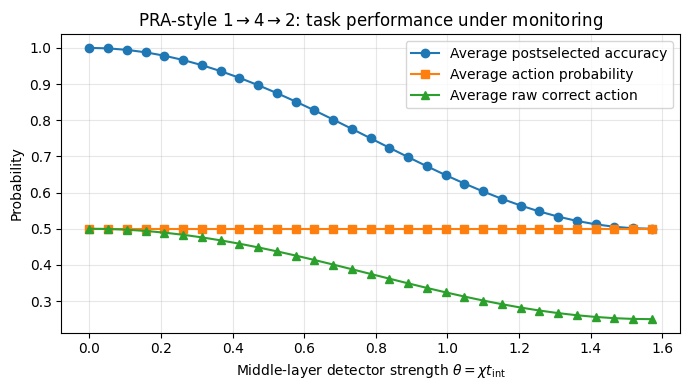

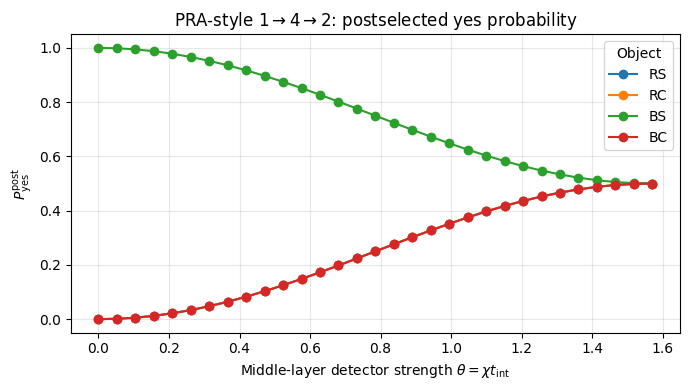

In [451]:
# ============================================================
# 1→4→2: task-performance plots
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_correct_post"],
    marker="o",
    label="Average postselected accuracy",
)
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_P_act"],
    marker="s",
    label="Average action probability",
)
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_raw_correct"],
    marker="^",
    label="Average raw correct action",
)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Probability")
plt.title(r"PRA-style $1\to4\to2$: task performance under monitoring")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))

for obj in semantic_142_OBJECT_ORDER:
    semantic_142_sub = semantic_142_ancilla_df[
        semantic_142_ancilla_df["object"] == obj
    ]

    plt.plot(
        semantic_142_sub["theta"],
        semantic_142_sub["P_yes_post"],
        marker="o",
        label=obj,
    )

plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel(r"$P_{\rm yes}^{\rm post}$")
plt.title(r"PRA-style $1\to4\to2$: postselected yes probability")
plt.grid(True, alpha=0.3)
plt.legend(title="Object")
plt.tight_layout()
plt.show()

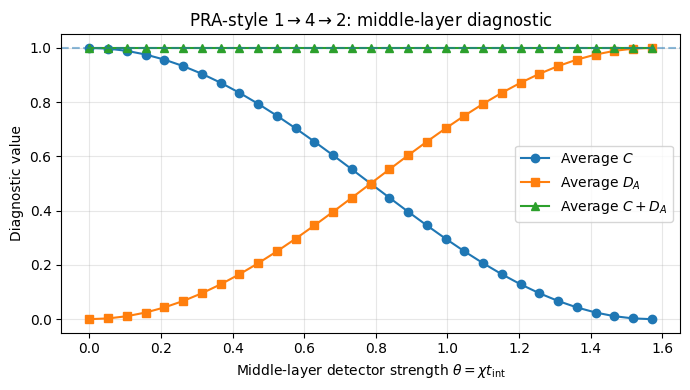

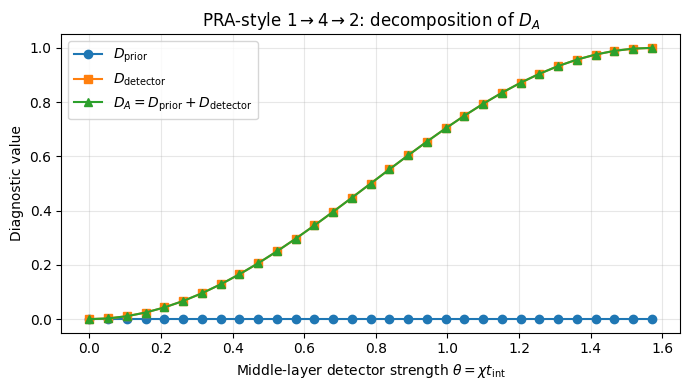

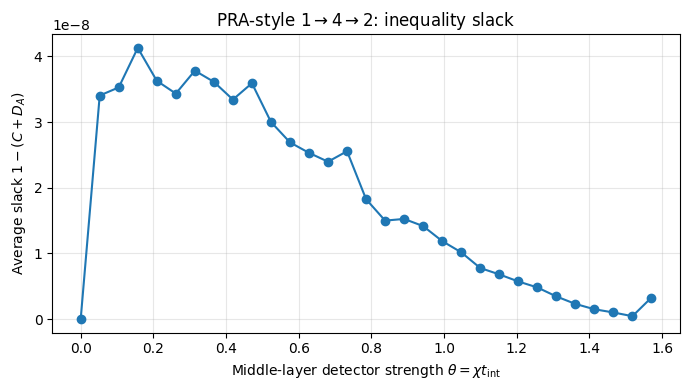

In [452]:
# ============================================================
# 1→4→2: coherence-information diagnostic plots
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_C_mid"],
    marker="o",
    label=r"Average $C$",
)
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_D_A_mid"],
    marker="s",
    label=r"Average $D_A$",
)
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_C_plus_D_A"],
    marker="^",
    label=r"Average $C+D_A$",
)
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Diagnostic value")
plt.title(r"PRA-style $1\to4\to2$: middle-layer diagnostic")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_D_prior_mid"],
    marker="o",
    label=r"$D_{\rm prior}$",
)
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_D_detector_mid"],
    marker="s",
    label=r"$D_{\rm detector}$",
)
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_D_A_mid"],
    marker="^",
    label=r"$D_A=D_{\rm prior}+D_{\rm detector}$",
)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Diagnostic value")
plt.title(r"PRA-style $1\to4\to2$: decomposition of $D_A$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_142_summary["theta"],
    semantic_142_summary["avg_slack_mid"],
    marker="o",
)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel(r"Average slack $1-(C+D_A)$")
plt.title(r"PRA-style $1\to4\to2$: inequality slack")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Larger two-photon semantic classifier: 1→6→2

We now enlarge the blue-square environment from two colors and two shapes to three colors and three shapes. The nine percepts are

$$
\{RS,RC,RT,BS,BC,BT,GS,GC,GT\},
$$

where the colors are red, blue, and green, and the shapes are square, circle, and triangle. The correct action remains yes only for $BS$.

The optical architecture is

$$
1\to6\to2,
$$

with one input mode, six semantic feature modes

$$
(R,B,G,S,C,T),
$$

and two action modes $(\mathrm{no},\mathrm{yes})$. Unlike the preceding construction, the photonic Hilbert space has fixed total photon number $N=2$.

For percept $x$, the first Hamiltonian transfers two photons from the input mode into a phase-coded semantic mode

$$
b_x^\dagger
=
\frac{a_{\mathrm{color}(x)}^\dagger
+s_x a_{\mathrm{shape}(x)}^\dagger}{\sqrt{2}},
$$

with $s_{BS}=-1$ and $s_x=+1$ otherwise. The prepared state is

$$
|\Phi_x\rangle
=
\frac{(b_x^\dagger)^2}{\sqrt{2}}|0\rangle.
$$

Each state contains three coherent occupation configurations: two photons in the color mode, one photon in each semantic mode, and two photons in the shape mode.

The common decision Hamiltonian below is pair-sensitive. A quadratic hopping Hamiltonian only probes one-particle structure and cannot isolate one conjunction among all nine color-shape pairs. The two-excitation readout instead couples engineered two-photon bright states to the no and yes output events. This is the multi-excitation ingredient that distinguishes the construction from the single-photon classifier.

In [453]:
# ============================================================
# Larger two-photon environment: modes and semantic states
# ============================================================

from scipy.sparse import csr_matrix, identity, kron
from scipy.sparse.linalg import expm_multiply

semantic_162_COLORS = ["R", "B", "G"]
semantic_162_SHAPES = ["S", "C", "T"]
semantic_162_OBJECT_ORDER = [
    color + shape
    for color in semantic_162_COLORS
    for shape in semantic_162_SHAPES
]

semantic_162_INPUT_MODE = 1

semantic_162_FEATURE_MODES = {
    "R": 2,
    "B": 3,
    "G": 4,
    "S": 5,
    "C": 6,
    "T": 7,
}

semantic_162_OUTPUT_MODES = {
    "no": 8,
    "yes": 9,
}

semantic_162_FEATURE_ORDER = ["R", "B", "G", "S", "C", "T"]
semantic_162_feature_modes_ordered = [
    semantic_162_FEATURE_MODES[name]
    for name in semantic_162_FEATURE_ORDER
]

hs_162 = FixedNBosons(m=9, N=2)


def semantic_162_fock_ket(occupations):
    return hs_162.ket(tuple(occupations))


def semantic_162_two_photons_in_mode(mode):
    occupations = [0] * hs_162.m
    occupations[mode - 1] = 2
    return semantic_162_fock_ket(occupations)


def semantic_162_single_particle_vector(object_label):
    """
    Phase-coded vector in feature order (R, B, G, S, C, T).
    """
    color, shape = object_label
    vector = np.zeros(len(semantic_162_FEATURE_ORDER), dtype=complex)

    vector[semantic_162_FEATURE_ORDER.index(color)] = 1 / np.sqrt(2)
    vector[semantic_162_FEATURE_ORDER.index(shape)] = (
        -1 if object_label == "BS" else 1
    ) / np.sqrt(2)

    return vector


def semantic_162_lift_to_two_photons(single_particle_vector):
    """
    Embed (b†)^2/sqrt(2)|0> in the full fixed-N=2 Hilbert space.
    """
    state = np.zeros(hs_162.dim, dtype=complex)

    for i, amp_i in enumerate(single_particle_vector):
        mode_i = semantic_162_feature_modes_ordered[i]

        occupations = [0] * hs_162.m
        occupations[mode_i - 1] = 2
        state += amp_i**2 * semantic_162_fock_ket(occupations)

        for j in range(i + 1, len(single_particle_vector)):
            amp_j = single_particle_vector[j]
            mode_j = semantic_162_feature_modes_ordered[j]

            occupations = [0] * hs_162.m
            occupations[mode_i - 1] = 1
            occupations[mode_j - 1] = 1

            state += (
                np.sqrt(2)
                * amp_i
                * amp_j
                * semantic_162_fock_ket(occupations)
            )

    return state / np.linalg.norm(state)


semantic_162_single_particle_vectors = {
    obj: semantic_162_single_particle_vector(obj)
    for obj in semantic_162_OBJECT_ORDER
}

semantic_162_target_states = {
    obj: semantic_162_lift_to_two_photons(
        semantic_162_single_particle_vectors[obj]
    )
    for obj in semantic_162_OBJECT_ORDER
}

print("Two-photon Hilbert-space dimension:", hs_162.dim)
print("Objects:", semantic_162_OBJECT_ORDER)


Two-photon Hilbert-space dimension: 45
Objects: ['RS', 'RC', 'RT', 'BS', 'BC', 'BT', 'GS', 'GC', 'GT']


### Pair-sensitive postselected readout

The nine semantic states are linearly independent in the two-photon sector. We construct the yes bright state by projecting $|\Phi_{BS}\rangle$ onto the orthogonal complement of the eight negative examples. Thus

$$
\langle w_{\mathrm{yes}}|\Phi_x\rangle=0
\quad
\text{for }x\neq BS.
$$

The no bright state is orthogonal to both $|\Phi_{BS}\rangle$ and $|w_{\mathrm{yes}}\rangle$, while retaining nonzero overlap with every negative example. The readout Hamiltonian couples these orthogonal bright states to the two-photon output events

$$
|2_{\mathrm{no}}\rangle
\quad\text{and}\quad
|2_{\mathrm{yes}}\rangle.
$$

As before, the classifier is postselected on action events:

$$
P_{\mathrm{act}}=P(2_{\mathrm{no}})+P(2_{\mathrm{yes}}).
$$

This event probability, rather than the mean output occupation, keeps $P_{\mathrm{act}}$ between zero and one for two photons.

In [454]:
# ============================================================
# Two-photon bright states and common decision Hamiltonian
# ============================================================

semantic_162_target = semantic_162_target_states["BS"]

semantic_162_negative_matrix = np.column_stack([
    semantic_162_target_states[obj]
    for obj in semantic_162_OBJECT_ORDER
    if obj != "BS"
])

semantic_162_U_neg, semantic_162_s_neg, _ = np.linalg.svd(
    semantic_162_negative_matrix,
    full_matrices=False,
)
semantic_162_rank_neg = int(np.sum(semantic_162_s_neg > 1e-12))
semantic_162_Q_neg = semantic_162_U_neg[:, :semantic_162_rank_neg]

semantic_162_w_yes = (
    semantic_162_target
    - semantic_162_Q_neg
    @ (semantic_162_Q_neg.conj().T @ semantic_162_target)
)
semantic_162_w_yes /= np.linalg.norm(semantic_162_w_yes)

semantic_162_no_candidate = np.sum(
    semantic_162_negative_matrix,
    axis=1,
)

semantic_162_constraints = np.column_stack([
    semantic_162_target,
    semantic_162_w_yes,
])
semantic_162_Q_constraints, _ = np.linalg.qr(
    semantic_162_constraints,
)

semantic_162_w_no = (
    semantic_162_no_candidate
    - semantic_162_Q_constraints
    @ (
        semantic_162_Q_constraints.conj().T
        @ semantic_162_no_candidate
    )
)
semantic_162_w_no /= np.linalg.norm(semantic_162_w_no)

semantic_162_out_no = semantic_162_two_photons_in_mode(
    semantic_162_OUTPUT_MODES["no"]
)
semantic_162_out_yes = semantic_162_two_photons_in_mode(
    semantic_162_OUTPUT_MODES["yes"]
)

semantic_162_g2 = 1.0

semantic_162_H2_dense = semantic_162_g2 * (
    np.outer(semantic_162_out_no, semantic_162_w_no.conj())
    + np.outer(semantic_162_w_no, semantic_162_out_no.conj())
    + np.outer(semantic_162_out_yes, semantic_162_w_yes.conj())
    + np.outer(semantic_162_w_yes, semantic_162_out_yes.conj())
)

semantic_162_H2 = csr_matrix(semantic_162_H2_dense)
semantic_162_t2 = np.pi / (2 * semantic_162_g2)

semantic_162_readout_rows = []

for obj in semantic_162_OBJECT_ORDER:
    state = semantic_162_target_states[obj]

    semantic_162_readout_rows.append({
        "object": obj,
        "overlap_no": float(abs(np.vdot(semantic_162_w_no, state)) ** 2),
        "overlap_yes": float(abs(np.vdot(semantic_162_w_yes, state)) ** 2),
    })

semantic_162_readout_df = pd.DataFrame(semantic_162_readout_rows)

print(
    "Bright-state overlap:",
    np.vdot(semantic_162_w_no, semantic_162_w_yes),
)
display(semantic_162_readout_df)


Bright-state overlap: (2.0816681711721685e-17+0j)


,object,overlap_no,overlap_yes
0,RS,4.166667e-02,3.641211e-32
1,RC,3.750000e-01,2.773339e-32
2,RT,3.750000e-01,4.814825e-33
3,BS,3.965248e-34,7.692308e-01
4,BC,4.166667e-02,4.930381e-32
5,BT,4.166667e-02,1.738152e-32
6,GS,4.166667e-02,3.081488e-33
7,GC,3.750000e-01,1.733337e-33
8,GT,3.750000e-01,1.733337e-33


In [455]:
# ============================================================
# Exact percept-specific two-photon semantic preparation
# ============================================================

semantic_162_g1 = 1.0
semantic_162_t1 = np.pi / (2 * semantic_162_g1)
semantic_162_H1_by_object = {}

for obj in semantic_162_OBJECT_ORDER:
    semantic_162_vector = semantic_162_single_particle_vectors[obj]

    semantic_162_edges1 = edges_from_K(
        K=(
            semantic_162_g1
            * semantic_162_vector.reshape(-1, 1)
        ),
        src_modes=[semantic_162_INPUT_MODE],
        dst_modes=semantic_162_feature_modes_ordered,
    )

    semantic_162_H1_by_object[obj] = build_H_edges(
        hs_162,
        semantic_162_edges1,
    )

semantic_162_psi_input = semantic_162_two_photons_in_mode(
    semantic_162_INPUT_MODE
)

semantic_162_prep_rows = []

for obj in semantic_162_OBJECT_ORDER:
    semantic_162_psi_mid = evolve(
        semantic_162_H1_by_object[obj],
        semantic_162_psi_input,
        semantic_162_t1,
    )

    # Two transferred photons acquire the global phase (-i)^2 = -1.
    semantic_162_target_with_phase = (
        -semantic_162_target_states[obj]
    )

    semantic_162_prep_rows.append({
        "object": obj,
        "feature_population": float(
            sum(
                photon_number_expectation(
                    semantic_162_psi_mid,
                    hs_162,
                    mode,
                )
                for mode in semantic_162_feature_modes_ordered
            )
            / 2
        ),
        "fidelity_to_target": float(
            abs(
                np.vdot(
                    semantic_162_target_with_phase,
                    semantic_162_psi_mid,
                )
            ) ** 2
        ),
    })

semantic_162_prep_df = pd.DataFrame(semantic_162_prep_rows)
display(semantic_162_prep_df)


,object,feature_population,fidelity_to_target
0,RS,1.0,1.0
1,RC,1.0,1.0
2,RT,1.0,1.0
3,BS,1.0,1.0
4,BC,1.0,1.0
5,BT,1.0,1.0
6,GS,1.0,1.0
7,GC,1.0,1.0
8,GT,1.0,1.0


In [456]:
# ============================================================
# Unmonitored two-photon classifier
# ============================================================

def semantic_162_action_probabilities(psi):
    P_no = float(abs(np.vdot(semantic_162_out_no, psi)) ** 2)
    P_yes = float(abs(np.vdot(semantic_162_out_yes, psi)) ** 2)
    return postselected_action_probabilities(P_no, P_yes)


def semantic_162_correct_probability(object_label, probabilities):
    if object_label == "BS":
        return probabilities["P_yes_post"]
    return probabilities["P_no_post"]


semantic_162_baseline_rows = []

for obj in semantic_162_OBJECT_ORDER:
    semantic_162_psi_mid = evolve(
        semantic_162_H1_by_object[obj],
        semantic_162_psi_input,
        semantic_162_t1,
    )

    semantic_162_psi_out = evolve(
        semantic_162_H2,
        semantic_162_psi_mid,
        semantic_162_t2,
    )

    semantic_162_probs = semantic_162_action_probabilities(
        semantic_162_psi_out
    )
    semantic_162_probs["object"] = obj
    semantic_162_probs["correct_post"] = (
        semantic_162_correct_probability(
            obj,
            semantic_162_probs,
        )
    )

    semantic_162_baseline_rows.append(semantic_162_probs)

semantic_162_baseline_df = pd.DataFrame(
    semantic_162_baseline_rows
)

display(
    semantic_162_baseline_df[
        [
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
        ]
    ]
)


,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post
0,RS,4.166667e-02,3.910383e-32,0.041667,1.000000e+00,9.384920e-31,1.0
1,RC,3.750000e-01,2.958611e-32,0.375000,1.000000e+00,7.889631e-32,1.0
2,RT,3.750000e-01,6.767011e-33,0.375000,1.000000e+00,1.804536e-32,1.0
3,BS,3.153698e-33,7.692308e-01,0.769231,4.099807e-33,1.000000e+00,1.0
4,BC,4.166667e-02,5.436614e-32,0.041667,1.000000e+00,1.304787e-30,1.0
5,BT,4.166667e-02,2.582082e-32,0.041667,1.000000e+00,6.196996e-31,1.0
6,GS,4.166667e-02,8.625855e-33,0.041667,1.000000e+00,2.070205e-31,1.0
7,GC,3.750000e-01,3.131122e-33,0.375000,1.000000e+00,8.349659e-33,1.0
8,GT,3.750000e-01,2.928110e-33,0.375000,1.000000e+00,7.808293e-33,1.0


### Six middle-layer ancillas

We monitor all six semantic feature modes with one ancilla qubit per mode:

$$
U_{\mathrm{int}}(\theta)
=
\exp\left[
-i\theta
\sum_{m\in\{R,B,G,S,C,T\}}
n_m\otimes Z_m
\right].
$$

For two photons, each ancilla records the full occupation pattern, including the distinction between one and two photons in a feature mode. The interaction leaves feature populations unchanged but suppresses coherence between the three configurations in each $|\Phi_x\rangle$.

The sweep records postselected task accuracy, action probability, raw correct-event probability, and the same middle-layer quantities $C$, $D_A$, and $C+D_A$ used above.

In [457]:
# ============================================================
# Six ancillas and full-space operators
# ============================================================

semantic_162_monitored_feature_modes = (
    semantic_162_feature_modes_ordered
)
semantic_162_num_ancillas = len(
    semantic_162_monitored_feature_modes
)
semantic_162_dim_ancilla = 2 ** semantic_162_num_ancillas
semantic_162_psi_anc_plus = plus_state_qubits(
    semantic_162_num_ancillas
)

semantic_162_H_mid_int_base = (
    build_middle_dispersion_hamiltonian(
        hs=hs_162,
        monitored_modes=semantic_162_monitored_feature_modes,
    )
)

semantic_162_I_anc = identity(
    semantic_162_dim_ancilla,
    format="csr",
    dtype=complex,
)

semantic_162_H2_full = kron(
    semantic_162_H2,
    semantic_162_I_anc,
    format="csr",
)

semantic_162_H1_full_by_object = {
    obj: kron(
        semantic_162_H1_by_object[obj],
        semantic_162_I_anc,
        format="csr",
    )
    for obj in semantic_162_OBJECT_ORDER
}

semantic_162_out_no_index = hs_162.basis_to_index[
    tuple(
        2 if i == semantic_162_OUTPUT_MODES["no"] - 1 else 0
        for i in range(hs_162.m)
    )
]

semantic_162_out_yes_index = hs_162.basis_to_index[
    tuple(
        2 if i == semantic_162_OUTPUT_MODES["yes"] - 1 else 0
        for i in range(hs_162.m)
    )
]


def semantic_162_full_event_probability(
    psi_full,
    photonic_basis_index,
):
    joint_matrix = np.asarray(psi_full).reshape(
        hs_162.dim,
        semantic_162_dim_ancilla,
    )
    return float(
        np.sum(
            np.abs(joint_matrix[photonic_basis_index, :]) ** 2
        )
    )


In [458]:
# ============================================================
# One monitored run and theta sweep
# ============================================================

def semantic_162_run_ancilla_point(
    object_label,
    theta,
    compute_wp=True,
):
    semantic_162_psi_full = np.kron(
        semantic_162_psi_input,
        semantic_162_psi_anc_plus,
    )

    semantic_162_after_H1 = expm_multiply(
        (-1j * semantic_162_t1)
        * semantic_162_H1_full_by_object[object_label],
        semantic_162_psi_full,
    )

    semantic_162_after_int = expm_multiply(
        (-1j * theta) * semantic_162_H_mid_int_base,
        semantic_162_after_H1,
    )

    semantic_162_diag = None
    semantic_162_decomp = None

    if compute_wp:
        semantic_162_diag = wp_layer_diagnostic(
            psi_full=semantic_162_after_int,
            hs=hs_162,
            dim_ancilla=semantic_162_dim_ancilla,
            layer_modes=tuple(
                semantic_162_monitored_feature_modes
            ),
        )

        semantic_162_decomp = decompose_duality_details(
            rho=semantic_162_diag["rho_layer"],
            ancilla_states=(
                semantic_162_diag[
                    "conditioned_ancilla_states"
                ]
            ),
            probs=semantic_162_diag["probabilities"],
            configs=semantic_162_diag["configs"],
        )

    semantic_162_after_H2 = expm_multiply(
        (-1j * semantic_162_t2) * semantic_162_H2_full,
        semantic_162_after_int,
    )

    semantic_162_P_no = semantic_162_full_event_probability(
        semantic_162_after_H2,
        semantic_162_out_no_index,
    )
    semantic_162_P_yes = semantic_162_full_event_probability(
        semantic_162_after_H2,
        semantic_162_out_yes_index,
    )

    semantic_162_probs = postselected_action_probabilities(
        semantic_162_P_no,
        semantic_162_P_yes,
    )
    semantic_162_probs["object"] = object_label
    semantic_162_probs["theta"] = float(theta)
    semantic_162_probs["correct_post"] = (
        semantic_162_correct_probability(
            object_label,
            semantic_162_probs,
        )
    )

    if object_label == "BS":
        semantic_162_probs["raw_correct"] = (
            semantic_162_probs["P_yes"]
        )
        semantic_162_probs["raw_wrong"] = (
            semantic_162_probs["P_no"]
        )
    else:
        semantic_162_probs["raw_correct"] = (
            semantic_162_probs["P_no"]
        )
        semantic_162_probs["raw_wrong"] = (
            semantic_162_probs["P_yes"]
        )

    if semantic_162_diag is not None:
        semantic_162_probs["C_mid"] = float(
            semantic_162_diag["C"]
        )
        semantic_162_probs["D_A_mid"] = float(
            semantic_162_diag["D_A"]
        )
        semantic_162_probs["C_plus_D_A"] = float(
            semantic_162_diag["C_plus_D"]
        )
        semantic_162_probs["slack_mid"] = float(
            semantic_162_diag["slack"]
        )
        semantic_162_probs["R_active_mid"] = int(
            semantic_162_diag["number_configs_active"]
        )

    if semantic_162_decomp is not None:
        semantic_162_details = semantic_162_decomp["summary"]
        semantic_162_probs["D_prior_mid"] = float(
            semantic_162_details[
                "D_prior_population_imbalance"
            ]
        )
        semantic_162_probs["D_detector_mid"] = float(
            semantic_162_details[
                "D_detector_from_fidelity_loss"
            ]
        )

    return semantic_162_probs


semantic_162_theta_values = np.linspace(
    0,
    np.pi / 2,
    21,
)

semantic_162_ancilla_rows = []

for theta in semantic_162_theta_values:
    for obj in semantic_162_OBJECT_ORDER:
        semantic_162_ancilla_rows.append(
            semantic_162_run_ancilla_point(
                object_label=obj,
                theta=theta,
                compute_wp=True,
            )
        )

semantic_162_ancilla_df = pd.DataFrame(
    semantic_162_ancilla_rows
)

display(
    semantic_162_ancilla_df[
        [
            "theta",
            "object",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
            "raw_correct",
            "raw_wrong",
            "C_mid",
            "D_A_mid",
            "C_plus_D_A",
            "D_prior_mid",
            "D_detector_mid",
            "slack_mid",
        ]
    ].head(18)
)


,theta,object,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post,raw_correct,raw_wrong,C_mid,D_A_mid,C_plus_D_A,D_prior_mid,D_detector_mid,slack_mid
0,0.00000,RS,4.166667e-02,1.085713e-32,0.041667,1.000000e+00,2.605711e-31,1.000000,0.041667,1.085713e-32,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
1,0.00000,RC,3.750000e-01,4.055951e-32,0.375000,1.000000e+00,1.081587e-31,1.000000,0.375000,4.055951e-32,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
2,0.00000,RT,3.750000e-01,1.325060e-32,0.375000,1.000000e+00,3.533493e-32,1.000000,0.375000,1.325060e-32,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
3,0.00000,BS,2.998767e-33,7.692308e-01,0.769231,3.898397e-33,1.000000e+00,1.000000,0.769231,2.998767e-33,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
4,0.00000,BC,4.166667e-02,1.611449e-32,0.041667,1.000000e+00,3.867477e-31,1.000000,0.041667,1.611449e-32,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
5,0.00000,BT,4.166667e-02,3.233495e-33,0.041667,1.000000e+00,7.760388e-32,1.000000,0.041667,3.233495e-33,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
6,0.00000,GS,4.166667e-02,1.316444e-34,0.041667,1.000000e+00,3.159465e-33,1.000000,0.041667,1.316444e-34,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
7,0.00000,GC,3.750000e-01,7.201544e-33,0.375000,1.000000e+00,1.920412e-32,1.000000,0.375000,7.201544e-33,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
8,0.00000,GT,3.750000e-01,1.166815e-33,0.375000,1.000000e+00,3.111505e-33,1.000000,0.375000,1.166815e-33,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
9,0.07854,RS,4.166667e-02,3.778001e-04,0.042044,9.910143e-01,8.985726e-03,0.991014,0.041667,3.778001e-04,0.946636,0.053364,1.0,0.042893,0.010471,2.331898e-07


,theta,avg_correct_post,avg_P_act,avg_raw_correct,avg_raw_wrong,avg_C_mid,avg_D_A_mid,avg_C_plus_D_A,avg_D_prior_mid,avg_D_detector_mid,avg_slack_mid
0,0.000000,1.000000,0.270655,0.270655,1.061267e-32,0.957107,0.042893,1.0,0.042893,0.000000,2.220446e-16
1,0.078540,0.996006,0.269093,0.268925,1.679759e-04,0.946636,0.053364,1.0,0.042893,0.010471,2.335490e-07
2,0.157080,0.984654,0.264517,0.263854,6.631704e-04,0.915930,0.084070,1.0,0.042893,0.041177,2.279294e-07
3,0.235619,0.967610,0.257247,0.255787,1.460049e-03,0.867045,0.132955,1.0,0.042893,0.090062,2.151559e-07
4,0.314159,0.947041,0.247782,0.245264,2.518209e-03,0.803211,0.196789,1.0,0.042893,0.153895,2.004013e-07


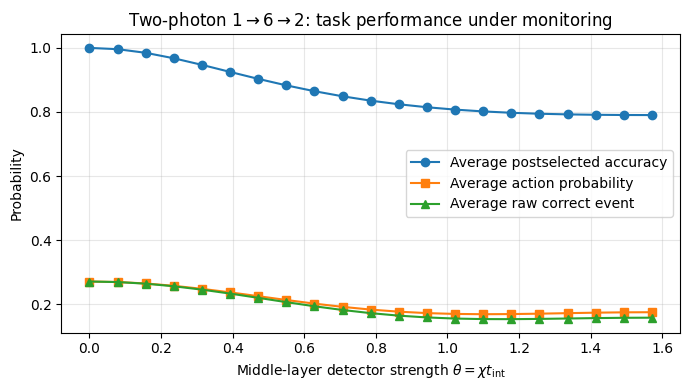

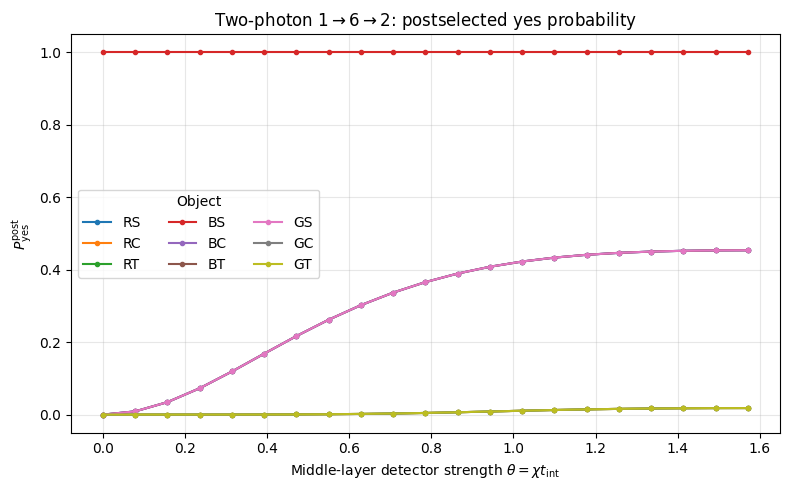

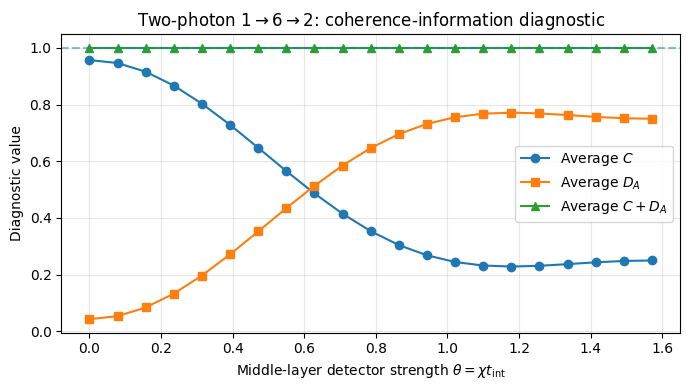

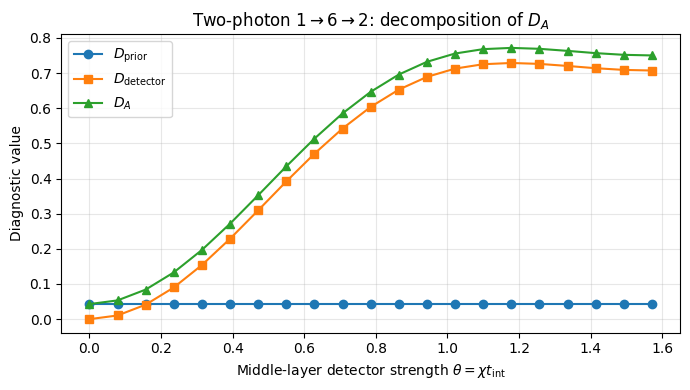

In [459]:
# ============================================================
# Two-photon sweep summary and plots
# ============================================================

semantic_162_summary = (
    semantic_162_ancilla_df
    .groupby("theta")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
        avg_raw_wrong=("raw_wrong", "mean"),
        avg_C_mid=("C_mid", "mean"),
        avg_D_A_mid=("D_A_mid", "mean"),
        avg_C_plus_D_A=("C_plus_D_A", "mean"),
        avg_D_prior_mid=("D_prior_mid", "mean"),
        avg_D_detector_mid=("D_detector_mid", "mean"),
        avg_slack_mid=("slack_mid", "mean"),
    )
    .reset_index()
)

display(semantic_162_summary.head())


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_correct_post"],
    marker="o",
    label="Average postselected accuracy",
)
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_P_act"],
    marker="s",
    label="Average action probability",
)
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_raw_correct"],
    marker="^",
    label="Average raw correct event",
)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Probability")
plt.title(
    r"Two-photon $1\to6\to2$: task performance under monitoring"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

for obj in semantic_162_OBJECT_ORDER:
    semantic_162_sub = semantic_162_ancilla_df[
        semantic_162_ancilla_df["object"] == obj
    ]
    plt.plot(
        semantic_162_sub["theta"],
        semantic_162_sub["P_yes_post"],
        marker="o",
        markersize=3,
        label=obj,
    )

plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel(r"$P_{\rm yes}^{\rm post}$")
plt.title(
    r"Two-photon $1\to6\to2$: postselected yes probability"
)
plt.grid(True, alpha=0.3)
plt.legend(title="Object", ncol=3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_C_mid"],
    marker="o",
    label=r"Average $C$",
)
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_D_A_mid"],
    marker="s",
    label=r"Average $D_A$",
)
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_C_plus_D_A"],
    marker="^",
    label=r"Average $C+D_A$",
)
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Diagnostic value")
plt.title(
    r"Two-photon $1\to6\to2$: coherence-information diagnostic"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_D_prior_mid"],
    marker="o",
    label=r"$D_{\rm prior}$",
)
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_D_detector_mid"],
    marker="s",
    label=r"$D_{\rm detector}$",
)
plt.plot(
    semantic_162_summary["theta"],
    semantic_162_summary["avg_D_A_mid"],
    marker="^",
    label=r"$D_A$",
)
plt.xlabel(r"Middle-layer detector strength $\theta=\chi t_{\rm int}$")
plt.ylabel("Diagnostic value")
plt.title(
    r"Two-photon $1\to6\to2$: decomposition of $D_A$"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Full two-photon 9→6→2 graph

The preceding $1\to6\to2$ construction used a percept-dependent first Hamiltonian to prepare each semantic state exactly. We now build the direct analogue of the fixed $4\to4\to2$ graph.

The architecture is

$$
9\to6\to2,
$$

with nine input modes

$$
(RS,RC,RT,BS,BC,BT,GS,GC,GT),
$$

six feature modes

$$
(R,B,G,S,C,T),
$$

and the two output modes $(\mathrm{no},\mathrm{yes})$. Two photons begin in the selected input mode.

One common quadratic Hamiltonian $H_1$ connects every input mode to its phase-coded color-shape feature vector. Because the desired two-photon feature states are not mutually orthogonal, the common unitary cannot transfer all nine orthogonal input states exactly into those targets. We therefore repeat the fixed-graph analysis:

1. sweep the first-layer time $t_1$;
2. measure the probability that both photons reach the feature layer;
3. condition on that event and compare with the intended two-photon semantic state;
4. evaluate the pair-sensitive postselected action readout;
5. add six feature ancillas at a selected operating point.

In [460]:
# ============================================================
# Full 9→6→2 two-photon graph: modes and common H1
# ============================================================

semantic_962_INPUT_MODES = {
    obj: i + 1
    for i, obj in enumerate(semantic_162_OBJECT_ORDER)
}

semantic_962_FEATURE_MODES = {
    name: 10 + i
    for i, name in enumerate(semantic_162_FEATURE_ORDER)
}

semantic_962_OUTPUT_MODES = {
    "no": 16,
    "yes": 17,
}

semantic_962_feature_modes_ordered = [
    semantic_962_FEATURE_MODES[name]
    for name in semantic_162_FEATURE_ORDER
]

hs_962 = FixedNBosons(m=17, N=2)


def semantic_two_photon_state_in_modes(
    hs,
    single_particle_vector,
    ordered_modes,
):
    state = np.zeros(hs.dim, dtype=complex)

    for i, amp_i in enumerate(single_particle_vector):
        occupations = [0] * hs.m
        occupations[ordered_modes[i] - 1] = 2
        state += amp_i**2 * hs.ket(tuple(occupations))

        for j in range(i + 1, len(single_particle_vector)):
            occupations = [0] * hs.m
            occupations[ordered_modes[i] - 1] = 1
            occupations[ordered_modes[j] - 1] = 1
            state += (
                np.sqrt(2)
                * amp_i
                * single_particle_vector[j]
                * hs.ket(tuple(occupations))
            )

    return state / np.linalg.norm(state)


def semantic_two_photons_in_mode(hs, mode):
    occupations = [0] * hs.m
    occupations[mode - 1] = 2
    return hs.ket(tuple(occupations))


semantic_962_target_states = {
    obj: semantic_two_photon_state_in_modes(
        hs_962,
        semantic_162_single_particle_vectors[obj],
        semantic_962_feature_modes_ordered,
    )
    for obj in semantic_162_OBJECT_ORDER
}

semantic_962_input_states = {
    obj: semantic_two_photons_in_mode(
        hs_962,
        semantic_962_INPUT_MODES[obj],
    )
    for obj in semantic_162_OBJECT_ORDER
}

# Rows: features. Columns: the nine percept input modes.
semantic_962_K1 = np.column_stack([
    semantic_162_single_particle_vectors[obj]
    for obj in semantic_162_OBJECT_ORDER
])

semantic_962_edges1 = edges_from_K(
    K=semantic_962_K1,
    src_modes=[
        semantic_962_INPUT_MODES[obj]
        for obj in semantic_162_OBJECT_ORDER
    ],
    dst_modes=semantic_962_feature_modes_ordered,
)

semantic_962_H1 = build_H_edges(
    hs_962,
    semantic_962_edges1,
)

print("9→6 K1 singular values:")
print(
    np.round(
        np.linalg.svd(
            semantic_962_K1,
            compute_uv=False,
        ),
        6,
    )
)


9→6 K1 singular values:
[1.667566 1.510224 1.224745 1.224745 0.848071 0.468213]


In [461]:
# ============================================================
# Pair-sensitive readout embedded in the 17-mode Hilbert space
# ============================================================

semantic_962_target = semantic_962_target_states["BS"]
semantic_962_negative_matrix = np.column_stack([
    semantic_962_target_states[obj]
    for obj in semantic_162_OBJECT_ORDER
    if obj != "BS"
])

semantic_962_U_neg, semantic_962_s_neg, _ = np.linalg.svd(
    semantic_962_negative_matrix,
    full_matrices=False,
)
semantic_962_rank_neg = int(
    np.sum(semantic_962_s_neg > 1e-12)
)
semantic_962_Q_neg = semantic_962_U_neg[
    :,
    :semantic_962_rank_neg,
]

semantic_962_w_yes = (
    semantic_962_target
    - semantic_962_Q_neg
    @ (semantic_962_Q_neg.conj().T @ semantic_962_target)
)
semantic_962_w_yes /= np.linalg.norm(
    semantic_962_w_yes
)

semantic_962_no_candidate = np.sum(
    semantic_962_negative_matrix,
    axis=1,
)

semantic_962_constraints = np.column_stack([
    semantic_962_target,
    semantic_962_w_yes,
])
semantic_962_Q_constraints, _ = np.linalg.qr(
    semantic_962_constraints,
)

semantic_962_w_no = (
    semantic_962_no_candidate
    - semantic_962_Q_constraints
    @ (
        semantic_962_Q_constraints.conj().T
        @ semantic_962_no_candidate
    )
)
semantic_962_w_no /= np.linalg.norm(
    semantic_962_w_no
)

semantic_962_out_no = semantic_two_photons_in_mode(
    hs_962,
    semantic_962_OUTPUT_MODES["no"],
)
semantic_962_out_yes = semantic_two_photons_in_mode(
    hs_962,
    semantic_962_OUTPUT_MODES["yes"],
)

semantic_962_g2 = 1.0
semantic_962_t2 = np.pi / (2 * semantic_962_g2)

semantic_962_H2 = csr_matrix(
    semantic_962_g2
    * (
        np.outer(
            semantic_962_out_no,
            semantic_962_w_no.conj(),
        )
        + np.outer(
            semantic_962_w_no,
            semantic_962_out_no.conj(),
        )
        + np.outer(
            semantic_962_out_yes,
            semantic_962_w_yes.conj(),
        )
        + np.outer(
            semantic_962_w_yes,
            semantic_962_out_yes.conj(),
        )
    )
)


def semantic_962_action_probabilities(psi):
    P_no = float(
        abs(np.vdot(semantic_962_out_no, psi)) ** 2
    )
    P_yes = float(
        abs(np.vdot(semantic_962_out_yes, psi)) ** 2
    )
    return postselected_action_probabilities(P_no, P_yes)


In [462]:
# ============================================================
# Fixed 9→6→2 preparation and task diagnostics
# ============================================================

semantic_962_feature_mode_set = set(
    semantic_962_feature_modes_ordered
)


def semantic_962_feature_projection(psi):
    projected = np.zeros_like(psi)

    for index, occupations in enumerate(hs_962.basis):
        feature_number = sum(
            occupations[mode - 1]
            for mode in semantic_962_feature_modes_ordered
        )

        if feature_number == 2:
            projected[index] = psi[index]

    probability = float(
        np.real(np.vdot(projected, projected))
    )

    return projected, probability


def semantic_962_preparation_diagnostic(
    object_label,
    t1,
):
    psi1 = evolve(
        semantic_962_H1,
        semantic_962_input_states[object_label],
        t1,
    )

    feature_component, P_feature = (
        semantic_962_feature_projection(psi1)
    )

    target_overlap_raw = float(
        abs(
            np.vdot(
                semantic_962_target_states[object_label],
                feature_component,
            )
        ) ** 2
    )

    if P_feature > 1e-14:
        target_fidelity_cond = (
            target_overlap_raw / P_feature
        )
    else:
        target_fidelity_cond = np.nan

    return {
        "object": object_label,
        "t1": float(t1),
        "P_feature_after_H1": P_feature,
        "P_outside_after_H1": 1.0 - P_feature,
        "target_overlap_raw": target_overlap_raw,
        "target_fidelity_cond": target_fidelity_cond,
        "P_no_bright_after_H1": float(
            abs(
                np.vdot(
                    semantic_962_w_no,
                    feature_component,
                )
            ) ** 2
        ),
        "P_yes_bright_after_H1": float(
            abs(
                np.vdot(
                    semantic_962_w_yes,
                    feature_component,
                )
            ) ** 2
        ),
    }


def semantic_962_run_no_ancillas(
    object_label,
    t1,
):
    psi1 = evolve(
        semantic_962_H1,
        semantic_962_input_states[object_label],
        t1,
    )
    psi2 = evolve(
        semantic_962_H2,
        psi1,
        semantic_962_t2,
    )

    probabilities = semantic_962_action_probabilities(
        psi2
    )
    probabilities["object"] = object_label
    probabilities["t1"] = float(t1)
    probabilities["correct_post"] = (
        semantic_162_correct_probability(
            object_label,
            probabilities,
        )
    )

    if object_label == "BS":
        probabilities["raw_correct"] = probabilities["P_yes"]
        probabilities["raw_wrong"] = probabilities["P_no"]
    else:
        probabilities["raw_correct"] = probabilities["P_no"]
        probabilities["raw_wrong"] = probabilities["P_yes"]

    return probabilities


In [463]:
# ============================================================
# Fixed 9→6→2 sweep over first-layer time
# ============================================================

semantic_962_t1_values = np.linspace(
    0.02,
    8.0,
    120,
)

semantic_962_sweep_rows = []

for t1 in semantic_962_t1_values:
    for obj in semantic_162_OBJECT_ORDER:
        prep = semantic_962_preparation_diagnostic(
            obj,
            float(t1),
        )
        task = semantic_962_run_no_ancillas(
            obj,
            float(t1),
        )

        semantic_962_sweep_rows.append({
            **prep,
            "P_no": task["P_no"],
            "P_yes": task["P_yes"],
            "P_act": task["P_act"],
            "P_no_post": task["P_no_post"],
            "P_yes_post": task["P_yes_post"],
            "correct_post": task["correct_post"],
            "raw_correct": task["raw_correct"],
            "raw_wrong": task["raw_wrong"],
        })

semantic_962_sweep_df = pd.DataFrame(
    semantic_962_sweep_rows
)

semantic_962_sweep_summary = (
    semantic_962_sweep_df
    .groupby("t1")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
        avg_raw_wrong=("raw_wrong", "mean"),
        avg_P_feature_after_H1=(
            "P_feature_after_H1",
            "mean",
        ),
        avg_target_fidelity_cond=(
            "target_fidelity_cond",
            "mean",
        ),
    )
    .reset_index()
)

semantic_962_best_index = (
    semantic_962_sweep_summary[
        "avg_raw_correct"
    ].idxmax()
)
semantic_962_t1_selected = float(
    semantic_962_sweep_summary.loc[
        semantic_962_best_index,
        "t1",
    ]
)

print(
    "Selected t1 from maximum average raw correct event:",
    semantic_962_t1_selected,
)
display(
    semantic_962_sweep_summary.loc[
        [semantic_962_best_index]
    ]
)


Selected t1 from maximum average raw correct event: 1.0929411764705883


,t1,avg_correct_post,avg_P_act,avg_raw_correct,avg_raw_wrong,avg_P_feature_after_H1,avg_target_fidelity_cond
16,1.092941,0.944861,0.066762,0.06628,0.000482,0.273306,0.942489


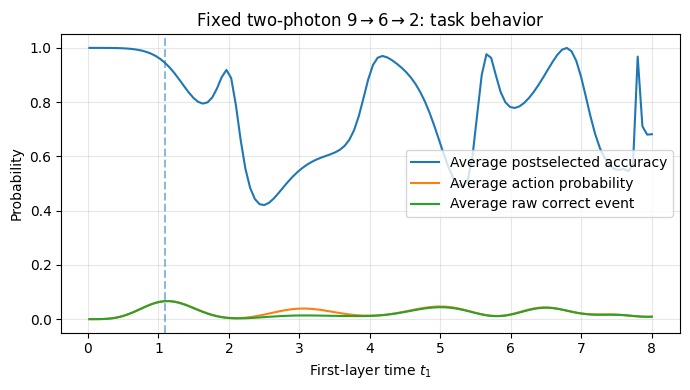

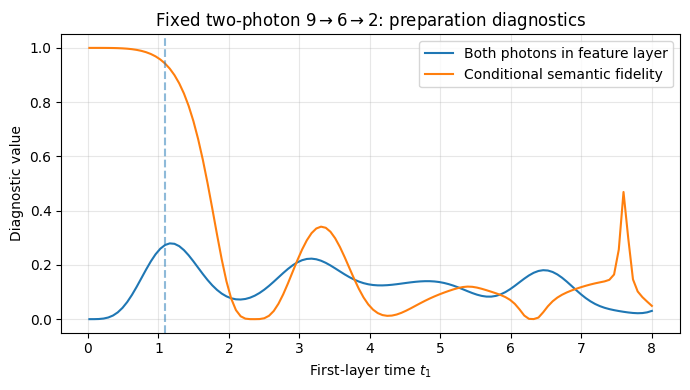

,object,P_feature_after_H1,target_fidelity_cond,P_no_bright_after_H1,P_yes_bright_after_H1,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post
0,RS,0.273554,0.941715,7.312016e-03,0.001029,7.312016e-03,0.001029,0.008341,8.765839e-01,0.123416,0.876584
1,RC,0.272398,0.945275,8.466125e-02,0.000055,8.466125e-02,0.000055,0.084716,9.993540e-01,0.000646,0.999354
2,RT,0.272398,0.945275,8.466125e-02,0.000055,8.466125e-02,0.000055,0.084716,9.993540e-01,0.000646,0.999354
3,BS,0.275942,0.934437,1.925930e-34,0.228624,7.800609e-34,0.228624,0.228624,3.411985e-33,1.000000,1.000000
4,BC,0.273554,0.941715,7.312016e-03,0.001029,7.312016e-03,0.001029,0.008341,8.765839e-01,0.123416,0.876584
5,BT,0.273554,0.941715,7.312016e-03,0.001029,7.312016e-03,0.001029,0.008341,8.765839e-01,0.123416,0.876584
6,GS,0.273554,0.941715,7.312016e-03,0.001029,7.312016e-03,0.001029,0.008341,8.765839e-01,0.123416,0.876584
7,GC,0.272398,0.945275,8.466125e-02,0.000055,8.466125e-02,0.000055,0.084716,9.993540e-01,0.000646,0.999354
8,GT,0.272398,0.945275,8.466125e-02,0.000055,8.466125e-02,0.000055,0.084716,9.993540e-01,0.000646,0.999354


In [464]:
# ============================================================
# Fixed 9→6→2 sweep plots and selected operating point
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_962_sweep_summary["t1"],
    semantic_962_sweep_summary["avg_correct_post"],
    label="Average postselected accuracy",
)
plt.plot(
    semantic_962_sweep_summary["t1"],
    semantic_962_sweep_summary["avg_P_act"],
    label="Average action probability",
)
plt.plot(
    semantic_962_sweep_summary["t1"],
    semantic_962_sweep_summary["avg_raw_correct"],
    label="Average raw correct event",
)
plt.axvline(
    semantic_962_t1_selected,
    linestyle="--",
    alpha=0.5,
)
plt.xlabel(r"First-layer time $t_1$")
plt.ylabel("Probability")
plt.title(
    r"Fixed two-photon $9\to6\to2$: task behavior"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_962_sweep_summary["t1"],
    semantic_962_sweep_summary[
        "avg_P_feature_after_H1"
    ],
    label="Both photons in feature layer",
)
plt.plot(
    semantic_962_sweep_summary["t1"],
    semantic_962_sweep_summary[
        "avg_target_fidelity_cond"
    ],
    label="Conditional semantic fidelity",
)
plt.axvline(
    semantic_962_t1_selected,
    linestyle="--",
    alpha=0.5,
)
plt.xlabel(r"First-layer time $t_1$")
plt.ylabel("Diagnostic value")
plt.title(
    r"Fixed two-photon $9\to6\to2$: preparation diagnostics"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


semantic_962_selected_rows = []

for obj in semantic_162_OBJECT_ORDER:
    prep = semantic_962_preparation_diagnostic(
        obj,
        semantic_962_t1_selected,
    )
    task = semantic_962_run_no_ancillas(
        obj,
        semantic_962_t1_selected,
    )
    semantic_962_selected_rows.append({
        **prep,
        **{
            key: task[key]
            for key in [
                "P_no",
                "P_yes",
                "P_act",
                "P_no_post",
                "P_yes_post",
                "correct_post",
            ]
        },
    })

semantic_962_selected_df = pd.DataFrame(
    semantic_962_selected_rows
)

display(
    semantic_962_selected_df[
        [
            "object",
            "P_feature_after_H1",
            "target_fidelity_cond",
            "P_no_bright_after_H1",
            "P_yes_bright_after_H1",
            "P_no",
            "P_yes",
            "P_act",
            "P_no_post",
            "P_yes_post",
            "correct_post",
        ]
    ]
)


### Full 9→6→2 graph with feature ancillas

We insert six ancillas after the common first-layer Hamiltonian and before the pair-sensitive action readout:

$$
\mathrm{input}
\rightarrow
H_1
\rightarrow
\mathrm{six\ features}
\rightarrow
U_{\mathrm{int}}(\theta)
\rightarrow
H_2
\rightarrow
\mathrm{no/yes}.
$$

This repeats the monitored fixed-graph experiment from the $4\to4\to2$ section. The first layer already introduces preparation error because it attempts to map orthogonal input states to nonorthogonal semantic targets. The ancillas add a second source of performance loss by resolving feature occupation patterns.

In [465]:
# ============================================================
# Full 9→6→2 graph with six feature ancillas
# ============================================================


# Fast equivalent of wp_layer_diagnostic for larger Hilbert spaces.
# It groups amplitudes by local and environment occupations before forming
# reduced states, and uses pure-state fidelity formulas whenever possible.
def semantic_fast_wp_layer_diagnostic(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes,
    p_tol=1e-14,
):
    Psi = np.asarray(psi_full, dtype=complex).reshape(
        hs.dim,
        dim_ancilla,
    )

    active_rows = [
        index
        for index in range(hs.dim)
        if np.sum(np.abs(Psi[index, :]) ** 2) > p_tol
    ]

    local_labels = {
        index: local_config(
            hs.basis[index],
            layer_modes,
        )
        for index in active_rows
    }
    environment_labels = {
        index: env_config(
            hs.basis[index],
            layer_modes,
        )
        for index in active_rows
    }

    configs = sorted(set(local_labels.values()))
    config_to_index = {
        config: index
        for index, config in enumerate(configs)
    }

    rows_by_environment = {}
    rows_by_config = {}

    for row in active_rows:
        rows_by_environment.setdefault(
            environment_labels[row],
            [],
        ).append(row)
        rows_by_config.setdefault(
            local_labels[row],
            [],
        ).append(row)

    rho_layer = np.zeros(
        (len(configs), len(configs)),
        dtype=complex,
    )

    for rows in rows_by_environment.values():
        block = Psi[rows, :]
        gram = block @ block.conj().T

        for a, row_a in enumerate(rows):
            i = config_to_index[local_labels[row_a]]
            for b, row_b in enumerate(rows):
                j = config_to_index[local_labels[row_b]]
                rho_layer[i, j] += gram[a, b]

    rho_layer = 0.5 * (
        rho_layer + rho_layer.conj().T
    )
    trace = float(np.real(np.trace(rho_layer)))
    rho_layer /= trace

    probabilities = {
        config: float(
            np.real(
                rho_layer[
                    config_to_index[config],
                    config_to_index[config],
                ]
            )
        )
        for config in configs
    }
    active_configs = [
        config
        for config in configs
        if probabilities[config] > p_tol
    ]

    R = len(active_configs)

    if R <= 1:
        C = 0.0
    else:
        C = sum(
            abs(
                rho_layer[
                    config_to_index[mu],
                    config_to_index[nu],
                ]
            )
            for mu in active_configs
            for nu in active_configs
            if mu != nu
        ) / (R - 1)

    ancilla_states = {}
    pure_vectors = {}

    for config in active_configs:
        block = Psi[rows_by_config[config], :]
        rho_ancilla = block.conj().T @ block
        rho_ancilla /= np.trace(rho_ancilla)
        rho_ancilla = 0.5 * (
            rho_ancilla + rho_ancilla.conj().T
        )
        ancilla_states[config] = rho_ancilla

        purity = float(
            np.real(
                np.sum(np.abs(rho_ancilla) ** 2)
            )
        )

        if purity > 1.0 - 1e-10:
            row_norms = np.sum(np.abs(block) ** 2, axis=1)
            vector = block[int(np.argmax(row_norms)), :].conj()
            pure_vectors[config] = (
                vector / np.linalg.norm(vector)
            )

    def conditioned_fidelity(mu, nu):
        mu_pure = mu in pure_vectors
        nu_pure = nu in pure_vectors

        if mu_pure and nu_pure:
            return float(
                abs(
                    np.vdot(
                        pure_vectors[mu],
                        pure_vectors[nu],
                    )
                )
            )

        if mu_pure:
            value = np.vdot(
                pure_vectors[mu],
                ancilla_states[nu]
                @ pure_vectors[mu],
            )
            return float(
                np.sqrt(max(0.0, np.real(value)))
            )

        if nu_pure:
            value = np.vdot(
                pure_vectors[nu],
                ancilla_states[mu]
                @ pure_vectors[nu],
            )
            return float(
                np.sqrt(max(0.0, np.real(value)))
            )

        return fidelity_dm(
            ancilla_states[mu],
            ancilla_states[nu],
        )

    pairwise_fidelities = {}

    if R <= 1:
        overlap_term = 0.0
        D_A = 0.0
    else:
        weighted_overlap_sum = 0.0

        for mu in active_configs:
            for nu in active_configs:
                if mu == nu:
                    continue

                fidelity = conditioned_fidelity(mu, nu)
                pairwise_fidelities[(mu, nu)] = fidelity
                weighted_overlap_sum += (
                    np.sqrt(
                        probabilities[mu]
                        * probabilities[nu]
                    )
                    * fidelity
                )

        overlap_term = weighted_overlap_sum / (R - 1)
        D_A = float(
            np.clip(
                1.0 - overlap_term,
                0.0,
                1.0,
            )
        )

    return {
        "layer_modes": tuple(layer_modes),
        "rho_layer": rho_layer,
        "configs": configs,
        "probabilities": probabilities,
        "conditioned_ancilla_states": ancilla_states,
        "active_configs": active_configs,
        "number_configs_total": len(configs),
        "number_configs_active": R,
        "C": float(C),
        "D_A": D_A,
        "C_plus_D": float(C + D_A),
        "slack": float(1.0 - C - D_A),
        "overlap_term": float(overlap_term),
        "pairwise_fidelities": pairwise_fidelities,
        "max_probability_difference_check": 0.0,
    }

semantic_962_num_ancillas = len(
    semantic_962_feature_modes_ordered
)
semantic_962_dim_ancilla = (
    2 ** semantic_962_num_ancillas
)
semantic_962_psi_anc_plus = plus_state_qubits(
    semantic_962_num_ancillas
)

semantic_962_H_mid_int_base = (
    build_middle_dispersion_hamiltonian(
        hs=hs_962,
        monitored_modes=(
            semantic_962_feature_modes_ordered
        ),
    )
)

semantic_962_I_anc = identity(
    semantic_962_dim_ancilla,
    format="csr",
    dtype=complex,
)

semantic_962_H1_full = kron(
    semantic_962_H1,
    semantic_962_I_anc,
    format="csr",
)
semantic_962_H2_full = kron(
    semantic_962_H2,
    semantic_962_I_anc,
    format="csr",
)

semantic_962_out_no_index = hs_962.basis_to_index[
    tuple(
        2 if i == semantic_962_OUTPUT_MODES["no"] - 1 else 0
        for i in range(hs_962.m)
    )
]
semantic_962_out_yes_index = hs_962.basis_to_index[
    tuple(
        2 if i == semantic_962_OUTPUT_MODES["yes"] - 1 else 0
        for i in range(hs_962.m)
    )
]


def semantic_full_event_probability(
    psi_full,
    hs,
    dim_ancilla,
    photonic_basis_index,
):
    matrix = np.asarray(psi_full).reshape(
        hs.dim,
        dim_ancilla,
    )
    return float(
        np.sum(
            np.abs(
                matrix[photonic_basis_index, :]
            ) ** 2
        )
    )


def semantic_962_run_ancilla_point(
    object_label,
    theta,
    compute_wp=True,
):
    psi_full0 = np.kron(
        semantic_962_input_states[object_label],
        semantic_962_psi_anc_plus,
    )

    psi_after_H1 = expm_multiply(
        (-1j * semantic_962_t1_selected)
        * semantic_962_H1_full,
        psi_full0,
    )
    psi_after_int = expm_multiply(
        (-1j * theta)
        * semantic_962_H_mid_int_base,
        psi_after_H1,
    )

    diagnostic = None
    if compute_wp:
        diagnostic = semantic_fast_wp_layer_diagnostic(
            psi_full=psi_after_int,
            hs=hs_962,
            dim_ancilla=semantic_962_dim_ancilla,
            layer_modes=tuple(
                semantic_962_feature_modes_ordered
            ),
        )

    psi_after_H2 = expm_multiply(
        (-1j * semantic_962_t2)
        * semantic_962_H2_full,
        psi_after_int,
    )

    P_no = semantic_full_event_probability(
        psi_after_H2,
        hs_962,
        semantic_962_dim_ancilla,
        semantic_962_out_no_index,
    )
    P_yes = semantic_full_event_probability(
        psi_after_H2,
        hs_962,
        semantic_962_dim_ancilla,
        semantic_962_out_yes_index,
    )

    probabilities = postselected_action_probabilities(
        P_no,
        P_yes,
    )
    probabilities["object"] = object_label
    probabilities["theta"] = float(theta)
    probabilities["correct_post"] = (
        semantic_162_correct_probability(
            object_label,
            probabilities,
        )
    )

    if diagnostic is not None:
        probabilities["C_mid"] = float(
            diagnostic["C"]
        )
        probabilities["D_A_mid"] = float(
            diagnostic["D_A"]
        )
        probabilities["C_plus_D_A"] = float(
            diagnostic["C_plus_D"]
        )

    return probabilities


semantic_962_theta_values = np.linspace(
    0,
    np.pi / 2,
    13,
)
semantic_962_ancilla_rows = []

for theta in semantic_962_theta_values:
    for obj in semantic_162_OBJECT_ORDER:
        semantic_962_ancilla_rows.append(
            semantic_962_run_ancilla_point(
                obj,
                float(theta),
                compute_wp=True,
            )
        )

semantic_962_ancilla_df = pd.DataFrame(
    semantic_962_ancilla_rows
)


,theta,avg_correct_post,avg_P_act,avg_C_mid,avg_D_A_mid,avg_C_plus_D_A
0,0.000000,0.944861,0.066762,0.086337,0.710736,0.797072
1,0.130900,0.932711,0.065708,0.084262,0.716665,0.800927
2,0.261799,0.902018,0.062762,0.078318,0.733837,0.812155
3,0.392699,0.864911,0.058516,0.069289,0.760494,0.829783
4,0.523599,0.831443,0.053794,0.058309,0.794022,0.852331


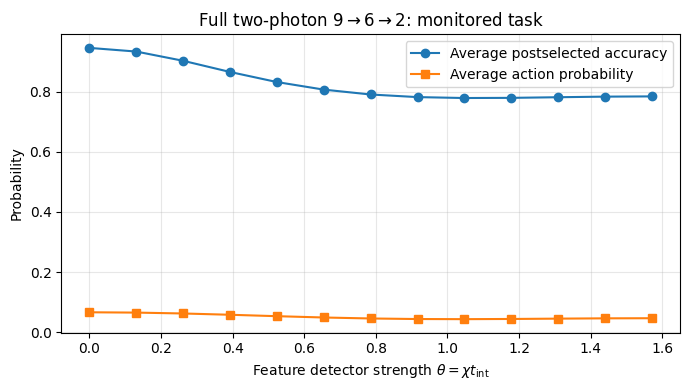

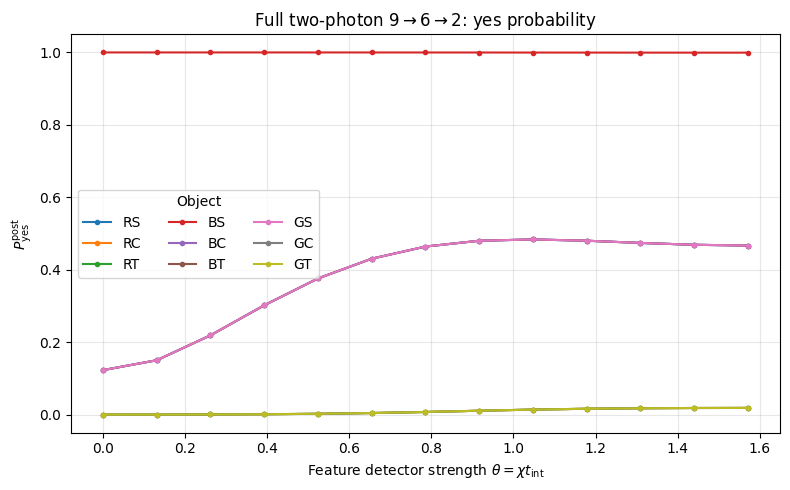

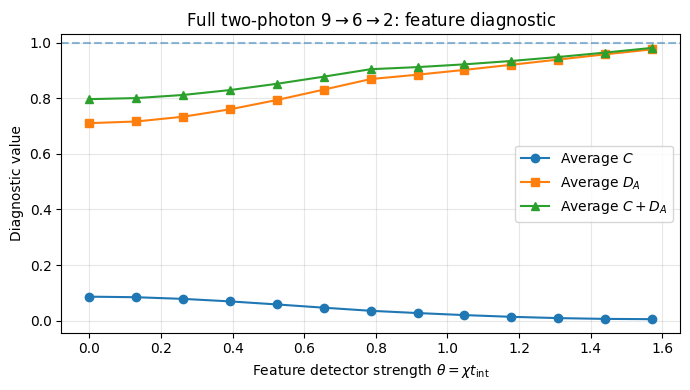

In [466]:
# ============================================================
# Full 9→6→2 ancilla summary and plots
# ============================================================

semantic_962_ancilla_summary = (
    semantic_962_ancilla_df
    .groupby("theta")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_C_mid=("C_mid", "mean"),
        avg_D_A_mid=("D_A_mid", "mean"),
        avg_C_plus_D_A=("C_plus_D_A", "mean"),
    )
    .reset_index()
)

display(semantic_962_ancilla_summary.head())

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_962_ancilla_summary["theta"],
    semantic_962_ancilla_summary[
        "avg_correct_post"
    ],
    marker="o",
    label="Average postselected accuracy",
)
plt.plot(
    semantic_962_ancilla_summary["theta"],
    semantic_962_ancilla_summary["avg_P_act"],
    marker="s",
    label="Average action probability",
)
plt.xlabel(
    r"Feature detector strength $\theta=\chi t_{\rm int}$"
)
plt.ylabel("Probability")
plt.title(
    r"Full two-photon $9\to6\to2$: monitored task"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
for obj in semantic_162_OBJECT_ORDER:
    sub = semantic_962_ancilla_df[
        semantic_962_ancilla_df["object"] == obj
    ]
    plt.plot(
        sub["theta"],
        sub["P_yes_post"],
        marker="o",
        markersize=3,
        label=obj,
    )
plt.xlabel(
    r"Feature detector strength $\theta=\chi t_{\rm int}$"
)
plt.ylabel(r"$P_{\rm yes}^{\rm post}$")
plt.title(
    r"Full two-photon $9\to6\to2$: yes probability"
)
plt.grid(True, alpha=0.3)
plt.legend(title="Object", ncol=3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_962_ancilla_summary["theta"],
    semantic_962_ancilla_summary["avg_C_mid"],
    marker="o",
    label=r"Average $C$",
)
plt.plot(
    semantic_962_ancilla_summary["theta"],
    semantic_962_ancilla_summary["avg_D_A_mid"],
    marker="s",
    label=r"Average $D_A$",
)
plt.plot(
    semantic_962_ancilla_summary["theta"],
    semantic_962_ancilla_summary[
        "avg_C_plus_D_A"
    ],
    marker="^",
    label=r"Average $C+D_A$",
)
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(
    r"Feature detector strength $\theta=\chi t_{\rm int}$"
)
plt.ylabel("Diagnostic value")
plt.title(
    r"Full two-photon $9\to6\to2$: feature diagnostic"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Two-photon 9→3→3→2 shape-color graph

We now split the six-feature layer into two three-mode semantic layers:

$$
9\to3\to3\to2.
$$

The first middle layer represents shape and the second represents color. Two photons act as separate semantic carriers. At the end of the semantic preparation, one photon occupies the shape layer and one occupies the color layer.

To retain coherence inside each three-mode layer, the three labels use an orthonormal Fourier code:

$$
|f_k\rangle
=
\frac{1}{\sqrt{3}}
\left(
|1\rangle
+\omega^k|2\rangle
+\omega^{2k}|3\rangle
\right),
\qquad
\omega=e^{2\pi i/3}.
$$

The staged pair Hamiltonians perform

$$
|2_{x}\rangle_{\mathrm{input}}
\rightarrow
|1_x\rangle_{\mathrm{input}}
|s(x)\rangle_{\mathrm{shape}}
\rightarrow
|c(x)\rangle_{\mathrm{color}}
|s(x)\rangle_{\mathrm{shape}}.
$$

The input photon remains as an object-addressed control during the first transfer, then moves into the color layer during the second transfer. This preserves all nine color-shape conjunctions despite each middle layer containing only three modes.

Three ancillas monitor the shape layer after the first transfer. Three more ancillas monitor the color layer after the second transfer. We compare shape-only monitoring, color-only monitoring, and equal-strength monitoring of both layers.

In [467]:
# ============================================================
# 9→3→3→2 modes, Fourier codes, and semantic states
# ============================================================

semantic_9332_INPUT_MODES = {
    obj: i + 1
    for i, obj in enumerate(semantic_162_OBJECT_ORDER)
}
semantic_9332_SHAPE_MODES = {
    "S": 10,
    "C": 11,
    "T": 12,
}
semantic_9332_COLOR_MODES = {
    "R": 13,
    "B": 14,
    "G": 15,
}
semantic_9332_OUTPUT_MODES = {
    "no": 16,
    "yes": 17,
}

semantic_9332_shape_modes_ordered = [
    semantic_9332_SHAPE_MODES[label]
    for label in semantic_162_SHAPES
]
semantic_9332_color_modes_ordered = [
    semantic_9332_COLOR_MODES[label]
    for label in semantic_162_COLORS
]

hs_9332 = FixedNBosons(m=17, N=2)

semantic_9332_omega = np.exp(2j * np.pi / 3)


def semantic_9332_fourier_vector(label, labels):
    k = labels.index(label)
    return np.array(
        [
            1,
            semantic_9332_omega**k,
            semantic_9332_omega**(2 * k),
        ],
        dtype=complex,
    ) / np.sqrt(3)


semantic_9332_shape_vectors = {
    label: semantic_9332_fourier_vector(
        label,
        semantic_162_SHAPES,
    )
    for label in semantic_162_SHAPES
}
semantic_9332_color_vectors = {
    label: semantic_9332_fourier_vector(
        label,
        semantic_162_COLORS,
    )
    for label in semantic_162_COLORS
}


def semantic_9332_one_input_one_layer(
    object_label,
    layer_vector,
    layer_modes,
):
    state = np.zeros(hs_9332.dim, dtype=complex)
    input_mode = semantic_9332_INPUT_MODES[
        object_label
    ]

    for amplitude, layer_mode in zip(
        layer_vector,
        layer_modes,
    ):
        occupations = [0] * hs_9332.m
        occupations[input_mode - 1] = 1
        occupations[layer_mode - 1] = 1
        state += amplitude * hs_9332.ket(
            tuple(occupations)
        )

    return state / np.linalg.norm(state)


def semantic_9332_shape_color_state(
    shape_vector,
    color_vector,
):
    state = np.zeros(hs_9332.dim, dtype=complex)

    for shape_amp, shape_mode in zip(
        shape_vector,
        semantic_9332_shape_modes_ordered,
    ):
        for color_amp, color_mode in zip(
            color_vector,
            semantic_9332_color_modes_ordered,
        ):
            occupations = [0] * hs_9332.m
            occupations[shape_mode - 1] = 1
            occupations[color_mode - 1] = 1
            state += (
                shape_amp
                * color_amp
                * hs_9332.ket(tuple(occupations))
            )

    return state / np.linalg.norm(state)


semantic_9332_input_states = {
    obj: semantic_two_photons_in_mode(
        hs_9332,
        semantic_9332_INPUT_MODES[obj],
    )
    for obj in semantic_162_OBJECT_ORDER
}

semantic_9332_shape_stage_states = {}
semantic_9332_final_semantic_states = {}

for obj in semantic_162_OBJECT_ORDER:
    color, shape = obj

    semantic_9332_shape_stage_states[obj] = (
        semantic_9332_one_input_one_layer(
            obj,
            semantic_9332_shape_vectors[shape],
            semantic_9332_shape_modes_ordered,
        )
    )

    semantic_9332_final_semantic_states[obj] = (
        semantic_9332_shape_color_state(
            semantic_9332_shape_vectors[shape],
            semantic_9332_color_vectors[color],
        )
    )

semantic_9332_final_gram = np.array([
    [
        np.vdot(
            semantic_9332_final_semantic_states[a],
            semantic_9332_final_semantic_states[b],
        )
        for b in semantic_162_OBJECT_ORDER
    ]
    for a in semantic_162_OBJECT_ORDER
])

print("Maximum off-diagonal final-state overlap:")
print(
    np.max(
        np.abs(
            semantic_9332_final_gram
            - np.eye(len(semantic_162_OBJECT_ORDER))
        )
    )
)


Maximum off-diagonal final-state overlap:
2.6328463341878794e-16


In [468]:
# ============================================================
# Exact staged pair Hamiltonians and action readout
# ============================================================

semantic_9332_g1 = 1.0
semantic_9332_g2 = 1.0
semantic_9332_g3 = 1.0

semantic_9332_t1 = np.pi / (2 * semantic_9332_g1)
semantic_9332_t2 = np.pi / (2 * semantic_9332_g2)
semantic_9332_t3 = np.pi / (2 * semantic_9332_g3)

semantic_9332_H1_dense = np.zeros(
    (hs_9332.dim, hs_9332.dim),
    dtype=complex,
)
semantic_9332_H2_dense = np.zeros_like(
    semantic_9332_H1_dense
)

for obj in semantic_162_OBJECT_ORDER:
    input_state = semantic_9332_input_states[obj]
    shape_state = semantic_9332_shape_stage_states[
        obj
    ]
    final_state = semantic_9332_final_semantic_states[
        obj
    ]

    semantic_9332_H1_dense += (
        semantic_9332_g1
        * (
            np.outer(shape_state, input_state.conj())
            + np.outer(input_state, shape_state.conj())
        )
    )

    semantic_9332_H2_dense += (
        semantic_9332_g2
        * (
            np.outer(final_state, shape_state.conj())
            + np.outer(shape_state, final_state.conj())
        )
    )

semantic_9332_H1 = csr_matrix(
    semantic_9332_H1_dense
)
semantic_9332_H2 = csr_matrix(
    semantic_9332_H2_dense
)

semantic_9332_w_yes = (
    semantic_9332_final_semantic_states["BS"]
)
semantic_9332_w_no = np.sum(
    [
        semantic_9332_final_semantic_states[obj]
        for obj in semantic_162_OBJECT_ORDER
        if obj != "BS"
    ],
    axis=0,
)
semantic_9332_w_no /= np.linalg.norm(
    semantic_9332_w_no
)

semantic_9332_out_no = semantic_two_photons_in_mode(
    hs_9332,
    semantic_9332_OUTPUT_MODES["no"],
)
semantic_9332_out_yes = semantic_two_photons_in_mode(
    hs_9332,
    semantic_9332_OUTPUT_MODES["yes"],
)

semantic_9332_H3 = csr_matrix(
    semantic_9332_g3
    * (
        np.outer(
            semantic_9332_out_no,
            semantic_9332_w_no.conj(),
        )
        + np.outer(
            semantic_9332_w_no,
            semantic_9332_out_no.conj(),
        )
        + np.outer(
            semantic_9332_out_yes,
            semantic_9332_w_yes.conj(),
        )
        + np.outer(
            semantic_9332_w_yes,
            semantic_9332_out_yes.conj(),
        )
    )
)


In [469]:
# ============================================================
# Unmonitored staged-preparation and classifier checks
# ============================================================

semantic_9332_baseline_rows = []

for obj in semantic_162_OBJECT_ORDER:
    psi1 = evolve(
        semantic_9332_H1,
        semantic_9332_input_states[obj],
        semantic_9332_t1,
    )
    psi2 = evolve(
        semantic_9332_H2,
        psi1,
        semantic_9332_t2,
    )
    psi3 = evolve(
        semantic_9332_H3,
        psi2,
        semantic_9332_t3,
    )

    P_no = float(
        abs(np.vdot(semantic_9332_out_no, psi3)) ** 2
    )
    P_yes = float(
        abs(np.vdot(semantic_9332_out_yes, psi3)) ** 2
    )
    probabilities = postselected_action_probabilities(
        P_no,
        P_yes,
    )

    semantic_9332_baseline_rows.append({
        "object": obj,
        "shape_stage_fidelity": float(
            abs(
                np.vdot(
                    -1j
                    * semantic_9332_shape_stage_states[obj],
                    psi1,
                )
            ) ** 2
        ),
        "final_semantic_fidelity": float(
            abs(
                np.vdot(
                    -semantic_9332_final_semantic_states[
                        obj
                    ],
                    psi2,
                )
            ) ** 2
        ),
        **probabilities,
        "correct_post": (
            semantic_162_correct_probability(
                obj,
                probabilities,
            )
        ),
    })

semantic_9332_baseline_df = pd.DataFrame(
    semantic_9332_baseline_rows
)

display(semantic_9332_baseline_df)


,object,shape_stage_fidelity,final_semantic_fidelity,P_no,P_yes,P_act,P_no_post,P_yes_post,correct_post
0,RS,1.0,1.0,1.250000e-01,4.417770e-33,0.125,1.000000e+00,3.534216e-32,1.0
1,RC,1.0,1.0,1.250000e-01,1.399848e-33,0.125,1.000000e+00,1.119878e-32,1.0
2,RT,1.0,1.0,1.250000e-01,2.045582e-33,0.125,1.000000e+00,1.636466e-32,1.0
3,BS,1.0,1.0,3.420019e-33,1.000000e+00,1.000,3.420019e-33,1.000000e+00,1.0
4,BC,1.0,1.0,1.250000e-01,2.567302e-33,0.125,1.000000e+00,2.053842e-32,1.0
5,BT,1.0,1.0,1.250000e-01,2.477534e-32,0.125,1.000000e+00,1.982028e-31,1.0
6,GS,1.0,1.0,1.250000e-01,2.038980e-32,0.125,1.000000e+00,1.631184e-31,1.0
7,GC,1.0,1.0,1.250000e-01,1.754268e-33,0.125,1.000000e+00,1.403414e-32,1.0
8,GT,1.0,1.0,1.250000e-01,4.442065e-33,0.125,1.000000e+00,3.553652e-32,1.0


### Ancillas on both semantic layers

The shape ancillas interact immediately after the first transfer:

$$
U_S(\theta_S)
=
\exp\left[
-i\theta_S
\sum_{m\in S,C,T}
n_m\otimes Z_m
\right].
$$

After the color-transfer Hamiltonian, the color ancillas interact through

$$
U_C(\theta_C)
=
\exp\left[
-i\theta_C
\sum_{m\in R,B,G}
n_m\otimes Z_m
\right].
$$

The two ancilla registers remain present through the later evolution. This lets the first register retain which-shape-mode information while the second gathers which-color-mode information.

We evaluate three paths through the two-dimensional detector-strength plane:

- shape only: $(\theta_S,\theta_C)=(\theta,0)$;
- color only: $(0,\theta)$;
- both layers: $(\theta,\theta)$.

The layer diagnostics are conditioned on one photon occupying the layer being diagnosed.

In [470]:
# ============================================================
# Shape and color ancilla registers
# ============================================================

semantic_9332_num_shape_ancillas = 3
semantic_9332_num_color_ancillas = 3
semantic_9332_num_ancillas = 6
semantic_9332_dim_ancilla = 2 ** 6

semantic_9332_psi_anc_plus = plus_state_qubits(6)


# Pauli-Y is the measured quadrature used by the detector model above.
semantic_9332_Y_ancilla_ops = [
    op_on_qubit(
        semantic_9332_num_ancillas,
        q,
        sigma_y,
    )
    for q in range(semantic_9332_num_ancillas)
]


def semantic_9332_ancilla_expectation_array(
    psi_full,
    qubit_indices,
):
    """
    Return the Pauli-Y expectation values for selected ancillas.

    The joint state is reshaped as
        Psi[photonic basis, ancilla basis].
    """
    joint_matrix = np.asarray(
        psi_full,
        dtype=complex,
    ).reshape(
        hs_9332.dim,
        semantic_9332_dim_ancilla,
    )

    expectations = []

    for q in qubit_indices:
        Y_q = semantic_9332_Y_ancilla_ops[q]
        value = sum(
            np.vdot(row, Y_q @ row)
            for row in joint_matrix
        )
        expectations.append(float(np.real(value)))

    return np.array(expectations, dtype=float)

semantic_9332_I_anc = identity(
    semantic_9332_dim_ancilla,
    format="csr",
    dtype=complex,
)


def semantic_9332_register_Z(global_qubit):
    return op_on_qubit(
        semantic_9332_num_ancillas,
        global_qubit,
        sigma_z,
    )


semantic_9332_H_shape_int = csr_matrix(
    (
        hs_9332.dim * semantic_9332_dim_ancilla,
        hs_9332.dim * semantic_9332_dim_ancilla,
    ),
    dtype=complex,
)

for q, mode in enumerate(
    semantic_9332_shape_modes_ordered
):
    semantic_9332_H_shape_int += kron(
        hs_9332.hop(mode, mode),
        semantic_9332_register_Z(q),
        format="csr",
    )

semantic_9332_H_color_int = csr_matrix(
    semantic_9332_H_shape_int.shape,
    dtype=complex,
)

for q, mode in enumerate(
    semantic_9332_color_modes_ordered
):
    semantic_9332_H_color_int += kron(
        hs_9332.hop(mode, mode),
        semantic_9332_register_Z(
            semantic_9332_num_shape_ancillas + q
        ),
        format="csr",
    )

semantic_9332_H1_full = kron(
    semantic_9332_H1,
    semantic_9332_I_anc,
    format="csr",
)
semantic_9332_H2_full = kron(
    semantic_9332_H2,
    semantic_9332_I_anc,
    format="csr",
)
semantic_9332_H3_full = kron(
    semantic_9332_H3,
    semantic_9332_I_anc,
    format="csr",
)

semantic_9332_out_no_index = hs_9332.basis_to_index[
    tuple(
        2 if i == semantic_9332_OUTPUT_MODES["no"] - 1 else 0
        for i in range(hs_9332.m)
    )
]
semantic_9332_out_yes_index = hs_9332.basis_to_index[
    tuple(
        2 if i == semantic_9332_OUTPUT_MODES["yes"] - 1 else 0
        for i in range(hs_9332.m)
    )
]


def semantic_project_joint_on_layer_number(
    psi_full,
    hs,
    dim_ancilla,
    layer_modes,
    photon_number,
):
    matrix = np.asarray(psi_full).reshape(
        hs.dim,
        dim_ancilla,
    ).copy()

    for index, occupations in enumerate(hs.basis):
        local_number = sum(
            occupations[mode - 1]
            for mode in layer_modes
        )
        if local_number != photon_number:
            matrix[index, :] = 0.0

    probability = float(
        np.sum(np.abs(matrix) ** 2)
    )

    if probability <= 1e-14:
        return None, probability

    return (
        matrix.reshape(-1) / np.sqrt(probability),
        probability,
    )


In [471]:
# ============================================================
# One monitored 9→3→3→2 run
# ============================================================

def semantic_9332_run_ancilla_point(
    object_label,
    theta_shape,
    theta_color,
    compute_wp=True,
):
    psi_full = np.kron(
        semantic_9332_input_states[object_label],
        semantic_9332_psi_anc_plus,
    )

    psi_after_H1 = expm_multiply(
        (-1j * semantic_9332_t1)
        * semantic_9332_H1_full,
        psi_full,
    )
    psi_after_shape_int = expm_multiply(
        (-1j * theta_shape)
        * semantic_9332_H_shape_int,
        psi_after_H1,
    )

    shape_ancilla_expectations = (
        semantic_9332_ancilla_expectation_array(
            psi_after_shape_int,
            range(0, semantic_9332_num_shape_ancillas),
        )
    )

    shape_diag = None
    if compute_wp:
        shape_conditioned, P_shape = (
            semantic_project_joint_on_layer_number(
                psi_after_shape_int,
                hs_9332,
                semantic_9332_dim_ancilla,
                semantic_9332_shape_modes_ordered,
                1,
            )
        )
        shape_diag = semantic_fast_wp_layer_diagnostic(
            psi_full=shape_conditioned,
            hs=hs_9332,
            dim_ancilla=semantic_9332_dim_ancilla,
            layer_modes=tuple(
                semantic_9332_shape_modes_ordered
            ),
        )
    else:
        P_shape = np.nan

    psi_after_H2 = expm_multiply(
        (-1j * semantic_9332_t2)
        * semantic_9332_H2_full,
        psi_after_shape_int,
    )
    psi_after_color_int = expm_multiply(
        (-1j * theta_color)
        * semantic_9332_H_color_int,
        psi_after_H2,
    )

    color_ancilla_expectations = (
        semantic_9332_ancilla_expectation_array(
            psi_after_color_int,
            range(
                semantic_9332_num_shape_ancillas,
                semantic_9332_num_ancillas,
            ),
        )
    )

    color_diag = None
    if compute_wp:
        color_conditioned, P_color = (
            semantic_project_joint_on_layer_number(
                psi_after_color_int,
                hs_9332,
                semantic_9332_dim_ancilla,
                semantic_9332_color_modes_ordered,
                1,
            )
        )
        color_diag = semantic_fast_wp_layer_diagnostic(
            psi_full=color_conditioned,
            hs=hs_9332,
            dim_ancilla=semantic_9332_dim_ancilla,
            layer_modes=tuple(
                semantic_9332_color_modes_ordered
            ),
        )
    else:
        P_color = np.nan

    psi_after_H3 = expm_multiply(
        (-1j * semantic_9332_t3)
        * semantic_9332_H3_full,
        psi_after_color_int,
    )

    P_no = semantic_full_event_probability(
        psi_after_H3,
        hs_9332,
        semantic_9332_dim_ancilla,
        semantic_9332_out_no_index,
    )
    P_yes = semantic_full_event_probability(
        psi_after_H3,
        hs_9332,
        semantic_9332_dim_ancilla,
        semantic_9332_out_yes_index,
    )

    probabilities = postselected_action_probabilities(
        P_no,
        P_yes,
    )
    probabilities["object"] = object_label
    probabilities["theta_shape"] = float(
        theta_shape
    )
    probabilities["theta_color"] = float(
        theta_color
    )
    probabilities["correct_post"] = (
        semantic_162_correct_probability(
            object_label,
            probabilities,
        )
    )
    probabilities["P_shape_stage"] = float(P_shape)
    probabilities["P_color_stage"] = float(P_color)

    probabilities["shape_ancilla_expectations"] = (
        shape_ancilla_expectations
    )
    probabilities["color_ancilla_expectations"] = (
        color_ancilla_expectations
    )
    probabilities["ancilla_expectations"] = np.concatenate(
        [
            shape_ancilla_expectations,
            color_ancilla_expectations,
        ]
    )

    if shape_diag is not None:
        probabilities["C_shape"] = float(
            shape_diag["C"]
        )
        probabilities["D_A_shape"] = float(
            shape_diag["D_A"]
        )
        probabilities["C_plus_D_shape"] = float(
            shape_diag["C_plus_D"]
        )

    if color_diag is not None:
        probabilities["C_color"] = float(
            color_diag["C"]
        )
        probabilities["D_A_color"] = float(
            color_diag["D_A"]
        )
        probabilities["C_plus_D_color"] = float(
            color_diag["C_plus_D"]
        )

    return probabilities


In [472]:
# ============================================================
# Shape-only, color-only, and equal-strength sweeps
# ============================================================

semantic_9332_theta_values = np.linspace(
    0,
    np.pi / 2,
    11,
)

semantic_9332_sweep_rows = []

for scenario in [
    "shape only",
    "color only",
    "both layers",
]:
    for theta in semantic_9332_theta_values:
        if scenario == "shape only":
            theta_shape = float(theta)
            theta_color = 0.0
        elif scenario == "color only":
            theta_shape = 0.0
            theta_color = float(theta)
        else:
            theta_shape = float(theta)
            theta_color = float(theta)

        for obj in semantic_162_OBJECT_ORDER:
            row = semantic_9332_run_ancilla_point(
                object_label=obj,
                theta_shape=theta_shape,
                theta_color=theta_color,
                compute_wp=True,
            )
            row["scenario"] = scenario
            row["theta"] = float(theta)
            semantic_9332_sweep_rows.append(row)

semantic_9332_sweep_df = pd.DataFrame(
    semantic_9332_sweep_rows
)

semantic_9332_summary = (
    semantic_9332_sweep_df
    .groupby(["scenario", "theta"])
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_P_shape_stage=("P_shape_stage", "mean"),
        avg_P_color_stage=("P_color_stage", "mean"),
        avg_C_shape=("C_shape", "mean"),
        avg_D_A_shape=("D_A_shape", "mean"),
        avg_C_plus_D_shape=(
            "C_plus_D_shape",
            "mean",
        ),
        avg_C_color=("C_color", "mean"),
        avg_D_A_color=("D_A_color", "mean"),
        avg_C_plus_D_color=(
            "C_plus_D_color",
            "mean",
        ),
    )
    .reset_index()
)

display(semantic_9332_summary.head())


,scenario,theta,avg_correct_post,avg_P_act,avg_P_shape_stage,avg_P_color_stage,avg_C_shape,avg_D_A_shape,avg_C_plus_D_shape,avg_C_color,avg_D_A_color,avg_C_plus_D_color
0,both layers,0.000000,1.000000,0.222222,1.0,1.000000,1.000000,3.700743e-17,1.0,1.000000,7.401487e-17,1.0
1,both layers,0.157080,0.986052,0.218597,1.0,0.983686,0.975528,2.447174e-02,1.0,0.975528,2.447174e-02,1.0
2,both layers,0.314159,0.952787,0.208075,1.0,0.936339,0.904508,9.549150e-02,1.0,0.904508,9.549150e-02,1.0
3,both layers,0.471239,0.915356,0.191688,1.0,0.862595,0.793893,2.061074e-01,1.0,0.793893,2.061074e-01,1.0
4,both layers,0.628319,0.882639,0.171038,1.0,0.769672,0.654508,3.454915e-01,1.0,0.654508,3.454915e-01,1.0


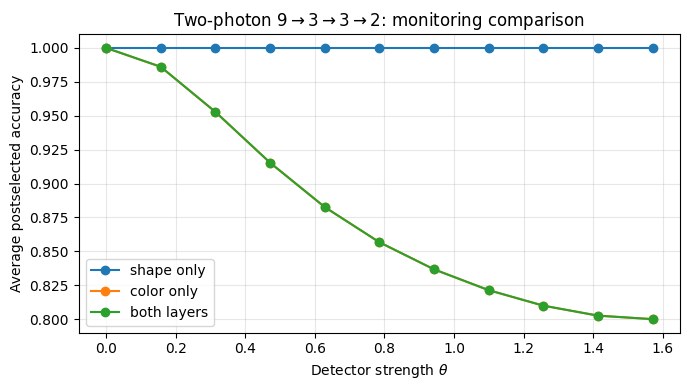

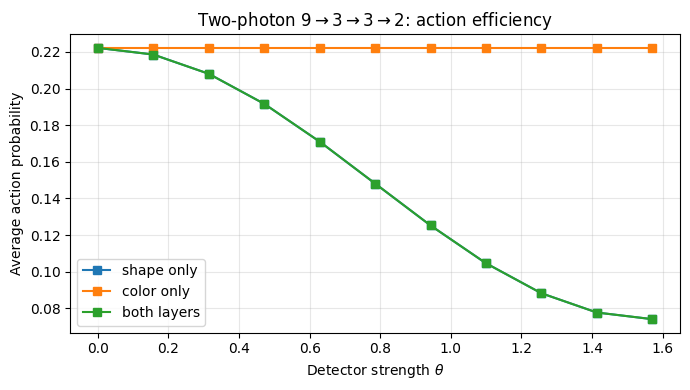

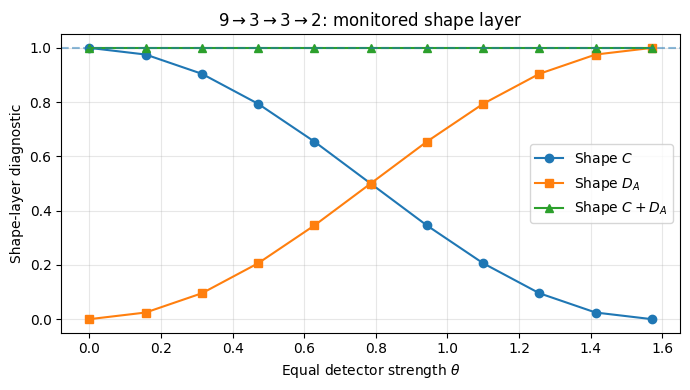

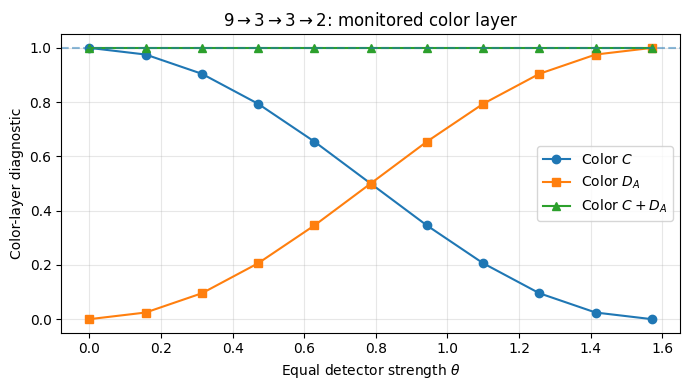

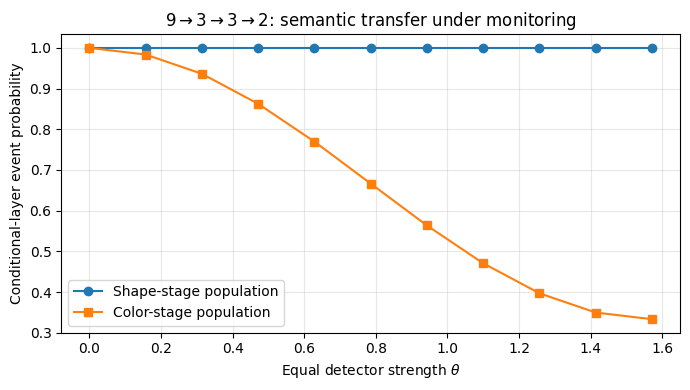

In [473]:
# ============================================================
# 9→3→3→2 task and layer-resolved diagnostic plots
# ============================================================

plt.figure(figsize=(7, 4))
for scenario in [
    "shape only",
    "color only",
    "both layers",
]:
    sub = semantic_9332_summary[
        semantic_9332_summary["scenario"]
        == scenario
    ]
    plt.plot(
        sub["theta"],
        sub["avg_correct_post"],
        marker="o",
        label=scenario,
    )
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Average postselected accuracy")
plt.title(
    r"Two-photon $9\to3\to3\to2$: monitoring comparison"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for scenario in [
    "shape only",
    "color only",
    "both layers",
]:
    sub = semantic_9332_summary[
        semantic_9332_summary["scenario"]
        == scenario
    ]
    plt.plot(
        sub["theta"],
        sub["avg_P_act"],
        marker="s",
        label=scenario,
    )
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Average action probability")
plt.title(
    r"Two-photon $9\to3\to3\to2$: action efficiency"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


semantic_9332_both = semantic_9332_summary[
    semantic_9332_summary["scenario"]
    == "both layers"
]

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both["avg_C_shape"],
    marker="o",
    label=r"Shape $C$",
)
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both["avg_D_A_shape"],
    marker="s",
    label=r"Shape $D_A$",
)
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both[
        "avg_C_plus_D_shape"
    ],
    marker="^",
    label=r"Shape $C+D_A$",
)
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel("Shape-layer diagnostic")
plt.title(
    r"$9\to3\to3\to2$: monitored shape layer"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both["avg_C_color"],
    marker="o",
    label=r"Color $C$",
)
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both["avg_D_A_color"],
    marker="s",
    label=r"Color $D_A$",
)
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both[
        "avg_C_plus_D_color"
    ],
    marker="^",
    label=r"Color $C+D_A$",
)
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel("Color-layer diagnostic")
plt.title(
    r"$9\to3\to3\to2$: monitored color layer"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both["avg_P_shape_stage"],
    marker="o",
    label="Shape-stage population",
)
plt.plot(
    semantic_9332_both["theta"],
    semantic_9332_both["avg_P_color_stage"],
    marker="s",
    label="Color-stage population",
)
plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel("Conditional-layer event probability")
plt.title(
    r"$9\to3\to3\to2$: semantic transfer under monitoring"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Averaged wave-particle inequality and ancilla readout vector

For the two monitored middle layers, define the layer-averaged wave and particle quantities by

$$
\overline{C}
=
\frac{C_{\mathrm{shape}}+C_{\mathrm{color}}}{2},
$$

$$
\overline{D}_A
=
\frac{
D_{A,\mathrm{shape}}+D_{A,\mathrm{color}}
}{2}.
$$

The averaged wave-particle inequality is the arithmetic mean of the two layer inequalities:

$$
\frac{
\left(C_{\mathrm{shape}}+D_{A,\mathrm{shape}}\right)
+
\left(C_{\mathrm{color}}+D_{A,\mathrm{color}}\right)
}{2}
\leq 1.
$$

Equivalently,

$$
\overline{C}+\overline{D}_A\leq1.
$$

Its slack is

$$
\overline{\Delta}
=
1-\left(\overline{C}+\overline{D}_A\right)
=
\frac{\Delta_{\mathrm{shape}}+\Delta_{\mathrm{color}}}{2}.
$$

We compute these quantities for every object, detector strength, and monitoring scenario in the $9\to3\to3\to2$ experiment.

The detector model initializes each ancilla in $|+\rangle$, couples it dispersively through $Z$, and measures Pauli $Y$. We therefore define the measured ancilla vector

$$
\mathbf{a}
=
\left(
\langle Y_S\rangle,
\langle Y_C\rangle,
\langle Y_T\rangle,
\langle Y_R\rangle,
\langle Y_B\rangle,
\langle Y_G\rangle
\right).
$$

The first three entries are measured after the shape-layer interaction. The last three are measured after the color-layer interaction. These are unconditional expectation values in the normalized joint state, so their magnitude also records any loss of population before the corresponding layer.

In [474]:
# ============================================================
# Per-run averaged inequality and six-ancilla readout arrays
# ============================================================

semantic_9332_sweep_df["C_average_layers"] = 0.5 * (
    semantic_9332_sweep_df["C_shape"]
    + semantic_9332_sweep_df["C_color"]
)

semantic_9332_sweep_df["D_A_average_layers"] = 0.5 * (
    semantic_9332_sweep_df["D_A_shape"]
    + semantic_9332_sweep_df["D_A_color"]
)

semantic_9332_sweep_df["C_plus_D_average_layers"] = (
    semantic_9332_sweep_df["C_average_layers"]
    + semantic_9332_sweep_df["D_A_average_layers"]
)

semantic_9332_sweep_df["average_inequality_slack"] = (
    1.0
    - semantic_9332_sweep_df[
        "C_plus_D_average_layers"
    ]
)

# Remove signed roundoff at the saturation boundary.
semantic_9332_raw_average_slack = (
    semantic_9332_sweep_df[
        "average_inequality_slack"
    ].to_numpy()
)
semantic_9332_sweep_df[
    "average_inequality_slack"
] = np.where(
    np.abs(semantic_9332_raw_average_slack) < 1e-12,
    0.0,
    semantic_9332_raw_average_slack,
)

semantic_9332_average_inequality_holds = bool(
    np.all(
        semantic_9332_sweep_df[
            "C_plus_D_average_layers"
        ].to_numpy()
        <= 1.0 + 1e-10
    )
)

semantic_9332_ancilla_labels = np.array(
    [
        "Y_shape_S",
        "Y_shape_C",
        "Y_shape_T",
        "Y_color_R",
        "Y_color_B",
        "Y_color_G",
    ]
)

# Shape:
#   (number of sweep rows, 6)
semantic_9332_ancilla_expectation_values = np.stack(
    semantic_9332_sweep_df[
        "ancilla_expectations"
    ].to_numpy()
)

for index, label in enumerate(
    semantic_9332_ancilla_labels
):
    semantic_9332_sweep_df[label] = (
        semantic_9332_ancilla_expectation_values[
            :,
            index,
        ]
    )

print(
    "Ancilla expectation array shape:",
    semantic_9332_ancilla_expectation_values.shape,
)
print(
    "Ancilla order:",
    semantic_9332_ancilla_labels.tolist(),
)
print(
    "Averaged inequality holds:",
    semantic_9332_average_inequality_holds,
)

display(
    semantic_9332_sweep_df[
        [
            "scenario",
            "theta",
            "object",
            "C_average_layers",
            "D_A_average_layers",
            "C_plus_D_average_layers",
            "average_inequality_slack",
            *semantic_9332_ancilla_labels.tolist(),
        ]
    ].head(18)
)


Ancilla expectation array shape: (297, 6)
Ancilla order: ['Y_shape_S', 'Y_shape_C', 'Y_shape_T', 'Y_color_R', 'Y_color_B', 'Y_color_G']
Averaged inequality holds: True


,scenario,theta,object,C_average_layers,D_A_average_layers,C_plus_D_average_layers,average_inequality_slack,Y_shape_S,Y_shape_C,Y_shape_T,Y_color_R,Y_color_B,Y_color_G
0,shape only,0.00000,RS,1.000000,0.000000e+00,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,shape only,0.00000,RC,1.000000,1.665335e-16,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,shape only,0.00000,RT,1.000000,1.110223e-16,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
3,shape only,0.00000,BS,1.000000,5.551115e-17,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,shape only,0.00000,BC,1.000000,5.551115e-17,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
5,shape only,0.00000,BT,1.000000,0.000000e+00,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
6,shape only,0.00000,GS,1.000000,5.551115e-17,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
7,shape only,0.00000,GC,1.000000,5.551115e-17,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
8,shape only,0.00000,GT,1.000000,0.000000e+00,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
9,shape only,0.15708,RS,0.987764,1.223587e-02,1.0,0.0,0.103006,0.103006,0.103006,0.0,0.0,0.0


In [475]:
# ============================================================
# Scenario- and theta-averaged inequalities and ancilla arrays
# ============================================================

semantic_9332_average_wp_summary = (
    semantic_9332_sweep_df
    .groupby(["scenario", "theta"])
    .agg(
        avg_C_layers=("C_average_layers", "mean"),
        avg_D_A_layers=(
            "D_A_average_layers",
            "mean",
        ),
        avg_C_plus_D_layers=(
            "C_plus_D_average_layers",
            "mean",
        ),
        avg_inequality_slack=(
            "average_inequality_slack",
            "mean",
        ),
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
    )
    .reset_index()
)

semantic_9332_ancilla_summary_rows = []

for (scenario, theta), group in (
    semantic_9332_sweep_df
    .groupby(["scenario", "theta"])
):
    expectation_matrix = np.stack(
        group["ancilla_expectations"].to_numpy()
    )

    semantic_9332_ancilla_summary_rows.append({
        "scenario": scenario,
        "theta": float(theta),
        "mean_ancilla_expectations": (
            expectation_matrix.mean(axis=0)
        ),
        "mean_abs_ancilla_expectations": (
            np.abs(expectation_matrix).mean(axis=0)
        ),
    })

semantic_9332_ancilla_expectation_summary = (
    pd.DataFrame(
        semantic_9332_ancilla_summary_rows
    )
)

# Shape:
#   (number of scenario-theta points, 6)
semantic_9332_mean_ancilla_expectation_array = (
    np.stack(
        semantic_9332_ancilla_expectation_summary[
            "mean_ancilla_expectations"
        ].to_numpy()
    )
)

display(semantic_9332_average_wp_summary.head())
display(
    semantic_9332_ancilla_expectation_summary.head()
)

print(
    "Mean ancilla expectation array shape:",
    semantic_9332_mean_ancilla_expectation_array.shape,
)


,scenario,theta,avg_C_layers,avg_D_A_layers,avg_C_plus_D_layers,avg_inequality_slack,avg_correct_post,avg_P_act
0,both layers,0.000000,1.000000,5.551115e-17,1.0,0.0,1.000000,0.222222
1,both layers,0.157080,0.975528,2.447174e-02,1.0,0.0,0.986052,0.218597
2,both layers,0.314159,0.904508,9.549150e-02,1.0,0.0,0.952787,0.208075
3,both layers,0.471239,0.793893,2.061074e-01,1.0,0.0,0.915356,0.191688
4,both layers,0.628319,0.654508,3.454915e-01,1.0,0.0,0.882639,0.171038


,scenario,theta,mean_ancilla_expectations,mean_abs_ancilla_expectations
0,both layers,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,both layers,0.157080,"[0.10300566479164908, 0.1030056647916491, 0.10...","[0.10300566479164908, 0.1030056647916491, 0.10..."
2,both layers,0.314159,"[0.1959284174308242, 0.19592841743082418, 0.19...","[0.1959284174308242, 0.19592841743082418, 0.19..."
3,both layers,0.471239,"[0.26967233145831543, 0.26967233145831554, 0.2...","[0.26967233145831543, 0.26967233145831554, 0.2..."
4,both layers,0.628319,"[0.317018838765051, 0.3170188387650509, 0.3170...","[0.317018838765051, 0.3170188387650509, 0.3170..."


Mean ancilla expectation array shape: (33, 6)


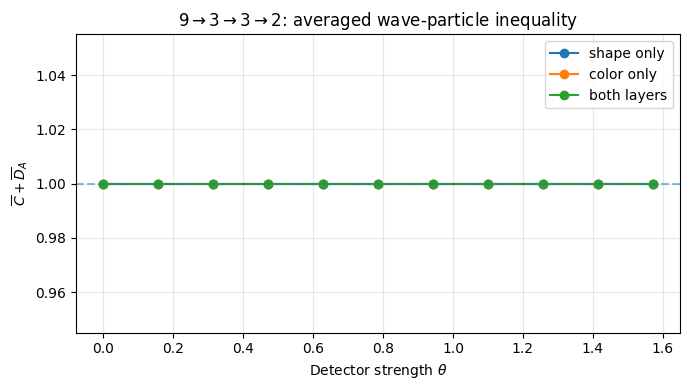

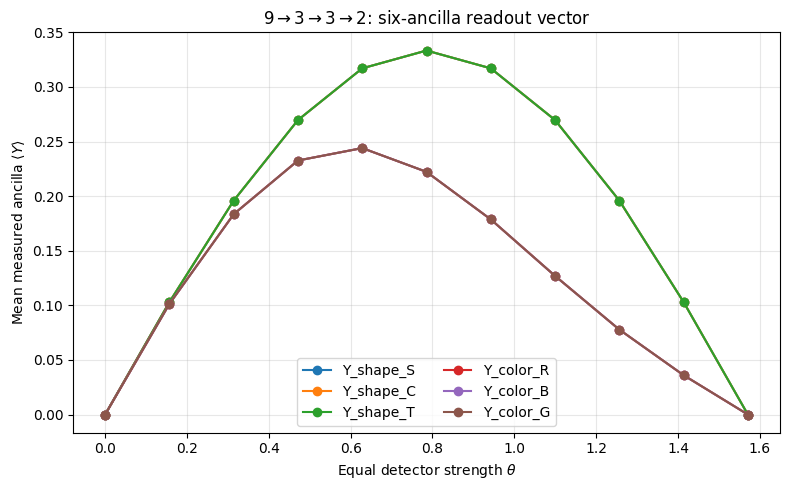

In [476]:
# ============================================================
# Averaged inequality and measured-ancilla plots
# ============================================================

plt.figure(figsize=(7, 4))

for scenario in [
    "shape only",
    "color only",
    "both layers",
]:
    sub = semantic_9332_average_wp_summary[
        semantic_9332_average_wp_summary[
            "scenario"
        ]
        == scenario
    ]

    plt.plot(
        sub["theta"],
        sub["avg_C_plus_D_layers"],
        marker="o",
        label=scenario,
    )

plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel(
    r"$\overline{C}+\overline{D}_A$"
)
plt.title(
    r"$9\to3\to3\to2$: averaged wave-particle inequality"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


semantic_9332_both_ancilla_summary = (
    semantic_9332_ancilla_expectation_summary[
        semantic_9332_ancilla_expectation_summary[
            "scenario"
        ]
        == "both layers"
    ]
)

semantic_9332_both_ancilla_array = np.stack(
    semantic_9332_both_ancilla_summary[
        "mean_ancilla_expectations"
    ].to_numpy()
)

plt.figure(figsize=(8, 5))

for index, label in enumerate(
    semantic_9332_ancilla_labels
):
    plt.plot(
        semantic_9332_both_ancilla_summary["theta"],
        semantic_9332_both_ancilla_array[:, index],
        marker="o",
        label=label,
    )

plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel(r"Mean measured ancilla $\langle Y\rangle$")
plt.title(
    r"$9\to3\to3\to2$: six-ancilla readout vector"
)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


## Five-photon Computer Maintenance environment

We now adapt the Computer Maintenance environment from the original MEPS study. The active environment contains:

- 10 symptoms;
- 5 causes;
- 5 components;
- 4 repair actions;
- 44 symptom-pair scenarios.

Each scenario specifies

$$
\left(
\mathrm{symptoms},
\mathrm{causes},
\mathrm{components},
\mathrm{fixes}
\right).
$$

The original MEPS agent used one hidden layer whose clips jointly encoded causes and components. Here we separate that representation into two intermediate photonic layers:

$$
1
\to
5\ \mathrm{cause\ modes}
\to
5\ \mathrm{component\ modes}
\to
4\ \mathrm{fix\ modes}.
$$

We begin with five photons in one input mode. The first semantic transition moves two photons into the cause layer and leaves three photons in the input mode. The second transition moves the remaining three photons into the component layer. The final semantic state therefore contains

$$
N_{\mathrm{cause}}=2,
\qquad
N_{\mathrm{component}}=3,
\qquad
N_{\mathrm{total}}=5.
$$

This split matches the active scenario table: a scenario contains at most two causes and at most three components. A selected category set is represented by a bosonic condensate over its modes. For example, two selected causes $c_1,c_2$ use

$$
\frac{1}{\sqrt{2!}}
\left(
\frac{
a_{c_1}^{\dagger}+a_{c_2}^{\dagger}
}{\sqrt{2}}
\right)^2
|0\rangle.
$$

Five cause ancillas and five component ancillas monitor the two semantic layers. Rather than constructing the explicit $2^{10}$-dimensional ancilla register, we evaluate the detector overlaps and Pauli-$Y$ expectations analytically. This gives the same reduced photonic state as the dispersive interaction

$$
\exp\left[
-i\theta
\sum_m n_m\otimes Z_m
\right]
$$

without forming a joint state with nearly 12 million amplitudes.

In [477]:
# ============================================================
# Original Computer Maintenance labels and 44 active scenarios
# ============================================================

import math
from collections import Counter

semantic_cm_SYMPTOMS = [
    "PC overheating",
    "files disappearing",
    "visible markings on components",
    "unexpected shutdowns",
    "slow performance",
    "old hardware",
    "strange noises",
    "software glitches",
    "blue screen",
    "no internet",
]

semantic_cm_CAUSES = [
    "physical damage",
    "software damage",
    "malware",
    "faulty",
    "not connected",
]

semantic_cm_COMPONENTS = [
    "CPU",
    "SSD",
    "MoBo",
    "PSU",
    "OS",
]

semantic_cm_ACTIONS = [
    "replace components",
    "install missing software",
    "cooldown computer",
    "run antivirus",
]

# Each tuple is:
#   (symptoms, causes, components, repair actions)
semantic_cm_SCENARIOS = [
    (("PC overheating", "files disappearing"), ("software damage",), ("SSD", "PSU"), ("install missing software", "cooldown computer")),
    (("PC overheating", "visible markings on components"), ("physical damage",), ("CPU", "MoBo"), ("replace components", "cooldown computer")),
    (("PC overheating", "unexpected shutdowns"), ("physical damage",), ("CPU", "MoBo", "PSU"), ("replace components", "cooldown computer")),
    (("PC overheating", "slow performance"), ("malware",), ("CPU", "MoBo", "OS"), ("cooldown computer", "run antivirus")),
    (("PC overheating", "old hardware"), ("faulty",), ("PSU",), ("replace components",)),
    (("PC overheating", "strange noises"), ("physical damage",), ("CPU", "MoBo", "PSU"), ("replace components", "cooldown computer")),
    (("PC overheating", "software glitches"), ("software damage",), ("CPU", "OS"), ("install missing software", "cooldown computer")),
    (("PC overheating", "blue screen"), ("software damage",), ("CPU", "OS"), ("install missing software", "cooldown computer")),
    (("PC overheating", "no internet"), ("malware",), ("CPU", "MoBo"), ("cooldown computer", "run antivirus")),
    (("files disappearing", "visible markings on components"), ("physical damage", "software damage"), ("SSD", "MoBo"), ("replace components", "install missing software")),
    (("files disappearing", "unexpected shutdowns"), ("malware",), ("SSD", "MoBo", "OS"), ("run antivirus",)),
    (("files disappearing", "slow performance"), ("malware", "faulty"), ("CPU",), ("replace components", "run antivirus")),
    (("files disappearing", "old hardware"), ("faulty",), ("SSD",), ("replace components",)),
    (("files disappearing", "strange noises"), ("physical damage",), ("SSD",), ("replace components",)),
    (("files disappearing", "software glitches"), ("malware",), ("OS",), ("run antivirus",)),
    (("files disappearing", "blue screen"), ("software damage", "faulty"), ("CPU", "SSD"), ("replace components", "install missing software")),
    (("files disappearing", "no internet"), ("software damage",), ("SSD", "OS"), ("install missing software",)),
    (("visible markings on components", "unexpected shutdowns"), ("physical damage",), ("PSU",), ("replace components",)),
    (("visible markings on components", "slow performance"), ("physical damage",), ("CPU", "OS"), ("replace components",)),
    (("visible markings on components", "old hardware"), ("physical damage", "faulty"), ("CPU", "SSD", "MoBo"), ("replace components",)),
    (("visible markings on components", "strange noises"), ("physical damage", "faulty"), ("CPU", "PSU"), ("replace components",)),
    (("visible markings on components", "software glitches"), ("malware", "faulty"), ("CPU", "OS"), ("replace components", "run antivirus")),
    (("visible markings on components", "blue screen"), ("software damage", "faulty"), ("CPU", "SSD"), ("replace components", "install missing software")),
    (("visible markings on components", "no internet"), ("physical damage", "software damage"), ("SSD", "PSU"), ("replace components", "install missing software")),
    (("unexpected shutdowns", "slow performance"), ("physical damage", "software damage"), ("CPU", "PSU"), ("replace components", "install missing software")),
    (("unexpected shutdowns", "old hardware"), ("faulty",), ("CPU",), ("replace components",)),
    (("unexpected shutdowns", "strange noises"), ("physical damage",), ("MoBo", "PSU"), ("replace components",)),
    (("unexpected shutdowns", "software glitches"), ("malware",), ("MoBo", "OS"), ("run antivirus",)),
    (("unexpected shutdowns", "blue screen"), ("physical damage", "faulty"), ("CPU", "MoBo"), ("replace components",)),
    (("unexpected shutdowns", "no internet"), ("malware",), ("OS",), ("run antivirus",)),
    (("slow performance", "old hardware"), ("faulty",), ("CPU", "PSU"), ("replace components",)),
    (("slow performance", "strange noises"), ("physical damage",), ("CPU", "SSD", "PSU"), ("replace components",)),
    (("slow performance", "software glitches"), ("software damage", "malware"), ("CPU", "MoBo", "OS"), ("install missing software", "run antivirus")),
    (("slow performance", "blue screen"), ("physical damage", "software damage"), ("CPU", "MoBo", "OS"), ("replace components", "install missing software")),
    (("slow performance", "no internet"), ("physical damage", "software damage"), ("CPU", "MoBo", "OS"), ("replace components", "install missing software")),
    (("old hardware", "strange noises"), ("physical damage", "faulty"), ("CPU", "SSD", "PSU"), ("replace components",)),
    (("old hardware", "software glitches"), ("software damage", "faulty"), ("CPU", "PSU", "OS"), ("replace components", "install missing software")),
    (("old hardware", "blue screen"), ("faulty",), ("MoBo",), ("replace components",)),
    (("old hardware", "no internet"), ("software damage", "faulty"), ("CPU", "OS"), ("replace components", "install missing software")),
    (("strange noises", "software glitches"), ("physical damage", "software damage"), ("SSD", "MoBo"), ("replace components", "install missing software")),
    (("strange noises", "blue screen"), ("physical damage",), ("MoBo", "PSU"), ("replace components",)),
    (("strange noises", "no internet"), ("physical damage", "software damage"), ("CPU", "OS"), ("replace components", "install missing software")),
    (("software glitches", "blue screen"), ("physical damage", "malware"), ("MoBo", "OS"), ("replace components", "run antivirus")),
    (("software glitches", "no internet"), ("software damage", "malware"), ("SSD", "OS"), ("install missing software", "run antivirus")),
]

semantic_cm_scenario_df = pd.DataFrame(
    [
        {
            "scenario": index,
            "symptoms": symptoms,
            "causes": causes,
            "components": components,
            "actions": actions,
            "num_causes": len(causes),
            "num_components": len(components),
            "num_actions": len(actions),
        }
        for index, (
            symptoms,
            causes,
            components,
            actions,
        ) in enumerate(semantic_cm_SCENARIOS)
    ]
)

print("Number of scenarios:", len(semantic_cm_SCENARIOS))
print(
    "Cause-count distribution:",
    Counter(semantic_cm_scenario_df["num_causes"]),
)
print(
    "Component-count distribution:",
    Counter(semantic_cm_scenario_df["num_components"]),
)
display(semantic_cm_scenario_df)


Number of scenarios: 44
Cause-count distribution: Counter({1: 24, 2: 20})
Component-count distribution: Counter({2: 24, 3: 11, 1: 9})


,scenario,symptoms,causes,components,actions,num_causes,num_components,num_actions
0,0,"(PC overheating, files disappearing)","(software damage,)","(SSD, PSU)","(install missing software, cooldown computer)",1,2,2
1,1,"(PC overheating, visible markings on components)","(physical damage,)","(CPU, MoBo)","(replace components, cooldown computer)",1,2,2
2,2,"(PC overheating, unexpected shutdowns)","(physical damage,)","(CPU, MoBo, PSU)","(replace components, cooldown computer)",1,3,2
3,3,"(PC overheating, slow performance)","(malware,)","(CPU, MoBo, OS)","(cooldown computer, run antivirus)",1,3,2
4,4,"(PC overheating, old hardware)","(faulty,)","(PSU,)","(replace components,)",1,1,1
5,5,"(PC overheating, strange noises)","(physical damage,)","(CPU, MoBo, PSU)","(replace components, cooldown computer)",1,3,2
6,6,"(PC overheating, software glitches)","(software damage,)","(CPU, OS)","(install missing software, cooldown computer)",1,2,2
7,7,"(PC overheating, blue screen)","(software damage,)","(CPU, OS)","(install missing software, cooldown computer)",1,2,2
8,8,"(PC overheating, no internet)","(malware,)","(CPU, MoBo)","(cooldown computer, run antivirus)",1,2,2
9,9,"(files disappearing, visible markings on compo...","(physical damage, software damage)","(SSD, MoBo)","(replace components, install missing software)",2,2,2


### Five-photon semantic encoding

The cause layer carries two photons across five modes. Its local Hilbert-space dimension is

$$
\binom{2+5-1}{2}=15.
$$

The component layer carries three photons across five modes, with dimension

$$
\binom{3+5-1}{3}=35.
$$

The joint cause-component semantic space therefore has dimension

$$
15\times35=525.
$$

For a category set $S$, define the normalized single-particle mode

$$
b_S^\dagger
=
\frac{1}{\sqrt{|S|}}
\sum_{j\in S} a_j^\dagger.
$$

The $N$-photon category state is the condensate

$$
|\Phi_S^{(N)}\rangle
=
\frac{(b_S^\dagger)^N}{\sqrt{N!}}
|0\rangle.
$$

This encoding gives coherent occupation paths whenever a scenario contains more than one cause or component. Those paths are the quantities resolved by the ancillas.

In [478]:
# ============================================================
# Local five-mode bosonic bases and condensate states
# ============================================================

semantic_cm_N_CAUSE = 2
semantic_cm_N_COMPONENT = 3
semantic_cm_N_TOTAL = 5

semantic_cm_cause_basis = fixedN_basis(
    m=len(semantic_cm_CAUSES),
    N=semantic_cm_N_CAUSE,
)
semantic_cm_component_basis = fixedN_basis(
    m=len(semantic_cm_COMPONENTS),
    N=semantic_cm_N_COMPONENT,
)

semantic_cm_cause_basis_index = {
    occupation: index
    for index, occupation in enumerate(
        semantic_cm_cause_basis
    )
}
semantic_cm_component_basis_index = {
    occupation: index
    for index, occupation in enumerate(
        semantic_cm_component_basis
    )
}


def semantic_cm_condensate_state(
    selected_labels,
    label_order,
    photon_number,
    basis,
):
    """
    N-photon condensate over the selected category modes.
    """
    single_particle = np.zeros(
        len(label_order),
        dtype=complex,
    )

    for label in selected_labels:
        single_particle[label_order.index(label)] = (
            1 / np.sqrt(len(selected_labels))
        )

    amplitudes = np.zeros(len(basis), dtype=complex)

    for index, occupation in enumerate(basis):
        coefficient = np.sqrt(
            math.factorial(photon_number)
        )

        for number, amplitude in zip(
            occupation,
            single_particle,
        ):
            coefficient *= (
                amplitude**number
                / np.sqrt(math.factorial(number))
            )

        amplitudes[index] = coefficient

    norm = np.linalg.norm(amplitudes)

    if norm <= 1e-14:
        raise ValueError(
            "The selected category set produced a zero state."
        )

    return amplitudes / norm


semantic_cm_cause_states = {}
semantic_cm_component_states = {}
semantic_cm_joint_states = {}

for scenario_index, scenario in enumerate(
    semantic_cm_SCENARIOS
):
    _, causes, components, _ = scenario

    cause_state = semantic_cm_condensate_state(
        selected_labels=causes,
        label_order=semantic_cm_CAUSES,
        photon_number=semantic_cm_N_CAUSE,
        basis=semantic_cm_cause_basis,
    )
    component_state = semantic_cm_condensate_state(
        selected_labels=components,
        label_order=semantic_cm_COMPONENTS,
        photon_number=semantic_cm_N_COMPONENT,
        basis=semantic_cm_component_basis,
    )

    semantic_cm_cause_states[scenario_index] = cause_state
    semantic_cm_component_states[
        scenario_index
    ] = component_state
    semantic_cm_joint_states[scenario_index] = np.kron(
        cause_state,
        component_state,
    )

print(
    "Cause-layer dimension:",
    len(semantic_cm_cause_basis),
)
print(
    "Component-layer dimension:",
    len(semantic_cm_component_basis),
)
print(
    "Joint semantic dimension:",
    len(semantic_cm_cause_basis)
    * len(semantic_cm_component_basis),
)


Cause-layer dimension: 15
Component-layer dimension: 35
Joint semantic dimension: 525


### Staged multi-excitation transitions

The scenario label selects the semantic transitions, as in the percept-dependent PRA-style constructions above. The first transition is a two-excitation process,

$$
|5\rangle_{\mathrm{input}}
\longrightarrow
|3\rangle_{\mathrm{input}}
\otimes
|\Phi_{\mathrm{cause}}^{(2)}\rangle.
$$

The second is a three-excitation process,

$$
|3\rangle_{\mathrm{input}}
\otimes
|\Phi_{\mathrm{cause}}^{(2)}\rangle
\longrightarrow
|\Phi_{\mathrm{cause}}^{(2)}\rangle
\otimes
|\Phi_{\mathrm{component}}^{(3)}\rangle.
$$

The final semantic state keeps both layers occupied. This matters because the repair decision in the original environment depends on the combined cause-component explanation. In the active scenario table, 37 distinct cause-component explanations map consistently to nine distinct repair sets.

In [479]:
# ============================================================
# Unique explanations and orthogonal five-photon repair states
# ============================================================

def semantic_cm_ordered_tuple(labels, order):
    return tuple(
        label
        for label in order
        if label in labels
    )


semantic_cm_explanation_keys = []
semantic_cm_explanation_states = []
semantic_cm_explanation_actions = []
semantic_cm_scenario_to_explanation = {}

for scenario_index, scenario in enumerate(
    semantic_cm_SCENARIOS
):
    _, causes, components, actions = scenario

    key = (
        semantic_cm_ordered_tuple(
            causes,
            semantic_cm_CAUSES,
        ),
        semantic_cm_ordered_tuple(
            components,
            semantic_cm_COMPONENTS,
        ),
    )
    ordered_actions = semantic_cm_ordered_tuple(
        actions,
        semantic_cm_ACTIONS,
    )

    if key not in semantic_cm_explanation_keys:
        semantic_cm_explanation_keys.append(key)
        semantic_cm_explanation_states.append(
            semantic_cm_joint_states[scenario_index]
        )
        semantic_cm_explanation_actions.append(
            ordered_actions
        )

    semantic_cm_scenario_to_explanation[
        scenario_index
    ] = semantic_cm_explanation_keys.index(key)

semantic_cm_ACTION_CLASSES = []

for actions in semantic_cm_explanation_actions:
    if actions not in semantic_cm_ACTION_CLASSES:
        semantic_cm_ACTION_CLASSES.append(actions)


def semantic_cm_action_occupation(action_set):
    """
    Orthogonal five-photon output code over four repair modes.

    One repair receives all five photons. Two repairs receive three
    and two photons in the global repair-mode order.
    """
    occupation = [0] * len(semantic_cm_ACTIONS)
    selected_indices = [
        semantic_cm_ACTIONS.index(action)
        for action in action_set
    ]

    if len(selected_indices) == 1:
        occupation[selected_indices[0]] = 5
    elif len(selected_indices) == 2:
        occupation[selected_indices[0]] = 3
        occupation[selected_indices[1]] = 2
    else:
        raise ValueError(
            "The active environment uses one or two repairs."
        )

    return tuple(occupation)


semantic_cm_action_occupations = {
    action_class: semantic_cm_action_occupation(
        action_class
    )
    for action_class in semantic_cm_ACTION_CLASSES
}

semantic_cm_action_table = pd.DataFrame([
    {
        "action_class": index,
        "repairs": action_class,
        "five_photon_output": (
            semantic_cm_action_occupations[action_class]
        ),
    }
    for index, action_class in enumerate(
        semantic_cm_ACTION_CLASSES
    )
])

print(
    "Unique cause-component explanations:",
    len(semantic_cm_explanation_keys),
)
print(
    "Distinct repair sets:",
    len(semantic_cm_ACTION_CLASSES),
)
display(semantic_cm_action_table)


Unique cause-component explanations: 37
Distinct repair sets: 9


,action_class,repairs,five_photon_output
0,0,"(install missing software, cooldown computer)","(0, 3, 2, 0)"
1,1,"(replace components, cooldown computer)","(3, 0, 2, 0)"
2,2,"(cooldown computer, run antivirus)","(0, 0, 3, 2)"
3,3,"(replace components,)","(5, 0, 0, 0)"
4,4,"(replace components, install missing software)","(3, 2, 0, 0)"
5,5,"(run antivirus,)","(0, 0, 0, 5)"
6,6,"(replace components, run antivirus)","(3, 0, 0, 2)"
7,7,"(install missing software,)","(0, 5, 0, 0)"
8,8,"(install missing software, run antivirus)","(0, 3, 0, 2)"


### Common postselected repair readout

The 37 distinct semantic explanations are linearly independent in the 525-dimensional joint layer. Let the columns of $S$ be those explanation states. We construct the dual states

$$
D=S(S^\dagger S)^{-1},
$$

which satisfy

$$
D^\dagger S=I.
$$

For each repair class $a$, the corresponding bright vector is the sum of the dual states assigned to that class. It has zero overlap with every explanation belonging to a different repair set.

The nine bright vectors form a subnormalized measurement. We scale them by the largest eigenvalue of their frame operator so that

$$
\sum_a |w_a\rangle\langle w_a|\leq I.
$$

The raw repair-event scores are

$$
p_a
=
\operatorname{Tr}
\left[
\rho_{\mathrm{cause,component}}
|w_a\rangle\langle w_a|
\right].
$$

Their sum is the action probability, while normalization over the nine repair outcomes gives the postselected repair probabilities.

In [480]:
# ============================================================
# Dual-frame readout for the nine repair classes
# ============================================================

semantic_cm_S = np.column_stack(
    semantic_cm_explanation_states
)
semantic_cm_gram = (
    semantic_cm_S.conj().T @ semantic_cm_S
)
semantic_cm_dual = (
    semantic_cm_S @ np.linalg.inv(semantic_cm_gram)
)

semantic_cm_dual_check = (
    semantic_cm_dual.conj().T @ semantic_cm_S
)

semantic_cm_readout_vectors = []

for action_class in semantic_cm_ACTION_CLASSES:
    explanation_indices = [
        index
        for index, actions in enumerate(
            semantic_cm_explanation_actions
        )
        if actions == action_class
    ]

    vector = np.sum(
        semantic_cm_dual[:, explanation_indices],
        axis=1,
    )
    semantic_cm_readout_vectors.append(vector)

semantic_cm_W_unscaled = np.column_stack(
    semantic_cm_readout_vectors
)
semantic_cm_frame_gram = (
    semantic_cm_W_unscaled.conj().T
    @ semantic_cm_W_unscaled
)
semantic_cm_frame_lambda_max = float(
    np.max(
        np.linalg.eigvalsh(
            semantic_cm_frame_gram
        )
    )
)

semantic_cm_W = (
    semantic_cm_W_unscaled
    / np.sqrt(semantic_cm_frame_lambda_max)
)

semantic_cm_readout_overlap = (
    semantic_cm_W.conj().T @ semantic_cm_S
)

print(
    "Maximum dual-basis error:",
    np.max(
        np.abs(
            semantic_cm_dual_check
            - np.eye(
                len(semantic_cm_explanation_keys)
            )
        )
    ),
)
print(
    "Readout frame largest eigenvalue after scaling:",
    np.max(
        np.linalg.eigvalsh(
            semantic_cm_W.conj().T
            @ semantic_cm_W
        )
    ),
)


Maximum dual-basis error: 6.661338147750939e-16
Readout frame largest eigenvalue after scaling: 1.0000000000000009


### Analytic monitoring of the cause and component layers

For a local occupation configuration $\mu$, the five ancillas acquire the product state

$$
|A_\mu(\theta)\rangle
=
\bigotimes_{m=1}^{5}
e^{-i\theta n_m(\mu)Z}
|+\rangle.
$$

The overlap between detector states is

$$
\left|
\langle A_\nu(\theta)|A_\mu(\theta)\rangle
\right|
=
\prod_{m=1}^{5}
\left|
\cos\left[
\theta
\left(
n_m(\mu)-n_m(\nu)
\right)
\right]
\right|.
$$

The signed detector coherence

$$
\prod_{m=1}^{5}
\cos\left[
	heta
\left(
n_m(\mu)-n_m(
u)

ight)

ight]
$$

multiplies each off-diagonal photonic density-matrix element. Its absolute value is the detector-state fidelity used in the information term $D_A$.

The measured ancilla array contains ten Pauli-$Y$ expectations:

$$
\mathbf{a}_{\mathrm{CM}}
=
\left(
\langle Y_{\mathrm{cause},1}\rangle,\ldots,
\langle Y_{\mathrm{cause},5}\rangle,
\langle Y_{\mathrm{component},1}\rangle,\ldots,
\langle Y_{\mathrm{component},5}\rangle
\right).
$$

For one monitored mode,

$$
\langle Y_m\rangle
=
\sum_\mu p_\mu
\sin\left(2\theta n_m(\mu)\right).
$$

In [481]:
# ============================================================
# Exact local dephasing, wave-particle terms, and ancilla readout
# ============================================================

def semantic_cm_monitored_layer(
    amplitudes,
    basis,
    theta,
    p_tol=1e-14,
):
    probabilities = np.abs(amplitudes) ** 2
    active = np.flatnonzero(probabilities > p_tol)
    active_amplitudes = amplitudes[active]
    active_probabilities = probabilities[active]
    active_occupations = np.array(
        [basis[index] for index in active],
        dtype=int,
    )

    differences = (
        active_occupations[:, None, :]
        - active_occupations[None, :, :]
    )
    detector_coherence = np.prod(
        np.cos(theta * differences),
        axis=2,
    )
    detector_fidelity = np.abs(detector_coherence)

    rho_active = (
        np.outer(
            active_amplitudes,
            active_amplitudes.conj(),
        )
        * detector_coherence
    )

    R = len(active)

    if R <= 1:
        C = 0.0
        D_A = 0.0
    else:
        off_diagonal = ~np.eye(R, dtype=bool)
        C = float(
            np.sum(
                np.abs(rho_active[off_diagonal])
            )
            / (R - 1)
        )
        weighted_overlap = (
            np.sqrt(
                active_probabilities[:, None]
                * active_probabilities[None, :]
            )
            * detector_fidelity
        )
        D_A = float(
            1.0
            - np.sum(
                weighted_overlap[off_diagonal]
            )
            / (R - 1)
        )

    rho_full = np.zeros(
        (len(basis), len(basis)),
        dtype=complex,
    )
    rho_full[np.ix_(active, active)] = rho_active

    ancilla_Y = np.sum(
        active_probabilities[:, None]
        * np.sin(
            2
            * theta
            * active_occupations
        ),
        axis=0,
    )

    semantic_fidelity = float(
        np.real(
            np.vdot(
                amplitudes,
                rho_full @ amplitudes,
            )
        )
    )

    return {
        "rho": rho_full,
        "semantic_fidelity": semantic_fidelity,
        "C": C,
        "D_A": D_A,
        "C_plus_D_A": float(C + D_A),
        "slack": float(1.0 - C - D_A),
        "active_configurations": R,
        "ancilla_Y": ancilla_Y.astype(float),
    }


def semantic_cm_readout_scores(
    rho_cause,
    rho_component,
):
    """
    Evaluate w†(rho_cause ⊗ rho_component)w without building
    the 525×525 Kronecker density matrix.
    """
    cause_dim = len(semantic_cm_cause_basis)
    component_dim = len(
        semantic_cm_component_basis
    )
    scores = []

    for class_index in range(
        len(semantic_cm_ACTION_CLASSES)
    ):
        W_class = semantic_cm_W[
            :,
            class_index,
        ].reshape(
            cause_dim,
            component_dim,
        )

        transformed = (
            rho_cause
            @ W_class
            @ rho_component.T
        )
        score = np.vdot(
            W_class,
            transformed,
        )
        scores.append(
            max(0.0, float(np.real(score)))
        )

    return np.array(scores, dtype=float)


### Relation to the original rewards

The original environment returned two rewards: a hidden-layer hypothesis reward and an action-layer plausibility reward. This photonic analysis does not retrain the PS weights episode by episode. Instead, it evaluates their semantic counterparts:

- `cause_semantic_fidelity` and `component_semantic_fidelity` measure whether the two hidden explanations remain in their intended states;
- `explanation_fidelity` is their joint product;
- `correct_post` measures the probability assigned to the scenario's exact repair set after postselection;
- `P_act` records the probability that the subnormalized repair measurement produces an action event.

The cause-component pair determines the same repair set throughout the active scenario table, so the common repair readout also tests the plausibility of the complete explanation.

In [482]:
# ============================================================
# Unmonitored five-photon Computer Maintenance classifier
# ============================================================

semantic_cm_baseline_rows = []

for scenario_index, scenario in enumerate(
    semantic_cm_SCENARIOS
):
    explanation_index = (
        semantic_cm_scenario_to_explanation[
            scenario_index
        ]
    )
    correct_actions = (
        semantic_cm_explanation_actions[
            explanation_index
        ]
    )
    correct_class = semantic_cm_ACTION_CLASSES.index(
        correct_actions
    )

    cause_state = semantic_cm_cause_states[
        scenario_index
    ]
    component_state = semantic_cm_component_states[
        scenario_index
    ]

    scores = semantic_cm_readout_scores(
        np.outer(
            cause_state,
            cause_state.conj(),
        ),
        np.outer(
            component_state,
            component_state.conj(),
        ),
    )
    action_probability = float(np.sum(scores))
    postselected = scores / action_probability

    semantic_cm_baseline_rows.append({
        "scenario": scenario_index,
        "symptoms": scenario[0],
        "causes": scenario[1],
        "components": scenario[2],
        "correct_repairs": correct_actions,
        "correct_action_class": correct_class,
        "P_act": action_probability,
        "correct_post": float(
            postselected[correct_class]
        ),
        "predicted_action_class": int(
            np.argmax(postselected)
        ),
    })

semantic_cm_baseline_df = pd.DataFrame(
    semantic_cm_baseline_rows
)

display(semantic_cm_baseline_df)
print(
    "Minimum unmonitored postselected accuracy:",
    semantic_cm_baseline_df["correct_post"].min(),
)


,scenario,symptoms,causes,components,correct_repairs,correct_action_class,P_act,correct_post,predicted_action_class
0,0,"(PC overheating, files disappearing)","(software damage,)","(SSD, PSU)","(install missing software, cooldown computer)",0,0.073089,1.0,0
1,1,"(PC overheating, visible markings on components)","(physical damage,)","(CPU, MoBo)","(replace components, cooldown computer)",1,0.073089,1.0,1
2,2,"(PC overheating, unexpected shutdowns)","(physical damage,)","(CPU, MoBo, PSU)","(replace components, cooldown computer)",1,0.073089,1.0,1
3,3,"(PC overheating, slow performance)","(malware,)","(CPU, MoBo, OS)","(cooldown computer, run antivirus)",2,0.073089,1.0,2
4,4,"(PC overheating, old hardware)","(faulty,)","(PSU,)","(replace components,)",3,0.073089,1.0,3
5,5,"(PC overheating, strange noises)","(physical damage,)","(CPU, MoBo, PSU)","(replace components, cooldown computer)",1,0.073089,1.0,1
6,6,"(PC overheating, software glitches)","(software damage,)","(CPU, OS)","(install missing software, cooldown computer)",0,0.073089,1.0,0
7,7,"(PC overheating, blue screen)","(software damage,)","(CPU, OS)","(install missing software, cooldown computer)",0,0.073089,1.0,0
8,8,"(PC overheating, no internet)","(malware,)","(CPU, MoBo)","(cooldown computer, run antivirus)",2,0.073089,1.0,2
9,9,"(files disappearing, visible markings on compo...","(physical damage, software damage)","(SSD, MoBo)","(replace components, install missing software)",4,0.073089,1.0,4


Minimum unmonitored postselected accuracy: 1.0


In [483]:
# ============================================================
# Cause-only, component-only, and joint monitoring sweeps
# ============================================================

semantic_cm_theta_values = np.linspace(
    0,
    np.pi / 2,
    11,
)

semantic_cm_sweep_rows = []

for monitoring_case in [
    "cause only",
    "component only",
    "both layers",
]:
    for theta in semantic_cm_theta_values:
        if monitoring_case == "cause only":
            theta_cause = float(theta)
            theta_component = 0.0
        elif monitoring_case == "component only":
            theta_cause = 0.0
            theta_component = float(theta)
        else:
            theta_cause = float(theta)
            theta_component = float(theta)

        for scenario_index, scenario in enumerate(
            semantic_cm_SCENARIOS
        ):
            cause_diagnostic = (
                semantic_cm_monitored_layer(
                    semantic_cm_cause_states[
                        scenario_index
                    ],
                    semantic_cm_cause_basis,
                    theta_cause,
                )
            )
            component_diagnostic = (
                semantic_cm_monitored_layer(
                    semantic_cm_component_states[
                        scenario_index
                    ],
                    semantic_cm_component_basis,
                    theta_component,
                )
            )

            scores = semantic_cm_readout_scores(
                cause_diagnostic["rho"],
                component_diagnostic["rho"],
            )
            P_act = float(np.sum(scores))
            postselected = scores / P_act

            explanation_index = (
                semantic_cm_scenario_to_explanation[
                    scenario_index
                ]
            )
            correct_actions = (
                semantic_cm_explanation_actions[
                    explanation_index
                ]
            )
            correct_class = (
                semantic_cm_ACTION_CLASSES.index(
                    correct_actions
                )
            )

            C_average = 0.5 * (
                cause_diagnostic["C"]
                + component_diagnostic["C"]
            )
            D_A_average = 0.5 * (
                cause_diagnostic["D_A"]
                + component_diagnostic["D_A"]
            )

            ancilla_expectations = np.concatenate([
                cause_diagnostic["ancilla_Y"],
                component_diagnostic["ancilla_Y"],
            ])

            semantic_cm_sweep_rows.append({
                "monitoring_case": monitoring_case,
                "theta": float(theta),
                "theta_cause": theta_cause,
                "theta_component": theta_component,
                "scenario": scenario_index,
                "correct_action_class": correct_class,
                "predicted_action_class": int(
                    np.argmax(postselected)
                ),
                "correct_post": float(
                    postselected[correct_class]
                ),
                "P_act": P_act,
                "cause_semantic_fidelity": (
                    cause_diagnostic[
                        "semantic_fidelity"
                    ]
                ),
                "component_semantic_fidelity": (
                    component_diagnostic[
                        "semantic_fidelity"
                    ]
                ),
                "explanation_fidelity": (
                    cause_diagnostic[
                        "semantic_fidelity"
                    ]
                    * component_diagnostic[
                        "semantic_fidelity"
                    ]
                ),
                "C_cause": cause_diagnostic["C"],
                "D_A_cause": cause_diagnostic["D_A"],
                "C_plus_D_cause": (
                    cause_diagnostic["C_plus_D_A"]
                ),
                "C_component": (
                    component_diagnostic["C"]
                ),
                "D_A_component": (
                    component_diagnostic["D_A"]
                ),
                "C_plus_D_component": (
                    component_diagnostic[
                        "C_plus_D_A"
                    ]
                ),
                "C_average_layers": C_average,
                "D_A_average_layers": D_A_average,
                "C_plus_D_average_layers": (
                    C_average + D_A_average
                ),
                "average_inequality_slack": (
                    1.0
                    - C_average
                    - D_A_average
                ),
                "cause_active_configurations": (
                    cause_diagnostic[
                        "active_configurations"
                    ]
                ),
                "component_active_configurations": (
                    component_diagnostic[
                        "active_configurations"
                    ]
                ),
                "ancilla_expectations": (
                    ancilla_expectations
                ),
            })

semantic_cm_sweep_df = pd.DataFrame(
    semantic_cm_sweep_rows
)

semantic_cm_ancilla_labels = np.array([
    *(f"Y_cause_{label}" for label in semantic_cm_CAUSES),
    *(
        f"Y_component_{label}"
        for label in semantic_cm_COMPONENTS
    ),
])

# Shape:
#   (3 monitoring cases × 11 strengths × 44 scenarios, 10 ancillas)
semantic_cm_ancilla_expectation_array = np.stack(
    semantic_cm_sweep_df[
        "ancilla_expectations"
    ].to_numpy()
)

print(
    "Computer Maintenance ancilla array shape:",
    semantic_cm_ancilla_expectation_array.shape,
)
print(
    "Ancilla order:",
    semantic_cm_ancilla_labels.tolist(),
)


Computer Maintenance ancilla array shape: (1452, 10)
Ancilla order: ['Y_cause_physical damage', 'Y_cause_software damage', 'Y_cause_malware', 'Y_cause_faulty', 'Y_cause_not connected', 'Y_component_CPU', 'Y_component_SSD', 'Y_component_MoBo', 'Y_component_PSU', 'Y_component_OS']


In [484]:
# ============================================================
# Sweep summaries and averaged layer inequalities
# ============================================================

semantic_cm_summary = (
    semantic_cm_sweep_df
    .groupby(["monitoring_case", "theta"])
    .agg(
        avg_correct_post=("correct_post", "mean"),
        min_correct_post=("correct_post", "min"),
        classification_accuracy=(
            "predicted_action_class",
            lambda predicted: float(
                np.mean(
                    predicted.to_numpy()
                    == semantic_cm_sweep_df.loc[
                        predicted.index,
                        "correct_action_class",
                    ].to_numpy()
                )
            ),
        ),
        avg_P_act=("P_act", "mean"),
        avg_cause_semantic_fidelity=(
            "cause_semantic_fidelity",
            "mean",
        ),
        avg_component_semantic_fidelity=(
            "component_semantic_fidelity",
            "mean",
        ),
        avg_explanation_fidelity=(
            "explanation_fidelity",
            "mean",
        ),
        avg_C_cause=("C_cause", "mean"),
        avg_D_A_cause=("D_A_cause", "mean"),
        avg_C_plus_D_cause=(
            "C_plus_D_cause",
            "mean",
        ),
        avg_C_component=("C_component", "mean"),
        avg_D_A_component=(
            "D_A_component",
            "mean",
        ),
        avg_C_plus_D_component=(
            "C_plus_D_component",
            "mean",
        ),
        avg_C_layers=("C_average_layers", "mean"),
        avg_D_A_layers=(
            "D_A_average_layers",
            "mean",
        ),
        avg_C_plus_D_layers=(
            "C_plus_D_average_layers",
            "mean",
        ),
        avg_inequality_slack=(
            "average_inequality_slack",
            "mean",
        ),
    )
    .reset_index()
)

semantic_cm_ancilla_summary_rows = []

for (monitoring_case, theta), group in (
    semantic_cm_sweep_df
    .groupby(["monitoring_case", "theta"])
):
    matrix = np.stack(
        group["ancilla_expectations"].to_numpy()
    )
    semantic_cm_ancilla_summary_rows.append({
        "monitoring_case": monitoring_case,
        "theta": float(theta),
        "mean_ancilla_expectations": (
            matrix.mean(axis=0)
        ),
        "mean_abs_ancilla_expectations": (
            np.abs(matrix).mean(axis=0)
        ),
    })

semantic_cm_ancilla_summary = pd.DataFrame(
    semantic_cm_ancilla_summary_rows
)
semantic_cm_mean_ancilla_expectation_array = np.stack(
    semantic_cm_ancilla_summary[
        "mean_ancilla_expectations"
    ].to_numpy()
)

semantic_cm_average_inequality_holds = bool(
    np.all(
        semantic_cm_sweep_df[
            "C_plus_D_average_layers"
        ].to_numpy()
        <= 1.0 + 1e-10
    )
)

display(semantic_cm_summary.head())
print(
    "Mean ancilla array shape:",
    semantic_cm_mean_ancilla_expectation_array.shape,
)
print(
    "Averaged wave-particle inequality holds:",
    semantic_cm_average_inequality_holds,
)


,monitoring_case,theta,avg_correct_post,min_correct_post,classification_accuracy,avg_P_act,avg_cause_semantic_fidelity,avg_component_semantic_fidelity,avg_explanation_fidelity,avg_C_cause,avg_D_A_cause,avg_C_plus_D_cause,avg_C_component,avg_D_A_component,avg_C_plus_D_component,avg_C_layers,avg_D_A_layers,avg_C_plus_D_layers,avg_inequality_slack
0,both layers,0.000000,1.000000,1.000000,1.0,0.073089,1.000000,1.000000,1.000000,0.435049,0.019497,0.454545,0.727151,0.068304,0.795455,0.581100,0.043900,0.625,0.375
1,both layers,0.157080,0.991305,0.968258,1.0,0.070381,0.989013,0.968492,0.957918,0.416332,0.038214,0.454545,0.680509,0.114946,0.795455,0.548420,0.076580,0.625,0.375
2,both layers,0.314159,0.966044,0.883443,1.0,0.063703,0.958667,0.885286,0.849619,0.365096,0.089449,0.454545,0.560832,0.234622,0.795455,0.462964,0.162036,0.625,0.375
3,both layers,0.471239,0.926709,0.770301,1.0,0.056218,0.915969,0.778409,0.716627,0.294427,0.160118,0.454545,0.416766,0.378688,0.795455,0.355597,0.269403,0.625,0.375
4,both layers,0.628319,0.879987,0.656428,1.0,0.050534,0.870087,0.678614,0.598591,0.221218,0.233327,0.454545,0.300805,0.494649,0.795455,0.261012,0.363988,0.625,0.375


Mean ancilla array shape: (33, 10)
Averaged wave-particle inequality holds: True


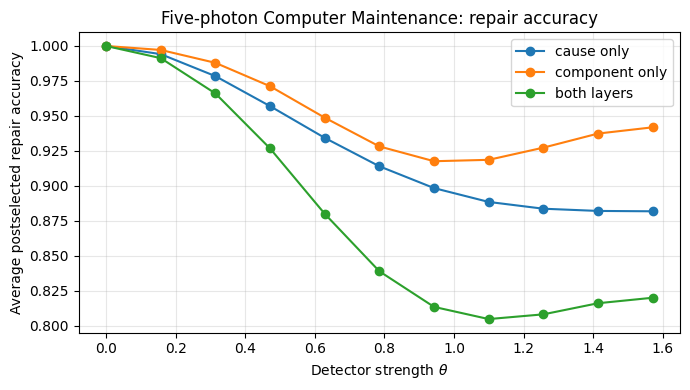

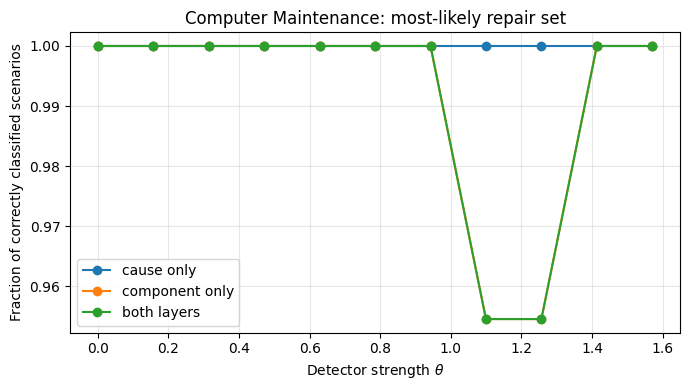

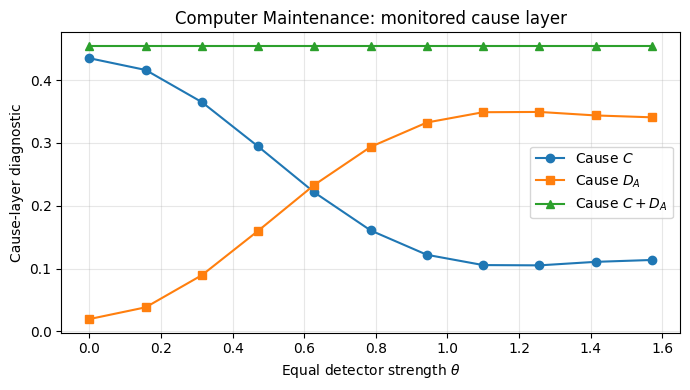

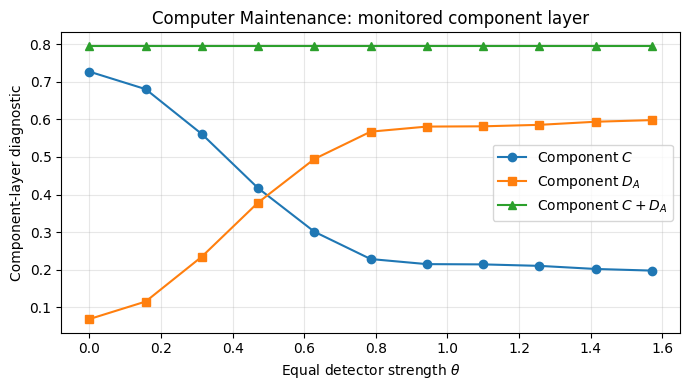

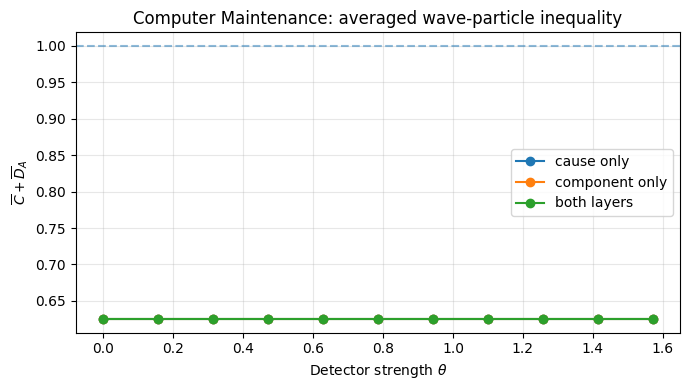

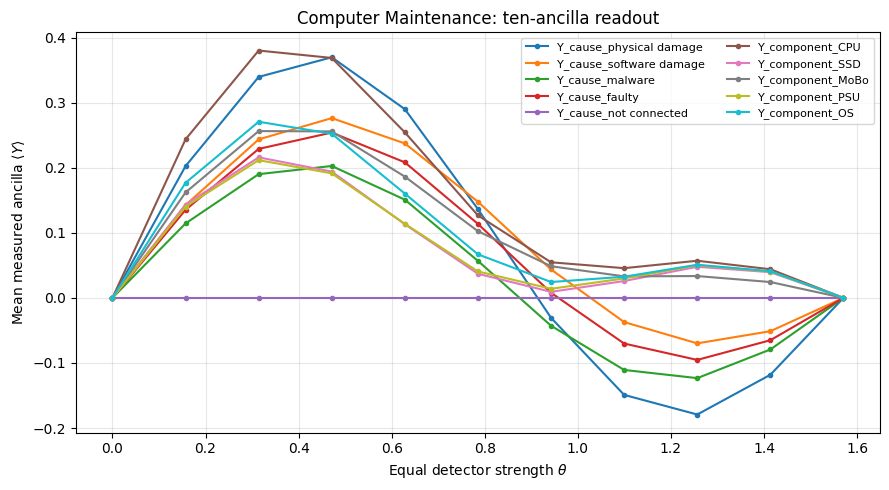

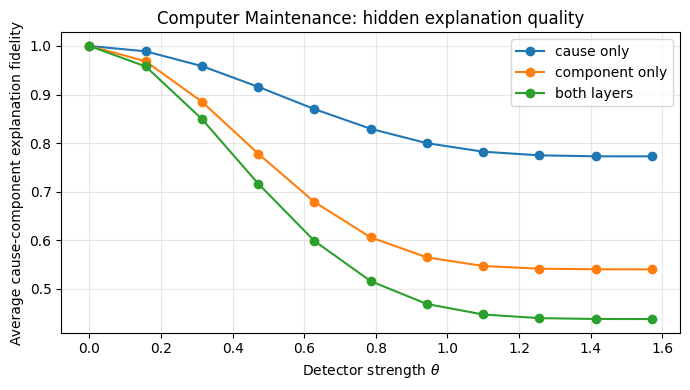

In [485]:
# ============================================================
# Five-photon Computer Maintenance plots
# ============================================================

plt.figure(figsize=(7, 4))
for monitoring_case in [
    "cause only",
    "component only",
    "both layers",
]:
    sub = semantic_cm_summary[
        semantic_cm_summary["monitoring_case"]
        == monitoring_case
    ]
    plt.plot(
        sub["theta"],
        sub["avg_correct_post"],
        marker="o",
        label=monitoring_case,
    )
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Average postselected repair accuracy")
plt.title(
    "Five-photon Computer Maintenance: repair accuracy"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for monitoring_case in [
    "cause only",
    "component only",
    "both layers",
]:
    sub = semantic_cm_summary[
        semantic_cm_summary["monitoring_case"]
        == monitoring_case
    ]
    plt.plot(
        sub["theta"],
        sub["classification_accuracy"],
        marker="o",
        label=monitoring_case,
    )
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Fraction of correctly classified scenarios")
plt.title(
    "Computer Maintenance: most-likely repair set"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


semantic_cm_both_summary = semantic_cm_summary[
    semantic_cm_summary["monitoring_case"]
    == "both layers"
]

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_cm_both_summary["theta"],
    semantic_cm_both_summary["avg_C_cause"],
    marker="o",
    label=r"Cause $C$",
)
plt.plot(
    semantic_cm_both_summary["theta"],
    semantic_cm_both_summary["avg_D_A_cause"],
    marker="s",
    label=r"Cause $D_A$",
)
plt.plot(
    semantic_cm_both_summary["theta"],
    semantic_cm_both_summary[
        "avg_C_plus_D_cause"
    ],
    marker="^",
    label=r"Cause $C+D_A$",
)
plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel("Cause-layer diagnostic")
plt.title(
    "Computer Maintenance: monitored cause layer"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(
    semantic_cm_both_summary["theta"],
    semantic_cm_both_summary[
        "avg_C_component"
    ],
    marker="o",
    label=r"Component $C$",
)
plt.plot(
    semantic_cm_both_summary["theta"],
    semantic_cm_both_summary[
        "avg_D_A_component"
    ],
    marker="s",
    label=r"Component $D_A$",
)
plt.plot(
    semantic_cm_both_summary["theta"],
    semantic_cm_both_summary[
        "avg_C_plus_D_component"
    ],
    marker="^",
    label=r"Component $C+D_A$",
)
plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel("Component-layer diagnostic")
plt.title(
    "Computer Maintenance: monitored component layer"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for monitoring_case in [
    "cause only",
    "component only",
    "both layers",
]:
    sub = semantic_cm_summary[
        semantic_cm_summary["monitoring_case"]
        == monitoring_case
    ]
    plt.plot(
        sub["theta"],
        sub["avg_C_plus_D_layers"],
        marker="o",
        label=monitoring_case,
    )
plt.axhline(1.0, linestyle="--", alpha=0.5)
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel(
    r"$\overline{C}+\overline{D}_A$"
)
plt.title(
    "Computer Maintenance: averaged wave-particle inequality"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


semantic_cm_both_ancilla = semantic_cm_ancilla_summary[
    semantic_cm_ancilla_summary["monitoring_case"]
    == "both layers"
]
semantic_cm_both_ancilla_array = np.stack(
    semantic_cm_both_ancilla[
        "mean_ancilla_expectations"
    ].to_numpy()
)

plt.figure(figsize=(9, 5))
for index, label in enumerate(
    semantic_cm_ancilla_labels
):
    plt.plot(
        semantic_cm_both_ancilla["theta"],
        semantic_cm_both_ancilla_array[:, index],
        marker="o",
        markersize=3,
        label=label,
    )
plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel(r"Mean measured ancilla $\langle Y\rangle$")
plt.title(
    "Computer Maintenance: ten-ancilla readout"
)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for monitoring_case in [
    "cause only",
    "component only",
    "both layers",
]:
    sub = semantic_cm_summary[
        semantic_cm_summary["monitoring_case"]
        == monitoring_case
    ]
    plt.plot(
        sub["theta"],
        sub["avg_explanation_fidelity"],
        marker="o",
        label=monitoring_case,
    )
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Average cause-component explanation fidelity")
plt.title(
    "Computer Maintenance: hidden explanation quality"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Additional Diagnostics for Postselection and Monitoring

The previous plots focus on postselected task accuracy, layer coherence, detector information, and ancilla readout means. This section adds diagnostics that make the interpretation harder to misread:

- raw correct-event probability, $P_{\rm act}P_{\rm correct}^{\rm post}$;
- confusion matrices for conditional decisions;
- readout conditioning and frame-spectrum checks;
- two-dimensional detector-strength sweeps;
- per-scenario worst-case tables;
- ancilla expectation heatmaps;
- configuration entropy of monitored layers;
- scatter plots linking coherence, explanation fidelity, action efficiency, and task success.

These quantities separate three different effects: whether the semantic state survives, whether the readout fires, and whether the conditional decision is correct once it fires.

In [486]:
# ============================================================
# Shared diagnostics helpers
# ============================================================

def semantic_safe_entropy(probabilities, base=np.e):
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = probabilities[probabilities > 1e-14]

    if len(probabilities) == 0:
        return 0.0

    entropy = -float(
        np.sum(probabilities * np.log(probabilities))
    )

    if base != np.e:
        entropy /= np.log(base)

    return entropy


def semantic_density_diagonal_entropy(rho, normalize=False):
    probabilities = np.real(np.diag(rho))
    probabilities = np.clip(probabilities, 0.0, None)

    total = float(np.sum(probabilities))

    if total <= 1e-14:
        return 0.0

    probabilities = probabilities / total
    entropy = semantic_safe_entropy(probabilities)

    if normalize:
        support = int(np.sum(probabilities > 1e-14))
        if support > 1:
            entropy /= np.log(support)

    return float(entropy)


def semantic_plot_matrix(
    matrix,
    x_labels,
    y_labels,
    title,
    xlabel,
    ylabel,
    colorbar_label,
    figsize=(7, 5),
    cmap="viridis",
    vmin=None,
    vmax=None,
):
    plt.figure(figsize=figsize)
    image = plt.imshow(
        matrix,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(image, label=colorbar_label)
    plt.xticks(
        np.arange(len(x_labels)),
        x_labels,
        rotation=45,
        ha="right",
    )
    plt.yticks(np.arange(len(y_labels)), y_labels)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def semantic_confusion_matrix(
    frame,
    true_column,
    predicted_column,
    labels,
):
    matrix = pd.crosstab(
        frame[true_column],
        frame[predicted_column],
        rownames=["true"],
        colnames=["predicted"],
        dropna=False,
    )

    return matrix.reindex(
        index=labels,
        columns=labels,
        fill_value=0,
    )


def semantic_theta_label(theta):
    if np.isclose(theta, 0.0):
        return "0"
    if np.isclose(theta, np.pi / 4):
        return r"\pi/4"
    if np.isclose(theta, np.pi / 2):
        return r"\pi/2"
    return f"{theta:.2f}"


def semantic_nearest_theta(frame, theta, theta_column="theta"):
    values = np.sort(frame[theta_column].unique())
    return float(values[np.argmin(np.abs(values - theta))])


In [487]:
# ============================================================
# Raw correct-event probability and summary tables
# ============================================================

semantic_162_ancilla_df["raw_correct"] = (
    semantic_162_ancilla_df["P_act"]
    * semantic_162_ancilla_df["correct_post"]
)

semantic_962_ancilla_df["raw_correct"] = (
    semantic_962_ancilla_df["P_act"]
    * semantic_962_ancilla_df["correct_post"]
)

semantic_9332_sweep_df["raw_correct"] = (
    semantic_9332_sweep_df["P_act"]
    * semantic_9332_sweep_df["correct_post"]
)

semantic_cm_sweep_df["raw_correct"] = (
    semantic_cm_sweep_df["P_act"]
    * semantic_cm_sweep_df["correct_post"]
)

semantic_162_raw_summary = (
    semantic_162_ancilla_df
    .groupby("theta")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
    )
    .reset_index()
)

semantic_962_raw_summary = (
    semantic_962_ancilla_df
    .groupby("theta")
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
    )
    .reset_index()
)

semantic_9332_raw_summary = (
    semantic_9332_sweep_df
    .groupby(["scenario", "theta"])
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
        avg_C_layers=("C_average_layers", "mean"),
        avg_D_A_layers=("D_A_average_layers", "mean"),
        avg_C_plus_D_layers=(
            "C_plus_D_average_layers",
            "mean",
        ),
    )
    .reset_index()
)

semantic_cm_raw_summary = (
    semantic_cm_sweep_df
    .groupby(["monitoring_case", "theta"])
    .agg(
        avg_correct_post=("correct_post", "mean"),
        avg_P_act=("P_act", "mean"),
        avg_raw_correct=("raw_correct", "mean"),
        avg_explanation_fidelity=(
            "explanation_fidelity",
            "mean",
        ),
        avg_C_layers=("C_average_layers", "mean"),
        avg_D_A_layers=("D_A_average_layers", "mean"),
        avg_C_plus_D_layers=(
            "C_plus_D_average_layers",
            "mean",
        ),
    )
    .reset_index()
)

display(semantic_9332_raw_summary.head())
display(semantic_cm_raw_summary.head())


,scenario,theta,avg_correct_post,avg_P_act,avg_raw_correct,avg_C_layers,avg_D_A_layers,avg_C_plus_D_layers
0,both layers,0.000000,1.000000,0.222222,0.222222,1.000000,5.551115e-17,1.0
1,both layers,0.157080,0.986052,0.218597,0.216591,0.975528,2.447174e-02,1.0
2,both layers,0.314159,0.952787,0.208075,0.200624,0.904508,9.549150e-02,1.0
3,both layers,0.471239,0.915356,0.191688,0.176872,0.793893,2.061074e-01,1.0
4,both layers,0.628319,0.882639,0.171038,0.148879,0.654508,3.454915e-01,1.0


,monitoring_case,theta,avg_correct_post,avg_P_act,avg_raw_correct,avg_explanation_fidelity,avg_C_layers,avg_D_A_layers,avg_C_plus_D_layers
0,both layers,0.000000,1.000000,0.073089,0.073089,1.000000,0.581100,0.043900,0.625
1,both layers,0.157080,0.991305,0.070381,0.069767,0.957918,0.548420,0.076580,0.625
2,both layers,0.314159,0.966044,0.063703,0.061527,0.849619,0.462964,0.162036,0.625
3,both layers,0.471239,0.926709,0.056218,0.052129,0.716627,0.355597,0.269403,0.625
4,both layers,0.628319,0.879987,0.050534,0.044678,0.598591,0.261012,0.363988,0.625


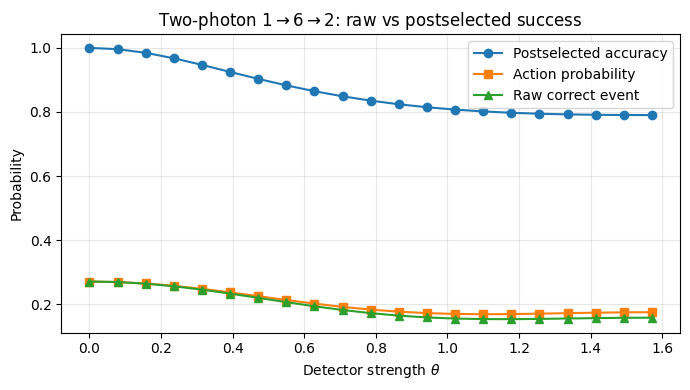

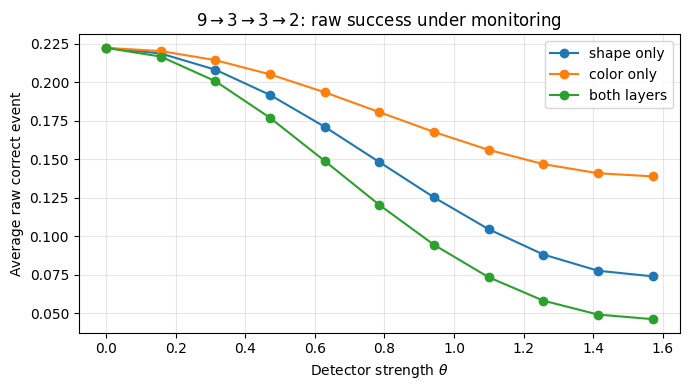

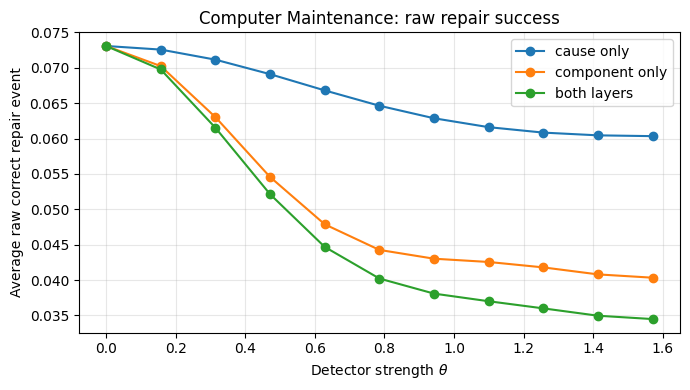

In [488]:
# ============================================================
# Raw-success plots for postselected analyses
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_162_raw_summary["theta"],
    semantic_162_raw_summary["avg_correct_post"],
    marker="o",
    label="Postselected accuracy",
)
plt.plot(
    semantic_162_raw_summary["theta"],
    semantic_162_raw_summary["avg_P_act"],
    marker="s",
    label="Action probability",
)
plt.plot(
    semantic_162_raw_summary["theta"],
    semantic_162_raw_summary["avg_raw_correct"],
    marker="^",
    label="Raw correct event",
)
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Probability")
plt.title(r"Two-photon $1\to6\to2$: raw vs postselected success")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for scenario in [
    "shape only",
    "color only",
    "both layers",
]:
    sub = semantic_9332_raw_summary[
        semantic_9332_raw_summary["scenario"] == scenario
    ]
    plt.plot(
        sub["theta"],
        sub["avg_raw_correct"],
        marker="o",
        label=scenario,
    )
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Average raw correct event")
plt.title(r"$9\to3\to3\to2$: raw success under monitoring")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for monitoring_case in [
    "cause only",
    "component only",
    "both layers",
]:
    sub = semantic_cm_raw_summary[
        semantic_cm_raw_summary["monitoring_case"]
        == monitoring_case
    ]
    plt.plot(
        sub["theta"],
        sub["avg_raw_correct"],
        marker="o",
        label=monitoring_case,
    )
plt.xlabel(r"Detector strength $\theta$")
plt.ylabel("Average raw correct repair event")
plt.title("Computer Maintenance: raw repair success")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


predicted,no,yes
true,,
no,6,2
yes,0,1


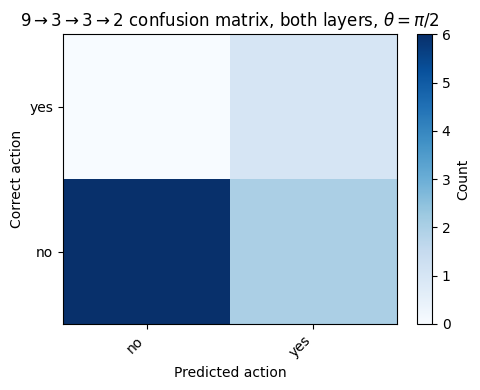

predicted,0,1,2,3,4,5,6,7,8
true,,,,,,,,,
0,3,0,0,0,0,0,0,0,0
1,0,3,0,0,0,0,0,0,0
2,0,0,2,0,0,0,0,0,0
3,0,0,0,15,0,0,0,0,0
4,0,0,0,0,11,0,0,0,0
5,0,0,0,0,0,4,0,0,0
6,0,0,0,0,0,0,3,0,0
7,0,0,0,0,0,0,0,1,0
8,0,0,0,0,0,0,0,0,2


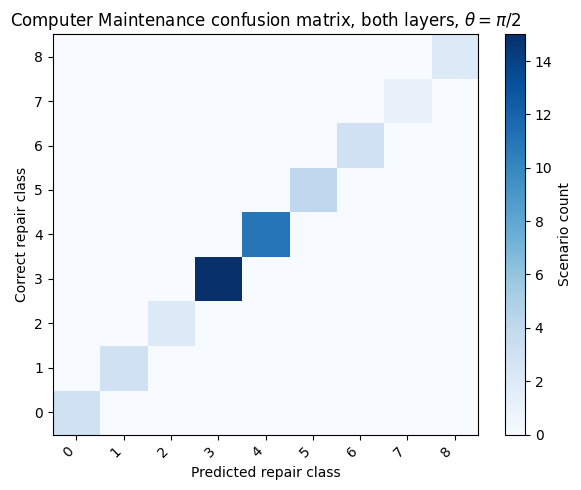

In [489]:
# ============================================================
# Confusion matrices for conditional decisions
# ============================================================

semantic_9332_confusion_df = semantic_9332_sweep_df.copy()
semantic_9332_confusion_df["true_label"] = np.where(
    semantic_9332_confusion_df["object"] == "BS",
    "yes",
    "no",
)
semantic_9332_confusion_df["predicted_label"] = np.where(
    semantic_9332_confusion_df["P_yes_post"]
    >= semantic_9332_confusion_df["P_no_post"],
    "yes",
    "no",
)

semantic_9332_theta_max = semantic_nearest_theta(
    semantic_9332_confusion_df,
    np.pi / 2,
)
semantic_9332_confusion_both_max = (
    semantic_9332_confusion_df[
        (
            semantic_9332_confusion_df["scenario"]
            == "both layers"
        )
        & np.isclose(
            semantic_9332_confusion_df["theta"],
            semantic_9332_theta_max,
        )
    ]
)

semantic_9332_confusion_matrix_both_max = (
    semantic_confusion_matrix(
        semantic_9332_confusion_both_max,
        true_column="true_label",
        predicted_column="predicted_label",
        labels=["no", "yes"],
    )
)

display(semantic_9332_confusion_matrix_both_max)

semantic_plot_matrix(
    semantic_9332_confusion_matrix_both_max.to_numpy(),
    x_labels=semantic_9332_confusion_matrix_both_max.columns,
    y_labels=semantic_9332_confusion_matrix_both_max.index,
    title=(
        r"$9\to3\to3\to2$ confusion matrix, both layers, "
        + rf"$\theta={semantic_theta_label(semantic_9332_theta_max)}$"
    ),
    xlabel="Predicted action",
    ylabel="Correct action",
    colorbar_label="Count",
    figsize=(5, 4),
    cmap="Blues",
)


semantic_cm_theta_max = semantic_nearest_theta(
    semantic_cm_sweep_df,
    np.pi / 2,
)
semantic_cm_confusion_both_max = (
    semantic_cm_sweep_df[
        (
            semantic_cm_sweep_df["monitoring_case"]
            == "both layers"
        )
        & np.isclose(
            semantic_cm_sweep_df["theta"],
            semantic_cm_theta_max,
        )
    ]
)

semantic_cm_action_labels = list(
    range(len(semantic_cm_ACTION_CLASSES))
)
semantic_cm_confusion_matrix_both_max = (
    semantic_confusion_matrix(
        semantic_cm_confusion_both_max,
        true_column="correct_action_class",
        predicted_column="predicted_action_class",
        labels=semantic_cm_action_labels,
    )
)

display(semantic_cm_confusion_matrix_both_max)

semantic_plot_matrix(
    semantic_cm_confusion_matrix_both_max.to_numpy(),
    x_labels=semantic_cm_action_labels,
    y_labels=semantic_cm_action_labels,
    title=(
        "Computer Maintenance confusion matrix, both layers, "
        + rf"$\theta={semantic_theta_label(semantic_cm_theta_max)}$"
    ),
    xlabel="Predicted repair class",
    ylabel="Correct repair class",
    colorbar_label="Scenario count",
    figsize=(6, 5),
    cmap="Blues",
)


,model,state_gram_min_eig,state_gram_max_eig,state_gram_condition,readout_frame_min_eig,readout_frame_max_eig,readout_frame_condition
0,two-photon 1→6→2,NaN,NaN,NaN,1.000000,1.0,1.000000
1,fixed two-photon 9→6→2 targets,0.50000,2.000000,4.0000,1.000000,1.0,1.000000
2,two-photon 9→3→3→2,1.00000,1.000000,1.0000,1.000000,1.0,1.000000
3,five-photon Computer Maintenance,0.18339,3.207012,17.4874,0.063295,1.0,15.798927


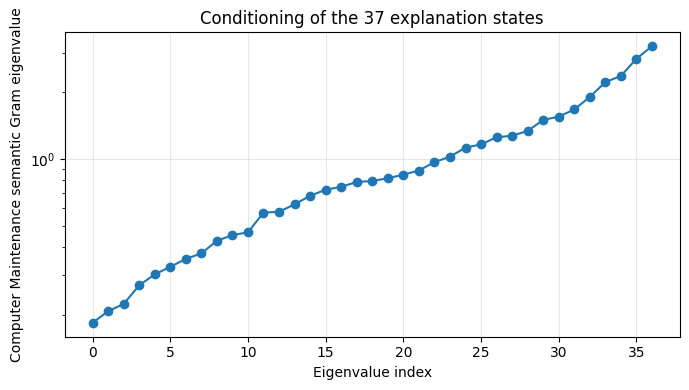

In [490]:
# ============================================================
# Readout conditioning and frame-spectrum checks
# ============================================================

semantic_readout_condition_rows = []

semantic_readout_condition_rows.append({
    "model": "two-photon 1→6→2",
    "state_gram_min_eig": np.nan,
    "state_gram_max_eig": np.nan,
    "state_gram_condition": np.nan,
    "readout_frame_min_eig": np.linalg.eigvalsh(
        np.column_stack([
            semantic_162_w_no,
            semantic_162_w_yes,
        ]).conj().T
        @ np.column_stack([
            semantic_162_w_no,
            semantic_162_w_yes,
        ])
    ).min(),
    "readout_frame_max_eig": np.linalg.eigvalsh(
        np.column_stack([
            semantic_162_w_no,
            semantic_162_w_yes,
        ]).conj().T
        @ np.column_stack([
            semantic_162_w_no,
            semantic_162_w_yes,
        ])
    ).max(),
})

semantic_962_state_gram = np.column_stack([
    semantic_962_target_states[obj]
    for obj in semantic_162_OBJECT_ORDER
]).conj().T @ np.column_stack([
    semantic_962_target_states[obj]
    for obj in semantic_162_OBJECT_ORDER
])
semantic_962_state_eigs = np.linalg.eigvalsh(
    semantic_962_state_gram
)

semantic_readout_condition_rows.append({
    "model": "fixed two-photon 9→6→2 targets",
    "state_gram_min_eig": float(
        semantic_962_state_eigs.min()
    ),
    "state_gram_max_eig": float(
        semantic_962_state_eigs.max()
    ),
    "state_gram_condition": float(
        semantic_962_state_eigs.max()
        / semantic_962_state_eigs.min()
    ),
    "readout_frame_min_eig": float(
        np.linalg.eigvalsh(
            np.column_stack([
                semantic_962_w_no,
                semantic_962_w_yes,
            ]).conj().T
            @ np.column_stack([
                semantic_962_w_no,
                semantic_962_w_yes,
            ])
        ).min()
    ),
    "readout_frame_max_eig": float(
        np.linalg.eigvalsh(
            np.column_stack([
                semantic_962_w_no,
                semantic_962_w_yes,
            ]).conj().T
            @ np.column_stack([
                semantic_962_w_no,
                semantic_962_w_yes,
            ])
        ).max()
    ),
})

semantic_9332_state_eigs = np.linalg.eigvalsh(
    semantic_9332_final_gram
)
semantic_readout_condition_rows.append({
    "model": "two-photon 9→3→3→2",
    "state_gram_min_eig": float(
        semantic_9332_state_eigs.min()
    ),
    "state_gram_max_eig": float(
        semantic_9332_state_eigs.max()
    ),
    "state_gram_condition": float(
        semantic_9332_state_eigs.max()
        / semantic_9332_state_eigs.min()
    ),
    "readout_frame_min_eig": float(
        np.linalg.eigvalsh(
            np.column_stack([
                semantic_9332_w_no,
                semantic_9332_w_yes,
            ]).conj().T
            @ np.column_stack([
                semantic_9332_w_no,
                semantic_9332_w_yes,
            ])
        ).min()
    ),
    "readout_frame_max_eig": float(
        np.linalg.eigvalsh(
            np.column_stack([
                semantic_9332_w_no,
                semantic_9332_w_yes,
            ]).conj().T
            @ np.column_stack([
                semantic_9332_w_no,
                semantic_9332_w_yes,
            ])
        ).max()
    ),
})

semantic_cm_state_eigs = np.linalg.eigvalsh(
    semantic_cm_gram
)
semantic_cm_frame_eigs = np.linalg.eigvalsh(
    semantic_cm_W.conj().T @ semantic_cm_W
)
semantic_readout_condition_rows.append({
    "model": "five-photon Computer Maintenance",
    "state_gram_min_eig": float(
        semantic_cm_state_eigs.min()
    ),
    "state_gram_max_eig": float(
        semantic_cm_state_eigs.max()
    ),
    "state_gram_condition": float(
        semantic_cm_state_eigs.max()
        / semantic_cm_state_eigs.min()
    ),
    "readout_frame_min_eig": float(
        semantic_cm_frame_eigs.min()
    ),
    "readout_frame_max_eig": float(
        semantic_cm_frame_eigs.max()
    ),
})

semantic_readout_condition_df = pd.DataFrame(
    semantic_readout_condition_rows
)
semantic_readout_condition_df["readout_frame_condition"] = (
    semantic_readout_condition_df["readout_frame_max_eig"]
    / semantic_readout_condition_df["readout_frame_min_eig"]
)
display(semantic_readout_condition_df)

plt.figure(figsize=(7, 4))
plt.semilogy(
    np.arange(len(semantic_cm_state_eigs)),
    np.sort(semantic_cm_state_eigs),
    marker="o",
)
plt.xlabel("Eigenvalue index")
plt.ylabel("Computer Maintenance semantic Gram eigenvalue")
plt.title("Conditioning of the 37 explanation states")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


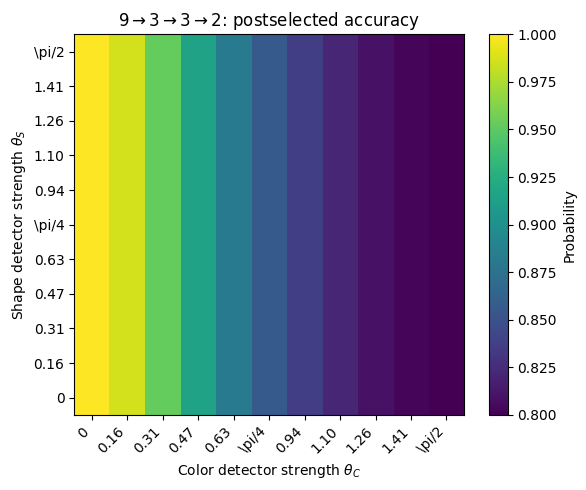

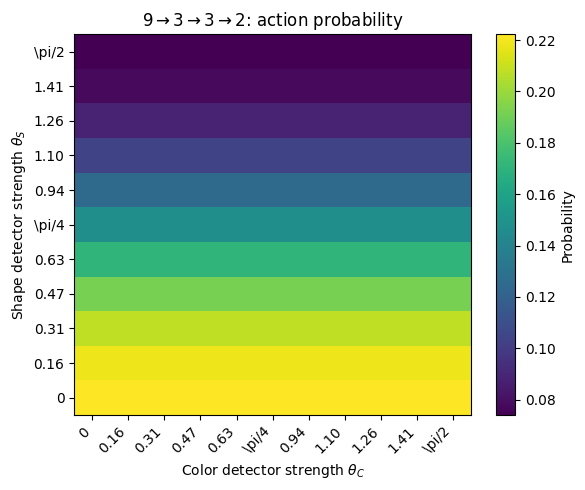

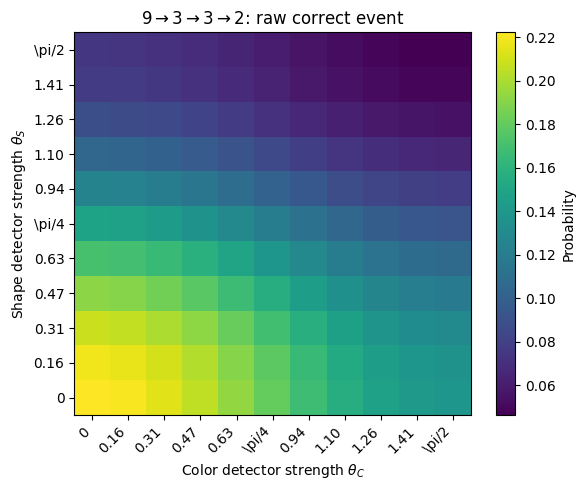

In [491]:
# ============================================================
# Two-dimensional detector-strength sweep: 9→3→3→2
# ============================================================

semantic_9332_theta_grid = np.linspace(
    0,
    np.pi / 2,
    11,
)
semantic_9332_grid_rows = []

for theta_shape in semantic_9332_theta_grid:
    for theta_color in semantic_9332_theta_grid:
        run_rows = []

        for obj in semantic_162_OBJECT_ORDER:
            row = semantic_9332_run_ancilla_point(
                object_label=obj,
                theta_shape=float(theta_shape),
                theta_color=float(theta_color),
                compute_wp=False,
            )
            row["raw_correct"] = (
                row["P_act"] * row["correct_post"]
            )
            run_rows.append(row)

        run_frame = pd.DataFrame(run_rows)
        semantic_9332_grid_rows.append({
            "theta_shape": float(theta_shape),
            "theta_color": float(theta_color),
            "avg_correct_post": float(
                run_frame["correct_post"].mean()
            ),
            "avg_P_act": float(
                run_frame["P_act"].mean()
            ),
            "avg_raw_correct": float(
                run_frame["raw_correct"].mean()
            ),
        })

semantic_9332_detector_grid_df = pd.DataFrame(
    semantic_9332_grid_rows
)


def semantic_grid_matrix(
    frame,
    value_column,
    x_column,
    y_column,
):
    pivot = frame.pivot(
        index=y_column,
        columns=x_column,
        values=value_column,
    )
    return pivot.to_numpy(), pivot.columns, pivot.index


semantic_9332_grid_labels = [
    semantic_theta_label(theta)
    for theta in semantic_9332_theta_grid
]

for value_column, title, colorbar_label in [
    (
        "avg_correct_post",
        r"$9\to3\to3\to2$: postselected accuracy",
        "Probability",
    ),
    (
        "avg_P_act",
        r"$9\to3\to3\to2$: action probability",
        "Probability",
    ),
    (
        "avg_raw_correct",
        r"$9\to3\to3\to2$: raw correct event",
        "Probability",
    ),
]:
    matrix, _, _ = semantic_grid_matrix(
        semantic_9332_detector_grid_df,
        value_column=value_column,
        x_column="theta_color",
        y_column="theta_shape",
    )
    semantic_plot_matrix(
        matrix,
        x_labels=semantic_9332_grid_labels,
        y_labels=semantic_9332_grid_labels,
        title=title,
        xlabel=r"Color detector strength $\theta_C$",
        ylabel=r"Shape detector strength $\theta_S$",
        colorbar_label=colorbar_label,
        figsize=(6, 5),
    )


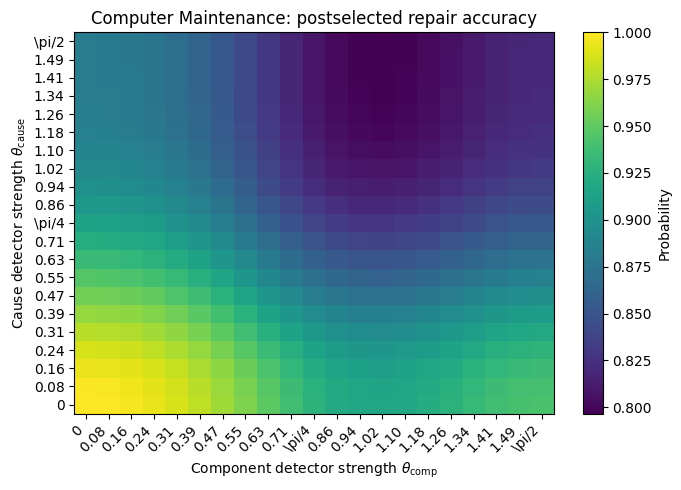

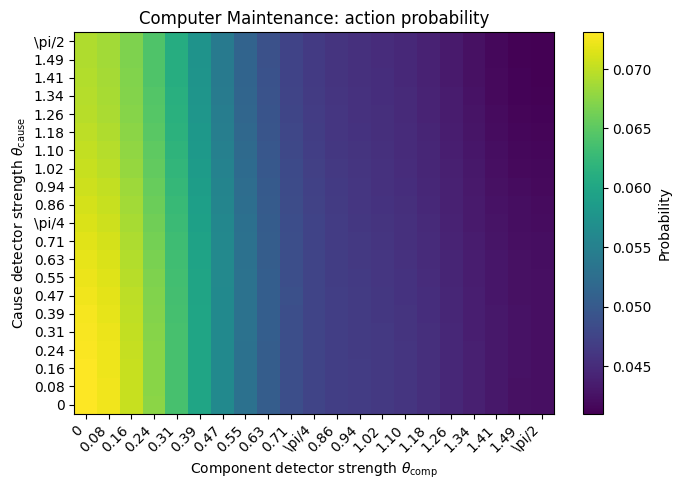

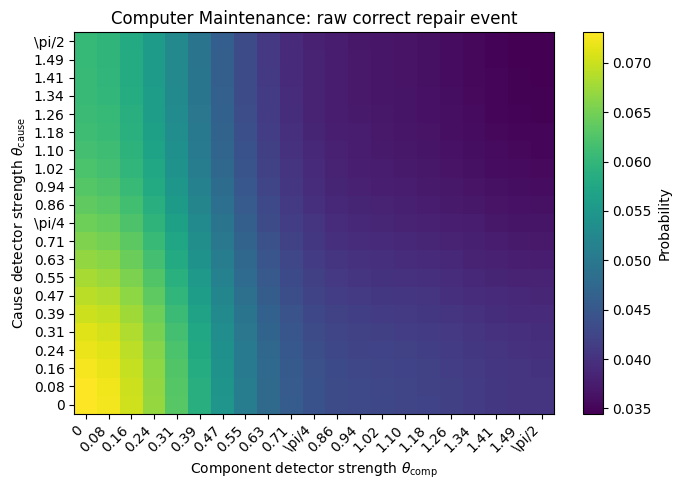

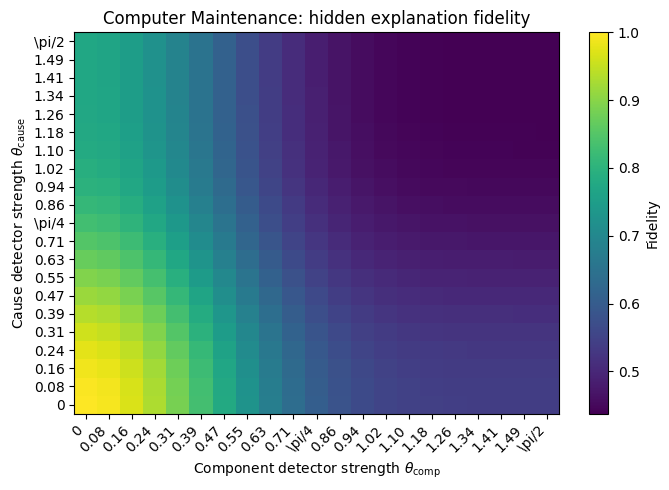

In [492]:
# ============================================================
# Two-dimensional detector-strength sweep: Computer Maintenance
# ============================================================

semantic_cm_theta_grid = np.linspace(
    0,
    np.pi / 2,
    21,
)
semantic_cm_grid_rows = []

for theta_cause in semantic_cm_theta_grid:
    for theta_component in semantic_cm_theta_grid:
        correct_posts = []
        action_probs = []
        raw_corrects = []
        explanation_fidelities = []
        C_plus_D_averages = []
        cause_entropies = []
        component_entropies = []

        for scenario_index in range(
            len(semantic_cm_SCENARIOS)
        ):
            cause_diag = semantic_cm_monitored_layer(
                semantic_cm_cause_states[scenario_index],
                semantic_cm_cause_basis,
                float(theta_cause),
            )
            component_diag = semantic_cm_monitored_layer(
                semantic_cm_component_states[
                    scenario_index
                ],
                semantic_cm_component_basis,
                float(theta_component),
            )
            scores = semantic_cm_readout_scores(
                cause_diag["rho"],
                component_diag["rho"],
            )
            P_act = float(np.sum(scores))
            postselected = scores / P_act
            explanation_index = (
                semantic_cm_scenario_to_explanation[
                    scenario_index
                ]
            )
            correct_actions = (
                semantic_cm_explanation_actions[
                    explanation_index
                ]
            )
            correct_class = (
                semantic_cm_ACTION_CLASSES.index(
                    correct_actions
                )
            )
            correct_post = float(
                postselected[correct_class]
            )

            correct_posts.append(correct_post)
            action_probs.append(P_act)
            raw_corrects.append(P_act * correct_post)
            explanation_fidelities.append(
                cause_diag["semantic_fidelity"]
                * component_diag["semantic_fidelity"]
            )
            C_plus_D_averages.append(
                0.5
                * (
                    cause_diag["C_plus_D_A"]
                    + component_diag["C_plus_D_A"]
                )
            )
            cause_entropies.append(
                semantic_density_diagonal_entropy(
                    cause_diag["rho"],
                    normalize=True,
                )
            )
            component_entropies.append(
                semantic_density_diagonal_entropy(
                    component_diag["rho"],
                    normalize=True,
                )
            )

        semantic_cm_grid_rows.append({
            "theta_cause": float(theta_cause),
            "theta_component": float(theta_component),
            "avg_correct_post": float(
                np.mean(correct_posts)
            ),
            "avg_P_act": float(np.mean(action_probs)),
            "avg_raw_correct": float(
                np.mean(raw_corrects)
            ),
            "avg_explanation_fidelity": float(
                np.mean(explanation_fidelities)
            ),
            "avg_C_plus_D_layers": float(
                np.mean(C_plus_D_averages)
            ),
            "avg_cause_entropy": float(
                np.mean(cause_entropies)
            ),
            "avg_component_entropy": float(
                np.mean(component_entropies)
            ),
        })

semantic_cm_detector_grid_df = pd.DataFrame(
    semantic_cm_grid_rows
)

semantic_cm_grid_labels = [
    semantic_theta_label(theta)
    for theta in semantic_cm_theta_grid
]

for value_column, title, colorbar_label in [
    (
        "avg_correct_post",
        "Computer Maintenance: postselected repair accuracy",
        "Probability",
    ),
    (
        "avg_P_act",
        "Computer Maintenance: action probability",
        "Probability",
    ),
    (
        "avg_raw_correct",
        "Computer Maintenance: raw correct repair event",
        "Probability",
    ),
    (
        "avg_explanation_fidelity",
        "Computer Maintenance: hidden explanation fidelity",
        "Fidelity",
    ),
]:
    matrix, _, _ = semantic_grid_matrix(
        semantic_cm_detector_grid_df,
        value_column=value_column,
        x_column="theta_component",
        y_column="theta_cause",
    )
    semantic_plot_matrix(
        matrix,
        x_labels=semantic_cm_grid_labels,
        y_labels=semantic_cm_grid_labels,
        title=title,
        xlabel=r"Component detector strength $\theta_{\rm comp}$",
        ylabel=r"Cause detector strength $\theta_{\rm cause}$",
        colorbar_label=colorbar_label,
        figsize=(7, 5),
    )


,scenario,min_correct_post,min_raw_correct,min_P_act,min_explanation_fidelity,symptoms,causes,components,actions
0,36,0.629303,0.012137,0.018413,0.125514,"(old hardware, software glitches)","(software damage, faulty)","(CPU, PSU, OS)","(replace components, install missing software)"
1,19,0.788396,0.012620,0.015727,0.125514,"(visible markings on components, old hardware)","(physical damage, faulty)","(CPU, SSD, MoBo)","(replace components,)"
2,32,0.469925,0.012931,0.027517,0.125514,"(slow performance, software glitches)","(software damage, malware)","(CPU, MoBo, OS)","(install missing software, run antivirus)"
3,35,0.904176,0.014691,0.016242,0.125514,"(old hardware, strange noises)","(physical damage, faulty)","(CPU, SSD, PSU)","(replace components,)"
4,34,0.539745,0.016583,0.030724,0.125514,"(slow performance, no internet)","(physical damage, software damage)","(CPU, MoBo, OS)","(replace components, install missing software)"
5,33,0.539745,0.016583,0.030724,0.125514,"(slow performance, blue screen)","(physical damage, software damage)","(CPU, MoBo, OS)","(replace components, install missing software)"
6,28,0.646890,0.018353,0.028371,0.250000,"(unexpected shutdowns, blue screen)","(physical damage, faulty)","(CPU, MoBo)","(replace components,)"
7,39,0.802874,0.018825,0.021995,0.250000,"(strange noises, software glitches)","(physical damage, software damage)","(SSD, MoBo)","(replace components, install missing software)"
8,9,0.802874,0.018825,0.021995,0.250000,"(files disappearing, visible markings on compo...","(physical damage, software damage)","(SSD, MoBo)","(replace components, install missing software)"
9,22,0.669255,0.018943,0.022860,0.250000,"(visible markings on components, blue screen)","(software damage, faulty)","(CPU, SSD)","(replace components, install missing software)"


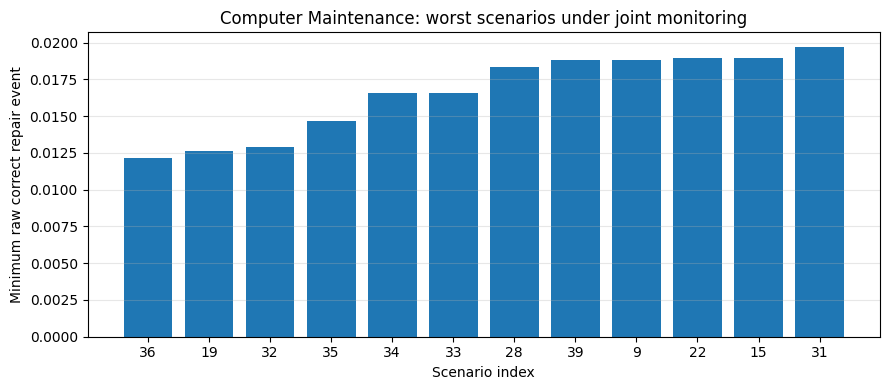

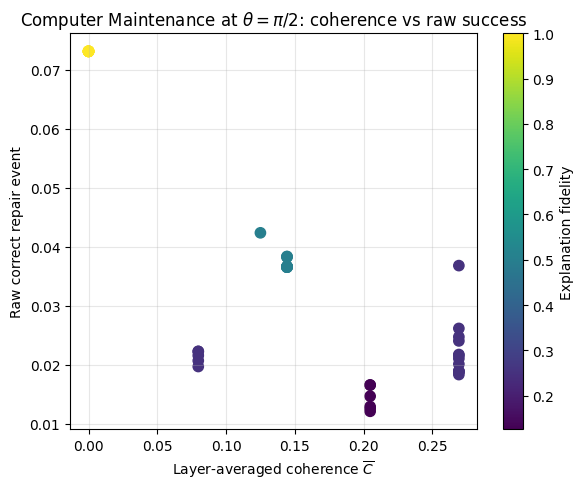

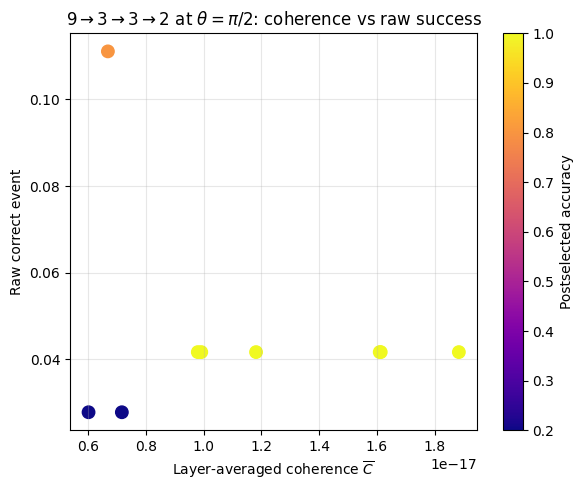

In [493]:
# ============================================================
# Per-scenario worst cases and scatter diagnostics
# ============================================================

semantic_cm_both_rows = semantic_cm_sweep_df[
    semantic_cm_sweep_df["monitoring_case"] == "both layers"
].copy()

semantic_cm_worst_scenarios = (
    semantic_cm_both_rows
    .groupby("scenario")
    .agg(
        min_correct_post=("correct_post", "min"),
        min_raw_correct=("raw_correct", "min"),
        min_P_act=("P_act", "min"),
        min_explanation_fidelity=(
            "explanation_fidelity",
            "min",
        ),
    )
    .reset_index()
    .sort_values("min_raw_correct")
)

semantic_cm_worst_scenarios = (
    semantic_cm_worst_scenarios
    .merge(
        semantic_cm_scenario_df[
            [
                "scenario",
                "symptoms",
                "causes",
                "components",
                "actions",
            ]
        ],
        on="scenario",
        how="left",
    )
)

display(semantic_cm_worst_scenarios.head(12))

plt.figure(figsize=(9, 4))
top_worst = semantic_cm_worst_scenarios.head(12)
plt.bar(
    top_worst["scenario"].astype(str),
    top_worst["min_raw_correct"],
)
plt.xlabel("Scenario index")
plt.ylabel("Minimum raw correct repair event")
plt.title("Computer Maintenance: worst scenarios under joint monitoring")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
cm_both_theta_max = semantic_cm_both_rows[
    np.isclose(
        semantic_cm_both_rows["theta"],
        semantic_cm_theta_max,
    )
]
plt.scatter(
    cm_both_theta_max["C_average_layers"],
    cm_both_theta_max["raw_correct"],
    c=cm_both_theta_max["explanation_fidelity"],
    cmap="viridis",
    s=55,
)
plt.colorbar(label="Explanation fidelity")
plt.xlabel(r"Layer-averaged coherence $\overline{C}$")
plt.ylabel("Raw correct repair event")
plt.title(
    r"Computer Maintenance at $\theta=\pi/2$: coherence vs raw success"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
semantic_9332_both_max = semantic_9332_sweep_df[
    (
        semantic_9332_sweep_df["scenario"]
        == "both layers"
    )
    & np.isclose(
        semantic_9332_sweep_df["theta"],
        semantic_9332_theta_max,
    )
]
plt.scatter(
    semantic_9332_both_max["C_average_layers"],
    semantic_9332_both_max["raw_correct"],
    c=semantic_9332_both_max["correct_post"],
    cmap="plasma",
    s=80,
)
plt.colorbar(label="Postselected accuracy")
plt.xlabel(r"Layer-averaged coherence $\overline{C}$")
plt.ylabel("Raw correct event")
plt.title(
    r"$9\to3\to3\to2$ at $\theta=\pi/2$: coherence vs raw success"
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


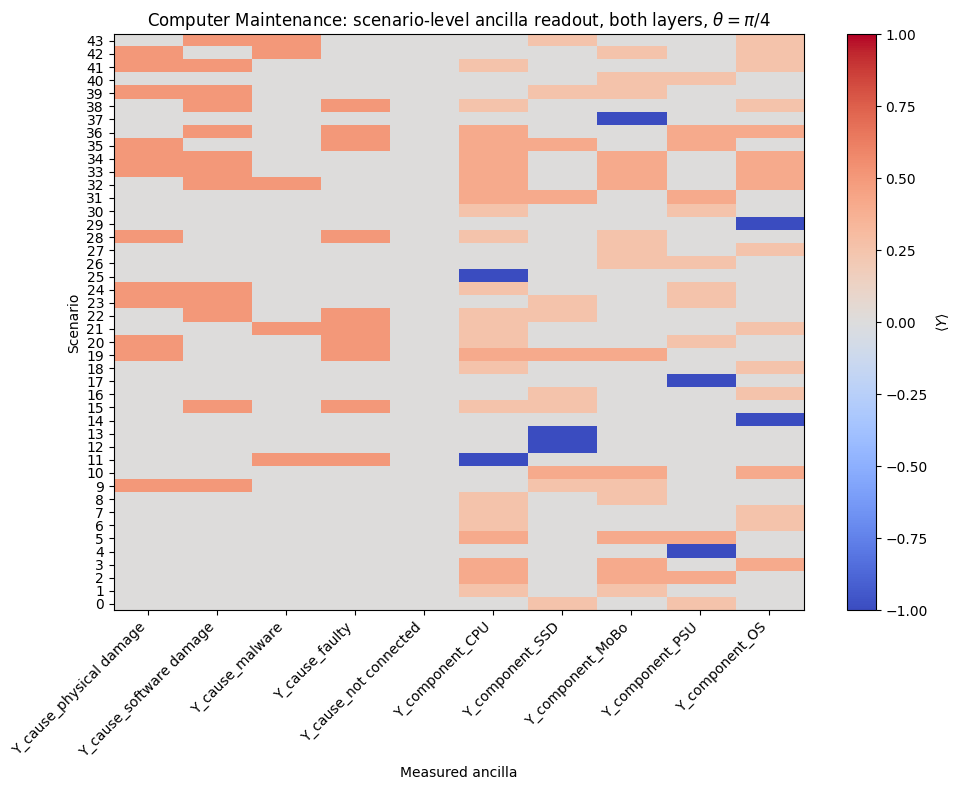

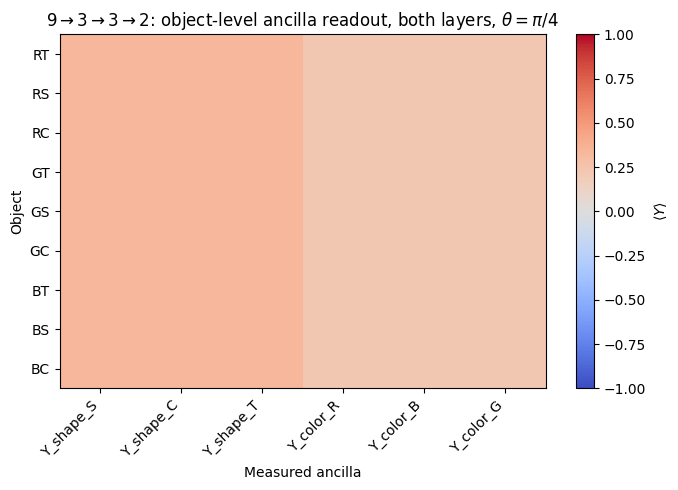

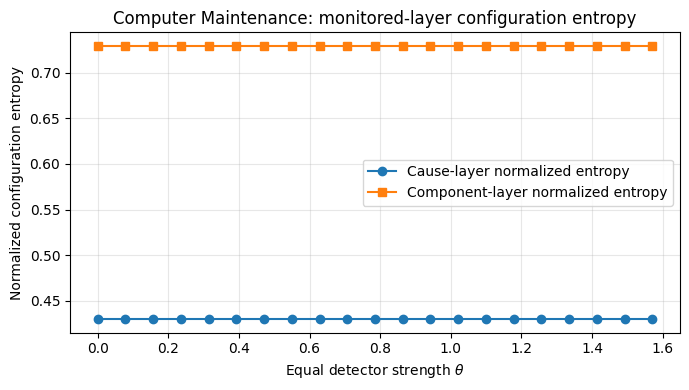

In [494]:
# ============================================================
# Ancilla expectation heatmaps and entropy curves
# ============================================================

semantic_cm_theta_mid = semantic_nearest_theta(
    semantic_cm_sweep_df,
    np.pi / 4,
)
semantic_cm_ancilla_heatmap_frame = (
    semantic_cm_sweep_df[
        (
            semantic_cm_sweep_df["monitoring_case"]
            == "both layers"
        )
        & np.isclose(
            semantic_cm_sweep_df["theta"],
            semantic_cm_theta_mid,
        )
    ]
    .sort_values("scenario")
)
semantic_cm_ancilla_heatmap = np.stack(
    semantic_cm_ancilla_heatmap_frame[
        "ancilla_expectations"
    ].to_numpy()
)

semantic_plot_matrix(
    semantic_cm_ancilla_heatmap,
    x_labels=semantic_cm_ancilla_labels,
    y_labels=semantic_cm_ancilla_heatmap_frame[
        "scenario"
    ].astype(str),
    title=(
        "Computer Maintenance: scenario-level ancilla readout, "
        + rf"both layers, $\theta={semantic_theta_label(semantic_cm_theta_mid)}$"
    ),
    xlabel="Measured ancilla",
    ylabel="Scenario",
    colorbar_label=r"$\langle Y\rangle$",
    figsize=(10, 8),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)


semantic_9332_theta_mid = semantic_nearest_theta(
    semantic_9332_sweep_df,
    np.pi / 4,
)
semantic_9332_ancilla_heatmap_frame = (
    semantic_9332_sweep_df[
        (
            semantic_9332_sweep_df["scenario"]
            == "both layers"
        )
        & np.isclose(
            semantic_9332_sweep_df["theta"],
            semantic_9332_theta_mid,
        )
    ]
    .sort_values("object")
)
semantic_9332_ancilla_heatmap = np.stack(
    semantic_9332_ancilla_heatmap_frame[
        "ancilla_expectations"
    ].to_numpy()
)

semantic_plot_matrix(
    semantic_9332_ancilla_heatmap,
    x_labels=semantic_9332_ancilla_labels,
    y_labels=semantic_9332_ancilla_heatmap_frame["object"],
    title=(
        r"$9\to3\to3\to2$: object-level ancilla readout, "
        + rf"both layers, $\theta={semantic_theta_label(semantic_9332_theta_mid)}$"
    ),
    xlabel="Measured ancilla",
    ylabel="Object",
    colorbar_label=r"$\langle Y\rangle$",
    figsize=(7, 5),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)


semantic_cm_entropy_diagonal = (
    semantic_cm_detector_grid_df[
        np.isclose(
            semantic_cm_detector_grid_df["theta_cause"],
            semantic_cm_detector_grid_df["theta_component"],
        )
    ]
    .sort_values("theta_cause")
)

plt.figure(figsize=(7, 4))
plt.plot(
    semantic_cm_entropy_diagonal["theta_cause"],
    semantic_cm_entropy_diagonal["avg_cause_entropy"],
    marker="o",
    label="Cause-layer normalized entropy",
)
plt.plot(
    semantic_cm_entropy_diagonal["theta_cause"],
    semantic_cm_entropy_diagonal[
        "avg_component_entropy"
    ],
    marker="s",
    label="Component-layer normalized entropy",
)
plt.xlabel(r"Equal detector strength $\theta$")
plt.ylabel("Normalized configuration entropy")
plt.title("Computer Maintenance: monitored-layer configuration entropy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
